_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: <span style='background: yellow'>*FILL IN YOUR NAMES HERE* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Project 3: Single-cell data analysis.

In [ ]:
# RUN THIS
#!pip install umap-learn hdbscan pydeseq2 jax jaxlib tqdm

In [ ]:
%matplotlib notebook
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import string

import scipy as sp
from scipy import sparse
import sklearn

## add your packages ##
import re
from collections import defaultdict
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE, trustworthiness as sk_trustworthiness
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    silhouette_score,
    confusion_matrix,
    homogeneity_score,
)
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import umap
import hdbscan
import warnings
from tqdm import tqdm
from joblib import Parallel, delayed
from typing import Tuple
from scipy.optimize import linear_sum_assignment
import jax
import jax.numpy as jnp
from jax import jit, vmap, lax
from jax.scipy.special import gammaln, logsumexp
import itertools

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder


from pydeseq2.preprocessing import deseq2_norm as pydeseq2_norm

import scanpy as sc
from anndata import AnnData


import time
import pickle
import memory_profiler

%load_ext memory_profiler

from pathlib import Path

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


In [2]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [3]:
variables_path = Path("../results/variables")
figures_path = Path("../results/figures")
data_path = Path("../data/")

In [4]:
plt.style.use("../matplotlib_style.txt")

In [5]:
np.random.seed(42)

## Project and data description

In this project, we are going to work with the typical methods and pipelines used in single-cell data analysis and get some hands-on experience with the techniques used in the field. For that, we will be using Patch-seq multimodal data from cortical neurons in mice, from Scala et al. 2021 (https://www.nature.com/articles/s41586-020-2907-3#Sec7). From the different data modalities they used, we will focus on transcriptomics and electrophysiological data. 

In a real-world scenario, single cell data rarely comes with any "ground truth" labels. Often, the goal of researchers after measuring cells is to precisely classify them, grouping them into families or assigning them cell types based on the recorded features. This is normally done using usupervised methods, such as clustering methods.

However, the single-cell data that we are using in this project has some cell types assigned to each cell. These are not "ground truth" type annotations, but were one of the results from the original Scala et al. work. Still, we are going to use those annotations for validation (despite them not really being ground truth) to sanity-check some of our analyses, such as visualizations, clustering, etc. We will mainly work with cell types (`rna_types`, 77 unique types) and cell families (`rna_families`, 9 unique families).

From the transcriptomics mRNA counts, we will only work with the exon counts for simplicity. Some of the electrophysiological features are not high-quality recordings, therefore we will also filter them out.

## Import data

### Meta data

In [6]:
# META DATA

meta = pd.read_csv(data_path / "m1_patchseq_meta_data.csv", sep="\t")

cells = meta["Cell"].values

layers = meta["Targeted layer"].values.astype("str")
cre = meta["Cre"].values
yields = meta["Yield (pg/µl)"].values
yields[yields == "?"] = np.nan
yields = yields.astype("float")
depth = meta["Soma depth (µm)"].values
depth[depth == "Slice Lost"] = np.nan
depth = depth.astype(float)
thickness = meta["Cortical thickness (µm)"].values
thickness[thickness == 0] = np.nan
thickness = thickness.astype(float)
traced = meta["Traced"].values == "y"
exclude = meta["Exclusion reasons"].values.astype(str)
exclude[exclude == "nan"] = ""

mice_names = meta["Mouse"].values
mice_ages = meta["Mouse age"].values
mice_cres = np.array(
    [
        c if c[-1] != "+" and c[-1] != "-" else c[:-1]
        for c in meta["Cre"].values
    ]
)
mice_ages = dict(zip(mice_names, mice_ages))
mice_cres = dict(zip(mice_names, mice_cres))

print("Number of cells with measured depth:    ", np.sum(~np.isnan(depth)))
print("Number of cells with measured thickness:", np.sum(~np.isnan(thickness)))
print("Number of reconstructed cells:          ", np.sum(traced))

sliceids = meta["Slice"].values
a, b = np.unique(sliceids, return_counts=True)
assert np.all(b <= 2)
print("Number of slices with two cells:        ", np.sum(b == 2))

# Some consistency checks
assert np.all(
    [
        np.unique(meta["Date"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse age"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse gender"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse genotype"].values[mice_names == m]).size == 1
        for m in mice_names
    ]
)
assert np.all(
    [
        np.unique(meta["Mouse"].values[sliceids == s]).size == 1
        for s in sliceids
    ]
)

Number of cells with measured depth:     1284
Number of cells with measured thickness: 1284
Number of reconstructed cells:           646
Number of slices with two cells:         69


### "Ground truth labels"

In [7]:
# filter out low quality cells in term of RNA
print(
    "There are",
    np.sum(meta["RNA family"] == "low quality"),
    "cells with low quality RNA recordings.",
)
exclude_low_quality = meta["RNA family"] != "low quality"

There are 97 cells with low quality RNA recordings.


In [8]:
rna_family = meta["RNA family"][exclude_low_quality]
rna_type = meta["RNA type"][exclude_low_quality]

In [9]:
print(len(np.unique(rna_family)))
print(len(np.unique(rna_type)))

9
77


In [10]:
pickle_in = open(data_path / "dict_rna_type_colors.pkl", "rb")
dict_rna_type_colors = pickle.load(pickle_in)

In [11]:
rna_type_colors = np.vectorize(dict_rna_type_colors.get)(rna_type)

### Transcriptomic data

In [12]:
# READ COUNTS
data_exons = pd.read_csv(
    data_path / "m1_patchseq_exon_counts.csv.gz", na_filter=False, index_col=0
)

assert all(cells == data_exons.columns)
genes = np.array(data_exons.index)

# filter out low quality cells in term of rna family
exonCounts = data_exons.values.transpose()[exclude_low_quality]
print("Count matrix shape (exon):  ", exonCounts.shape)

Count matrix shape (exon):   (1232, 42466)


In [13]:
# GENE LENGTH

data = pd.read_csv(data_path / "gene_lengths.txt")
assert all(data["GeneID"] == genes)
exonLengths = data["exon_bp"].values

### Electrophysiological features

In [14]:
# EPHYS DATA

ephysData = pd.read_csv(data_path / "m1_patchseq_ephys_features.csv")
ephysNames = np.array(ephysData.columns[1:]).astype(str)
ephysCells = ephysData["cell id"].values
ephysData = ephysData.values[:, 1:].astype("float")
names2ephys = dict(zip(ephysCells, ephysData))
ephysData = np.array(
    [
        names2ephys[c] if c in names2ephys else ephysData[0] * np.nan
        for c in cells
    ]
)

print("Number of cells with ephys data:", np.sum(np.isin(cells, ephysCells)))

assert np.sum(~np.isin(ephysCells, cells)) == 0

Number of cells with ephys data: 1328


In [15]:
# Filtering ephys data, as in paper

# Exclude low quality cells in term of rna family
ephysData_filtered = ephysData[exclude_low_quality]

print("Before filtering:", ephysData_filtered.shape)

# log normalize features to get more normal distribution
features_log = [
    "AP coefficient of variation",
    "ISI coefficient of variation",
    "ISI adaptation index",
    "Latency (ms)",
]
for e in features_log:
    ephysData_filtered[:, ephysNames == e] = np.log(
        ephysData_filtered[:, ephysNames == e]
    )

# Exclude features
features_exclude = [
    "Afterdepolarization (mV)",
    "AP Fano factor",
    "ISI Fano factor",
    "Latency @ +20pA current (ms)",
    "Wildness",
    "Spike frequency adaptation",
    "Sag area (mV*s)",
    "Sag time (s)",
    "Burstiness",
    "AP amplitude average adaptation index",
    "ISI average adaptation index",
    "Rebound number of APs",
]
ephys_feature_mask = ~np.isin(ephysNames, features_exclude)
ephysNames_filtered = ephysNames[ephys_feature_mask]
ephysData_filtered = ephysData_filtered[:, ephys_feature_mask]

# How many cells remain after filtering?
keepcells = ~np.isnan(np.sum(ephysData_filtered, axis=1))
ephysData_filtered = ephysData_filtered[keepcells, :]
print("After filtering:", ephysData_filtered.shape)

# Also filter out cells from RNAseq data
exonCounts = exonCounts[keepcells, :]
print(exonCounts.shape)

np.sum(np.isnan(ephysData_filtered))

Before filtering: (1232, 29)
After filtering: (1224, 17)
(1224, 42466)


np.int64(0)

# Research questions to investigate

## 1 - Inspect the data by computing key statistics
For RNA counts, you can compute and plot statistics, e.g. total counts per cell, number of expressed genes per cell, mean count per gene, variance per gene, mean-variance relationship... See https://www.embopress.org/doi/full/10.15252/msb.20188746 for common quality control statistics. Keep in mind that the RNA data in this project is read counts, not UMI counts, so it is not supposed to follow a Poisson distribution. To get an idea of the technical noise in the data, you can plot count distributions of single genes within cell types (like in the lecture). 

Similarly, you can compute and plot statistics over the electrophyiological data. 

Also, investigate the distribution of "ground truth" labels. Comment about other relevant metadata, and think if you can use it as some external validation for other analyses. If you do use other metadata throughout the project, explain why and what you get out of it. Take into account that certain features may not be very informative for our purposes (e.g. mouse age), so only choose features that provide you with useful information in this context. If you want to get additional information about the metadata, have a look at the extended data section in the original publication (e.g., cre-lines in Figure 1c in the extended data).

### 1.1 - Transcriptomics & "Ground Truth"

In [16]:
# RUN THIS

# 1. Prepare filtered metadata and count DataFrame
meta_qc = meta[exclude_low_quality][keepcells].reset_index(drop=True).copy()
meta_qc["Targeted layer"] = layers[exclude_low_quality][keepcells]
meta_qc["Cre"] = cre[exclude_low_quality][keepcells]
meta_qc["Yield (pg/µl)"] = yields[exclude_low_quality][keepcells]
meta_qc["Soma depth (µm)"] = depth[exclude_low_quality][keepcells]
meta_qc["Cortical thickness (µm)"] = thickness[exclude_low_quality][keepcells]
meta_qc["Traced"] = traced[exclude_low_quality][keepcells]
meta_qc["Exclusion reasons"] = exclude[exclude_low_quality][keepcells]
meta_qc["RNA type color"] = rna_type_colors[keepcells]


df_counts = pd.DataFrame(exonCounts, index=meta_qc["Cell"], columns=genes)

# 2. Identify mitochondrial genes (mouse: names start with "mt-")
mito_genes = [g for g in genes if g.upper().startswith("MT-")]

# 3. Compute per-cell QC metrics
total_counts = df_counts.sum(axis=1)
n_genes = (df_counts > 0).sum(axis=1)
mito_counts = df_counts[mito_genes].sum(axis=1)
mito_frac = mito_counts / total_counts

# Add to meta_qc
meta_qc["total_counts"] = total_counts.values
meta_qc["n_genes"] = n_genes.values
meta_qc["mito_frac"] = mito_frac.values

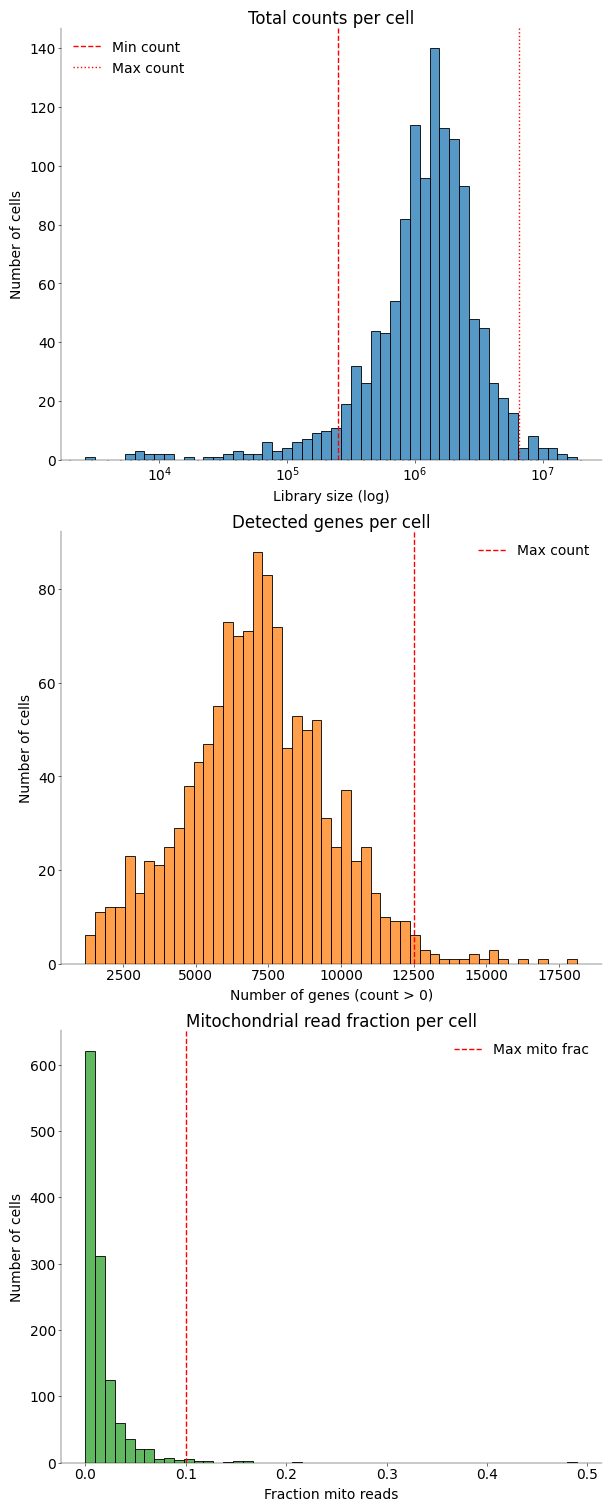

In [17]:
# RUN THIS

# 4. Plot histograms of per-cell metrics
fig, axs = plt.subplots(3, 1, figsize=(6, 15))

# Total counts per cell
sns.histplot(total_counts, bins=50, log_scale=(True, False), ax=axs[0])
min_count_thresh = 2.5 * 1e5
max_count_thresh = 6.5 * 1e6
axs[0].axvline(
    min_count_thresh, color="red", linestyle="--", label="Min count"
)
axs[0].axvline(max_count_thresh, color="red", linestyle=":", label="Max count")
axs[0].set_title("Total counts per cell")
axs[0].set_xlabel("Library size (log)")
axs[0].set_ylabel("Number of cells")
axs[0].legend()

# Number of detected genes per cell
sns.histplot(n_genes, bins=50, ax=axs[1], color="C1")
max_n_genes_thresh = 12500
axs[1].axvline(
    max_n_genes_thresh, color="red", linestyle="--", label="Max count"
)
axs[1].set_title("Detected genes per cell")
axs[1].set_xlabel("Number of genes (count > 0)")
axs[1].set_ylabel("Number of cells")
axs[1].legend()

# Mitochondrial fraction per cell
sns.histplot(mito_frac, bins=50, ax=axs[2], color="C2")
max_mito_frac_thresh = 0.1
axs[2].axvline(
    max_mito_frac_thresh, color="red", linestyle="--", label="Max mito frac"
)
axs[2].set_title("Mitochondrial read fraction per cell")
axs[2].set_xlabel("Fraction mito reads")
axs[2].set_ylabel("Number of cells")
axs[2].legend()

plt.show()


**Total Counts per Cell (Library Size)**
- **Observation**: Peaks around 10⁶ reads; wide range from ~10⁴ to >10⁷.
- **Filter rationale**:
  - **$< 2.5×10^5$**: Likely empty droplets or failed captures → high noise, dropout.
  - **$> 6.5×10^6$**: Potential doublets → abnormally high total RNA from merged cells.

**Detected Genes per Cell**
- **Observation**: Most cells have 6 000–8 000 genes; tails on both sides.
- **Filter rationale**:
  - **> 12,500 genes**: Likely doublets → combined gene sets from multiple cells.

**Mitochondrial Read Fraction**
- **Observation**: Most cells < 5%; some above 10% up to 50%.
- **Filter rationale**:
  - **> 10% mito reads**: Damaged/dying cells → stress-related expression, technical artifacts.

Overall, these filters remove low-quality or non-single-cell profiles and improve normalization, variance modeling, clustering, and overall interpretability.


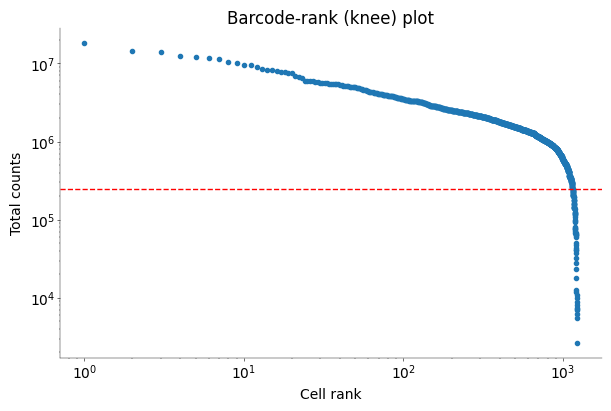

In [18]:
# 5. Barcode‐rank ("knee") plot
sorted_counts = np.sort(total_counts.values)[::-1]
ranks = np.arange(1, len(sorted_counts) + 1)
plt.figure(figsize=(6, 4))
plt.loglog(ranks, sorted_counts, marker=".", linestyle="none")
plt.xlabel("Cell rank")
plt.ylabel("Total counts")
plt.title("Barcode‐rank (knee) plot")
plt.axhline(y=min_count_thresh, color="red", linestyle="--")
plt.show()

This plot shows total RNA counts per cell ranked in descending order. The sharp drop ("knee") around rank 1,100 separates high-quality cells from low-quality ones. Cells after the knee are likely low-quality captures, empty droplets, or damaged cells with degraded RNA. The wide range in counts (~20×) suggests we should use normalization methods that account for large library size differences (e.g., DESeq2, TMM, or scran). The top few barcodes may be doublets due to abnormally high counts.

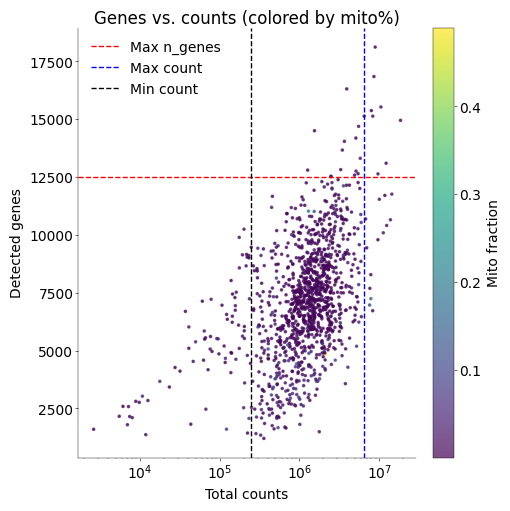

In [19]:
# 6. Scatter: detected genes vs. counts colored by mitochondrial fraction
plt.figure(figsize=(5, 5))
plt.scatter(
    total_counts, n_genes, c=mito_frac, cmap="viridis", s=10, alpha=0.7
)
plt.colorbar(label="Mito fraction")
plt.xlabel("Total counts")
plt.ylabel("Detected genes")
plt.title("Genes vs. counts (colored by mito%)")
plt.axhline(
    y=max_n_genes_thresh, color="red", linestyle="--", label="Max n_genes"
)
plt.axvline(
    x=max_count_thresh, color="blue", linestyle="--", label="Max count"
)
plt.axvline(
    x=min_count_thresh, color="black", linestyle="--", label="Min count"
)
plt.legend()
plt.xscale("log")
plt.show()

This plot shows a clear positive correlation between total counts and the number of detected genes per cell, as expected.  
Most cells cluster tightly between $10^5$–$10^7$ reads and 5,000–10,000 genes, with low mitochondrial fractions (< 0.1), indicating high-quality captures.  

A few cells in the bottom-left have low counts, low gene numbers, and elevated mito%, suggesting damaged or dying cells—these should be filtered out.  
A small group in the top-right with very high counts and gene numbers are likely doublets and should be flagged for removal or inspection.


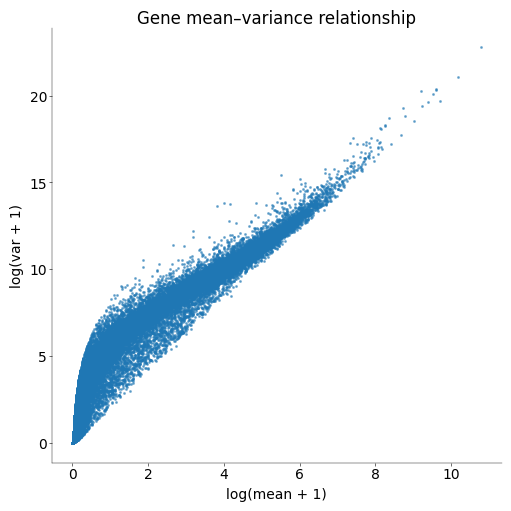

In [20]:
# 7. Gene‐level statistics
gene_means = df_counts.mean(axis=0)
gene_vars = df_counts.var(axis=0)
dropout_rate = (df_counts == 0).sum(axis=0) / df_counts.shape[0]

# 7a. Mean–variance relationship (log–log)
plt.figure(figsize=(5, 5))
plt.scatter(np.log1p(gene_means), np.log1p(gene_vars), s=5, alpha=0.5)
plt.xlabel("log(mean + 1)")
plt.ylabel("log(var + 1)")
plt.title("Gene mean–variance relationship")
plt.show()

This plot shows a strong positive relationship between mean and variance, with variance clearly exceeding the mean across most genes. This confirms that our data is over‑dispersed, as expected for raw read counts (not UMI-based), which include amplification noise and biological variability. A Poisson model would underestimate this variance, so downstream steps, such as highly variable gene selection or NB-mixture clustering, should use models or transforms that account for over-dispersion.

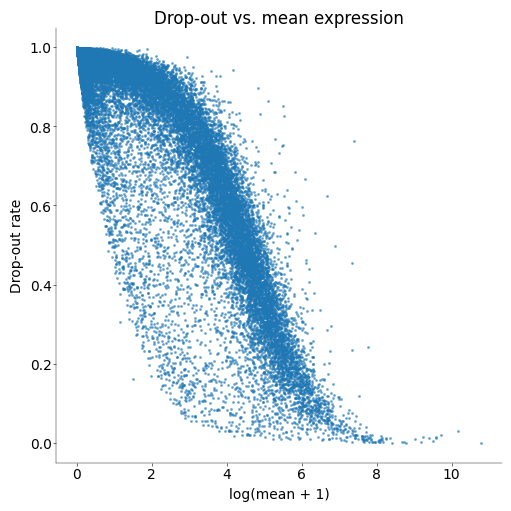

In [21]:
# 7b. Drop‐out rate vs. mean expression
plt.figure(figsize=(5, 5))
plt.scatter(np.log1p(gene_means), dropout_rate, s=5, alpha=0.5)
plt.xlabel("log(mean + 1)")
plt.ylabel("Drop‐out rate")
plt.title("Drop‐out vs. mean expression")
plt.show()

**Drop-out vs. mean expression:**
This plot shows the expected “L”-shaped relationship: genes with low average expression drop out in nearly all cells, while highly expressed genes are detected more consistently.

* Genes **above** the main curve (higher drop-out than expected) may be poorly captured or spurious, and are candidates for filtering.
* Genes **below** the curve (lower drop-out than expected) are often strong, cell-type–specific markers and should be retained.

The smooth decay and lack of anomalous outliers suggest sensible capture and alignment. Based on this, we can safely filter out genes with very low mean expression (e.g., log(mean+1) < 1) or drop-out rates above 95% before selecting highly variable genes.


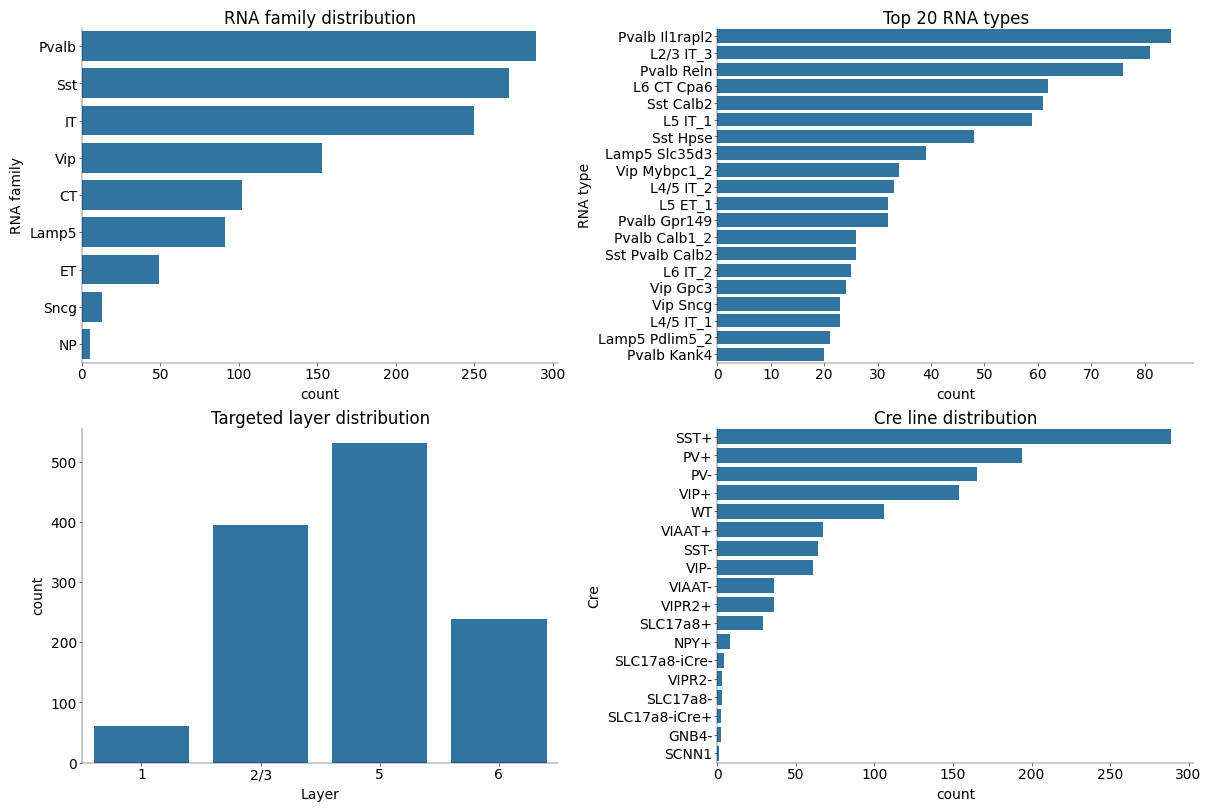

In [22]:
# 8. Plot metadata distributions for external validation
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# RNA family
sns.countplot(
    y="RNA family",
    data=meta_qc,
    order=meta_qc["RNA family"].value_counts().index,
    ax=axs[0, 0],
)
axs[0, 0].set_title("RNA family distribution")

# RNA type (subset top 20 for readability)
top_types = meta_qc["RNA type"].value_counts().nlargest(20).index
sns.countplot(
    y="RNA type",
    data=meta_qc[meta_qc["RNA type"].isin(top_types)],
    order=top_types,
    ax=axs[0, 1],
)
axs[0, 1].set_title("Top 20 RNA types")

# Targeted layer
sns.countplot(
    x="Targeted layer",
    data=meta_qc,
    order=sorted(meta_qc["Targeted layer"].unique()),
    ax=axs[1, 0],
)
axs[1, 0].set_title("Targeted layer distribution")
axs[1, 0].set_xlabel("Layer")

# Cre line
sns.countplot(
    y="Cre",
    data=meta_qc,
    order=meta_qc["Cre"].value_counts().index,
    ax=axs[1, 1],
)
axs[1, 1].set_title("Cre line distribution")

plt.show()

- **RNA Family Distribution:** The dataset is heavily imbalanced, with three families—**Pvalb**, **Sst**, and **IT**—making up the majority of the cells. In contrast, families such as **Sncg** and **NP** are extremely rare. This imbalance affects clustering validation and classification metrics, as dominant families can overwhelm signal from rare types. For downstream analysis, especially when evaluating clustering or differential expression, it may be necessary to filter or downsample to ensure fair representation.

- **RNA Type Distribution:** While there are 77 distinct RNA types, most are represented by very few cells. Even within the top 20 types, the number of cells per type varies widely (e.g., from ~90 down to ~20). This long-tailed distribution makes it difficult to use RNA type labels reliably for clustering validation. It may be more meaningful to validate at the RNA **family** level or group very rare types into an "Other" category.

- **Targeted Layer Distribution:** The vast majority of cells are from cortical layers **2/3**, **5**, and **6**, with almost very few from layer 1. This sampling bias implies that any observed transcriptomic gradients may reflect anatomical sampling (e.g., 2/3 $\to$ 5 $\to$ 6) rather than biological continua. It also means we cannot draw any conclusions about layer 1.

- **Cre Line Distribution:** The dataset includes several dominant Cre lines (e.g., **SST$^+$**, **PV$^⁺$**, **VIP$^⁺$**), but many others are represented by very few cells. This suggests that Cre line identity may act as a confounding batch effect in some analyses. In visualizations like PCA or UMAP, coloring by Cre line can help detect such artefactual structure. When using Cre information for external validation, it's best to focus on the larger groups.

**Conclusion:** These metadata patterns highlight strong group imbalances and sampling biases in the dataset. In all downstream analyses (normalization, visualization, clustering, and validation) these imbalances must be taken into account. Most importantly, validation should be done at the **RNA family** level (9 groups), rather than using the full 77 RNA types, due to the extreme class imbalance and sparsity.


In [18]:
# RUN THIS

# Compute removals
removed_low = np.sum(total_counts < min_count_thresh)
removed_high = np.sum(total_counts > max_count_thresh)
removed_high_genes = np.sum(n_genes > max_n_genes_thresh)
removed_mito = np.sum(mito_frac > max_mito_frac_thresh)

n_cells = len(meta_qc)
print(f"Total cells before QC: {n_cells}")
print(
    f"  - Removed {removed_low} cells with < {min_count_thresh:.0f} reads "
    f"({removed_low/n_cells:.1%})"
)
print(
    f"  - Removed {removed_high} cells with > {max_count_thresh:.0f} reads "
    f"({removed_high/n_cells:.1%})"
)
print(
    f"  - Removed {removed_high_genes} cells with > {max_n_genes_thresh} genes "
    f"({removed_high_genes/n_cells:.1%})"
)
print(
    f"  - Removed {removed_mito} cells with mito fraction > {max_mito_frac_thresh:.0%} "
    f"({removed_mito/n_cells:.1%})"
)

# Build the combined “keep” mask
keep_mask = (
    (total_counts >= min_count_thresh)
    & (total_counts <= max_count_thresh)
    & (n_genes <= max_n_genes_thresh)
    & (mito_frac <= max_mito_frac_thresh)
)

# Report final counts
n_keep = keep_mask.sum()
print(
    f"Cells passing all filters: {n_keep} / {n_cells} ({n_keep/n_cells:.1%})\n"
)

Total cells before QC: 1224
  - Removed 78 cells with < 250000 reads (6.4%)
  - Removed 22 cells with > 6500000 reads (1.8%)
  - Removed 23 cells with > 12500 genes (1.9%)
  - Removed 17 cells with mito fraction > 10% (1.4%)
Cells passing all filters: 1094 / 1224 (89.4%)



In [19]:
# RUN THIS

exonCounts = exonCounts[keep_mask, :]
meta_qc = meta_qc[keep_mask.values]
df_counts = df_counts[keep_mask]

In [25]:
meta_qc.isna().any(axis=0)

Number                      False
Cell                        False
Slice                       False
Date                        False
Sample                      False
Mouse                       False
Mouse date of birth         False
Mouse age                   False
Mouse gender                False
Mouse genotype              False
Targeted layer              False
Inferred layer              False
Cre                         False
Exon reads                  False
Intron reads                False
Intergenic reads            False
Sequencing batch            False
Number of genes detected    False
RNA family                  False
RNA type                    False
RNA type confidence         False
RNA type top-3              False
ALM/VISp top-3              False
Length (bp)                 False
Yield (pg/µl)                True
User                        False
Hold Time (min)              True
Soma depth (µm)              True
Soma depth (4x)              True
Cortical thick

We compute how many cells are filtered out based on quality control thresholds for RNA content:

1. Total counts: We remove cells with very low total reads (< min threshold),
   which likely represent empty droplets or failed captures, and very high counts (> max threshold),
   which may indicate doublets or multiplets (i.e., multiple cells sequenced together).

2. Detected genes: We remove cells expressing an abnormally high number of genes,
   another indicator of doublets where gene expression from multiple cells is merged.

3. Mitochondrial fraction: We remove cells with a high percentage of mitochondrial reads,
   a common marker of stressed or dying cells. These cells often show degraded transcriptomes
   and distort downstream analyses.

These filters are applied jointly to build a boolean mask (`keep_mask`) identifying high-quality,
single-cell profiles. This conservative filtering improves normalization, variance modeling,
clustering, and interpretability throughout the pipeline.


In [20]:
# RUN THIS

# 1) Compute per‐gene mean (on CPM or raw counts)
gene_means = exonCounts.mean(axis=0)

# 2) Build a boolean mask of genes to keep
keep = np.ones_like(gene_means, dtype=bool)
#   a) drop very low‐expressed
keep &= gene_means > 0.1
#   b) drop mito
keep &= ~np.char.startswith(genes.astype(str), "MT-")
#   c) drop ribosomal
keep &= ~(
    np.char.startswith(genes.astype(str), "Rps")
    | np.char.startswith(genes.astype(str), "Rpl")
)

exonCounts = exonCounts[:, keep]
exonLengths = exonLengths[keep]
genes = genes[keep]

We apply the following gene-level filters to clean up the feature space before selecting HVGs:

1. Drop very lowly expressed genes (`gene_means > 0.1`)
   Rationale: Genes with extremely low expression carry little information about cellular identity
   and are dominated by sampling noise. Removing them reduces the multiple-testing burden,
   speeds up downstream steps, and prevents spuriously high dispersion scores for near-zero means.
   This aligns with best practices (Luecken & Theis, 2019), which recommend filtering genes not
   expressed in enough cells.

2. Drop mitochondrial genes (`~startswith("MT-")`)
   Rationale: Mitochondrial transcripts reflect stress, apoptosis, or ambient RNA rather than
   biological variation. They often score highly for variance due to cell damage, not cell type.
   Removing them ensures HVGs reflect meaningful biological signal. This is consistent with the
   practice of ignoring strongly ambient genes in downstream steps.

3. Drop ribosomal genes (`~(startswith("Rps") | startswith("Rpl"))`)
   Rationale: Ribosomal protein genes are highly and broadly expressed housekeeping genes.
   Their variability is often technical or prep-related and not informative for distinguishing
   cell types. Removing them ensures HVG selection focuses on relevant biology, not general
   translation machinery. This fits the broader recommendation to remove technical covariates
   before feature selection.

These filters refine our gene set to focus on informative, biologically meaningful variation
and are fully consistent with current best practices in single-cell analysis.


### 1.2 - Electrophysiology

**Electrophysiological Metrics:**

In [31]:
# 1. What kind of ephys features are there?
for ephys_feature_name in ephysNames_filtered:
    print(ephys_feature_name)

AP amplitude (mV)
AP amplitude adaptation index
AP coefficient of variation
AP threshold (mV)
AP width (ms)
Afterhyperpolarization (mV)
ISI adaptation index
ISI coefficient of variation
Input resistance (MOhm)
Latency (ms)
Max number of APs
Membrane time constant (ms)
Rebound (mV)
Resting membrane potential (mV)
Rheobase (pA)
Sag ratio
Upstroke-to-downstroke ratio


Based on Sacal et al 2021 and similar Patch-seq studies by Gouwens et al 2019, 2020 (https://doi.org/10.1016/j.cell.2020.09.057, https://doi.org/10.1038/s41593-019-0417-0), we reseached the meaning and typical ranges for each ephys feature: 
- **AP amplitude (mV)**: The height of the first action potential, measured from threshold to peak.
- **AP amplitude adaptation index**: Ratio of the second AP amplitude to the first; the average adaptation index is the mean ratio of consecutive AP amplitudes across low-current traces (median of five lowest currents).
- **AP coefficient of variation (CV)**: The variability of AP amplitudes in the highest firing trace, calculated as standard deviation divided by mean.
- **AP threshold (mV)**: Membrane potential level at which the first AP is initiated.
- **AP width (ms)**: Duration of the AP at half-height (full-width at half-maximum of the first spike).
- **Afterhyperpolarization (AHP, mV)**: The depth of the hyperpolarizing trough following the first AP, relative to baseline.
- **ISI adaptation index**: The ratio of the second interspike interval (ISI) to the first. The average index is the mean ratio across consecutive ISIs, median-aggregated over the five lowest depolarizing currents.
- **ISI coefficient of variation (CV)**: Variability in ISI lengths within the highest firing trace, defined as standard deviation divided by mean.
- **Input resistance (MΩ)**: Calculated from the voltage response to hyperpolarizing current pulses (Ohm’s law: V/I).
- **Latency (ms)**: Time delay from current onset (20 pA above rheobase threshold) to the peak of the first AP.
- **Max number of APs**: Total spikes generated in the 600 ms stimulation window at the highest firing current.
- **Membrane time constant (τ, ms)**: From hyperpolarizing pulses, the time constant of the exponential voltage decay, median-aggregated over traces.
- **Rebound (mV)**: Post-hyperpolarization depolarization magnitude above baseline: average voltage 150 ms after rebound onset (within 300 ms window).
- **Resting membrane potential (mV)**: Baseline membrane voltage before stimulation.
- **Rheobase (pA)**: Minimum current amplitude needed to evoke an action potential, estimated from regression.
- **Sag ratio**: When a negative current pulse is applied to a neuron, the membrane rapidly hyperpolarizes to a peak voltage and then “sags” back toward a less negative steady-state voltage due to activation of inward rectifying currents. The sag ratio denotes the ratio of sag amplitude to steady-state hyperpolarization, measured during the first hyperpolarizing pulse. Computed as (sag trough – resting)/(steady-state – resting). 
- **Upstroke-to-downstroke ratio (UDR)**: Ratio of max voltage derivative during AP rising phase to max derivative during falling phase (first spike only).

Typical Values:

| Metric                          | Typical Range     | Physiological Rationale                                                                                   |
|----------------------------------|-------------------------------|----------------------------------------------------------------------------------------------------------|
| AP amplitude (mV)                | 40–120                        | Amplitudes <40 mV suggest poor spike quality or failed recordings.                                       |
| AP amplitude adaptation index    | 0.1–2                         | Reflects change in spike amplitude during train; extreme values may indicate instability.                |
| AP coefficient of variation      | 0–1                        | High variability implies irregular spiking or bad recording.                                             |
| AP threshold (mV)                | -60 to -15                    | Spikes normally initiate between -55 and -30 mV; more depolarized thresholds may be artifact.            |
| AP width (ms)                    | 0.2–3                         | Fast-spiking neurons have narrow spikes (<1 ms); wider spikes (>3 ms) may be distorted.                  |
| ISI adaptation index             | 0.1–3                         | Reflects firing adaptation; extreme values may suggest unnatural firing behavior.                        |
| ISI coefficient of variation     | 0–2                           | High CV indicates burstiness or irregularity; beyond 2 suggests abnormal firing.                         |
| Input resistance (MΩ)            | 30–1000                       | Very low values may reflect leaky or damaged cells; high values may be seal artifacts.                   |
| Max number of APs                | 1–200                         | Too few = unresponsive, too many = unrealistic firing rates for typical neurons.                         |
| Membrane time constant (ms)      | 2–50                         | Reflects passive membrane properties; very small or large values may be artifactual.                     |
| Rebound (mV)                     | 0–20                          | Rebound depolarization indicates Ih or T-type Ca²⁺ channels; extreme rebound may be noise.               |
| Resting membrane potential (mV)  | -90 to -45                    | Too depolarized or hyperpolarized suggests damage or poor seal.                                          |
| Rheobase (pA)                    | 5–1000                       | Reflects excitability; extreme values may suggest failed stimulation or low viability.                        |
| Upstroke-to-downstroke ratio     | 0.5–10                        | Shape descriptor of AP waveform; extreme values often indicate noise or misdetection.                    |

We then use the typical values for thresholding to check the quality control by Scala et al., 2021.

**Distributions, Correlations and Outliers:**

In [21]:
# 2. Plot metrics, their pairwise correlations, and find potential outliers

# Prepare the data for pairplot
ephys_df = pd.DataFrame(ephysData_filtered, columns=ephysNames_filtered)

ephys_names_abbreviated = [
    "AP amp (mV)",  # AP amplitude
    "AP amp AI",  # AP amplitude adaptation index
    "AP CV",  # Coefficient of variation of action potentials
    "AP thresh (mV)",  # AP threshold
    "AP width (ms)",
    "AHP (mV)",  # Afterhyperpolarization
    "ISI AI",  # ISI adaptation index
    "ISI CV",  # Coefficient of variation of inter-spike intervals
    "R_input (MΩ)",  # Input resistance
    "Latency (ms)",
    "Max # APs",  # Maximum number of action potentials
    "Tau (ms)",  # Membrane time constant
    "Rebound (mV)",  # Rebound potential
    "V_rest (mV)",  # Resting membrane potential
    "Rheobase (pA)",
    "Sag",  # Sag ratio
    "UDR",  # Upstroke-to-downstroke ratio
]
ephys_df.columns = ephys_names_abbreviated

# Compute thresholds for outlier detection, as described above
qc_thresholds = {
    "AP amp (mV)": (40, 120),
    "AP amp AI": (0.1, 2.0),
    "AP CV": (0, 1),
    "AP thresh (mV)": (-60, -15),
    "AP width (ms)": (0.2, 3),
    "ISI AI": (0.1, 3),
    "ISI CV": (0, 2),
    "R_input (MΩ)": (30, 1000),
    "Max # APs": (1, 200),
    "Tau (ms)": (2, 50),
    "Rebound (mV)": (0, 20),
    "V_rest (mV)": (-90, -45),
    "Rheobase (pA)": (5, 1000),
    "UDR": (0.5, 10.0),
}
features_log = [
    "AP CV",
    "ISI CV",
    "ISI AI",
    "Latency (ms)",
]

outlier_thresholds = {}
for column in ephys_df.columns:
    # a) IQR rule to find outliers in robus manner
    q1 = ephys_df[column].quantile(0.25)
    q3 = ephys_df[column].quantile(0.75)
    iqr = q3 - q1
    out_lo = q1 - 1.5 * iqr
    out_hi = q3 + 1.5 * iqr

    # b) compare with QC threholds: if defined, use the lowest threshold
    if column in qc_thresholds:
        qc_lo, qc_hi = qc_thresholds[column]
        # For log-transformed metrics, use log of thresholds
        if column in features_log:
            qc_lo, qc_hi = np.log(qc_lo + 1e-6), np.log(
                qc_hi + 1e-6
            )  # + 1e-6 for values close to 0 for numerical stability
        lower = max(qc_lo, out_lo)
        upper = min(qc_hi, out_hi)
    else:
        # If no QC thresholds are defined, use IQR thresholds
        lower = out_lo
        upper = out_hi

    outlier_thresholds[column] = (lower, upper)

In [33]:
plt.rcParams.update({"font.size": 20})


# Define a function to compute correlation coefficients
def corr_func(x, y, **kwargs):
    if x.name != y.name:  # Only apply to non-diagonal subplots
        corr = np.corrcoef(x, y)[0, 1]
        ax = plt.gca()
        ax.annotate(
            f"r = {corr:.2f}",
            xy=(0.3, 0.9),
            xycoords=ax.transAxes,
            fontsize=20,
        )
        # Set the color of the points based on the correlation coefficient
        ax.scatter(
            x, y, c=np.full_like(x, corr), cmap="coolwarm", vmin=-1, vmax=1
        )


# Plot the pairplot with correlation coefficients
pairplot = sns.pairplot(ephys_df, diag_kind="kde", diag_kws={"fill": True})
pairplot = pairplot.map(corr_func)
pairplot.figure.suptitle(
    "Distributions and Pairwise Correlation Coefficients (r) of Electrophysiological Features",
    y=1.01,
    fontsize=50,
)

# Add vertical lines to visualize thresholds in diagonal plots
for i, ax in enumerate(pairplot.diag_axes):
    column = ephys_df.columns[i]
    lower, upper = outlier_thresholds[column]
    ax.axvline(
        lower,
        color="grey",
        linestyle="--",
        linewidth=2.5,
    )
    ax.axvline(
        upper,
        color="grey",
        linestyle="--",
        linewidth=2.5,
        label="Outlier\nthreshold",
    )
    if i % 5 == 0:
        ax.legend(
            frameon=True,
            fontsize=13,
        )

# Adjust the colorbar for correlation coefficients
fig = pairplot.figure
fig.subplots_adjust(bottom=0.06)  # Add space at the bottom
cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.02])  # Adjust position and size
sm = plt.cm.ScalarMappable(
    cmap="coolwarm", norm=plt.Normalize(vmin=-1, vmax=1)
)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Correlation Coefficient (r)", fontsize=30)

plt.show()

/Users/abbas/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


KeyboardInterrupt: 

We observe:

1. **Skewed Distributions and outliers**: The plot shows the neural distribution of the ephys metrics on the diagonals, with outlier thresholds per ephys feature determined as the strictest thresholds of typical ranges (if available) and as derived from the common IQR rule (see e.g. Exploratory Data Analysis, Tukey, J. W. (1977)): compute the first $Q_1$ and third $Q_3$ quartiles and the interquartile range $ \mathrm{IQR} = Q_3 - Q_1$ for an ephys feature, then a value $x$ of the feature is an outlier if it falls outside the interval:
    $$      
    x \notin \left[ Q_1 - 1.5\,\mathrm{IQR},\;\; Q_3 + 1.5\,\mathrm{IQR} \right]
    \text{  with   }
    \mathrm{IQR} = Q_3 - Q_1            
    $$

    We observe that some ephys features, e.g. the rheobase or AP amplification adaptation index, have non-gaussian, skewed distributions (at least when plotting all cell types together). This explains the use of the IQR-rule - a robust method for outlier detection for asymmetric  distributions. We verify our derived outlier thresholds by eye.  

2. **High correlation between UDR and AP width**:
    The plot shows the pairwise Pearson correlation coefficients between ephys features on the off-diagonals, with stronger colors indicating stronger (absolute) correlations. We find that two features, AP width and Upstroke-to-downstroke ratio (UDR), are highly correlated ($r \approx 0.94$). This can be explained by the fact that the first APs usually are of similar size, such that the curvature of the AP curve correlates with the AP width. [We also checked, not shown here, that this correlation is found accross neuron types (using the ground truth labels).]. To avoid redundant features, one of the highly correlated features, UDR, is therefore later dropped from further analysis.

In [22]:
# 3. Filter out cells and features

# a) Filter out cells according to quality control of rna seq data (1.1)
ephysData_filtered = ephysData_filtered[keep_mask]

# b) Filter out UDR feature
filtered_features = ["UDR"]
filtered_feature_mask = [
    e not in filtered_features for e in ephysNames_filtered
]
ephysNames_filtered = ephysNames_filtered[filtered_feature_mask]
ephysData_filtered = ephysData_filtered[:, filtered_feature_mask]

# c) Filter out cells according to quality control of ephys data
ephys_df = pd.DataFrame(ephysData_filtered, columns=ephysNames_filtered)
outliers_count = np.zeros(ephys_df.shape[0], dtype=int)
# Add a boolean column indicating if each cell is an outlier (True = outlier)
for column, (lower, upper) in outlier_thresholds.items():
    if column not in ephys_df.columns:
        continue  # Skip previously filtered columns
    # identify outliers across ephys features
    outliers_count += (ephys_df[column] < lower) | (ephys_df[column] > upper)

no_outliers_mask = (
    outliers_count < 2
)  # threshold = at least outlier in 2 different features

ephys_df["outlier"] = ~no_outliers_mask

print(
    f"Number of detected outlier neurons: {no_outliers_mask.shape[0] - no_outliers_mask.sum()}"
)

Number of detected outlier neurons: 10


We only find a small number of outlier neurons. This fits the expectations that the ephys features are already of high quality, since their qualit has been checked as described in Scala et al., 2021.

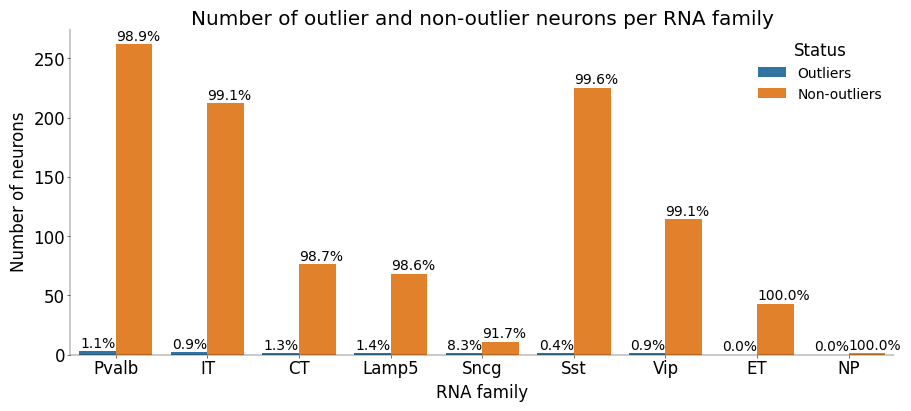

In [23]:
# 4. verify that the filtering does not dominantly remove cells of specific RNA families

# Add the cell family labels to the DataFrame
ephys_df["RNA family"] = rna_family

# Count outlier cells per RNA family
outlier_counts = (
    ephys_df.groupby("RNA family")["outlier"]
    .sum()
    .sort_values(ascending=False)
)
non_outlier_counts = (
    ephys_df.groupby("RNA family")["outlier"]
    .apply(lambda x: (~x).sum())
    .sort_values(ascending=False)
)

# Bar plot
plt.rcParams.update({"font.size": 12})
plt.figure(figsize=(9, 4))

# Prepare DataFrame for grouped barplot
bar_df = pd.DataFrame(
    {
        "RNA family": outlier_counts.index,
        "Outliers": outlier_counts.values,
        "Non-outliers": non_outlier_counts.reindex(
            outlier_counts.index
        ).values,
    }
)
bar_df = bar_df.melt(
    id_vars="RNA family",
    value_vars=["Outliers", "Non-outliers"],
    var_name="Status",
    value_name="Count",
)

# Calculate percentage of outlier cells per RNA family
percent_outliers = 100 * outlier_counts / (outlier_counts + non_outlier_counts)

# Add percentage labels on top of the "Outliers" bars
for i, family in enumerate(outlier_counts.index):
    non_outlier_val = non_outlier_counts[family]
    outlier_val = outlier_counts[family]
    pct = percent_outliers[family]
    # Find the position of the "Outliers" bar for this family
    bar_pos = bar_df[
        (bar_df["RNA family"] == family) & (bar_df["Status"] == "Outliers")
    ].index[0]
    plt.text(
        i,
        outlier_val + 1,  # slightly above the bar
        f"{pct:.1f}%",
        ha="right",
        va="bottom",
        fontsize=10,
        color="black",
        rotation=0,
    )
    plt.text(
        i,
        non_outlier_val + 1,  # slightly above the bar
        f"{100 - pct:.1f}%",
        ha="left",
        va="bottom",
        fontsize=10,
        color="black",
        rotation=0,
    )


sns.barplot(
    data=bar_df,
    x="RNA family",
    y="Count",
    hue="Status",
)

plt.ylabel("Number of neurons")
plt.xlabel("RNA family")
plt.title("Number of outlier and non-outlier neurons per RNA family")
plt.show()

The plot shows the number of outlier and non-outlier neurons per RNA family, as given by the "ground-truth labels", with percentage relative to the total number of neurons in the corresponding RNA family indicated in numbers on top of the corresponding bar. This assures us that the outlier neurons are approximately equally distributed (around 1% outlier rate) across cell family, and our thresholds don't dominantely pick up one neuron family. The exception is the Sncg family with an 8\% outlier rate, but this can be explained by the low number of neurons (<20) in this family.

In [24]:
# 5. finally filter the ephys, rna seq and meta data
print(
    "Before filtering:",
    ephysData_filtered.shape,
    exonCounts.shape,
    df_counts.shape,
    meta_qc.shape,
)

ephysData_filtered = ephysData_filtered[no_outliers_mask]
exonCounts = exonCounts[no_outliers_mask]
meta_qc = meta_qc.loc[no_outliers_mask.values]
df_counts = df_counts.loc[no_outliers_mask.values]

print(
    "After filtering:",
    ephysData_filtered.shape,
    exonCounts.shape,
    df_counts.shape,
    meta_qc.shape,
)

Before filtering: (1094, 17) (1094, 26350) (1094, 42466) (1094, 37)
After filtering: (1084, 17) (1084, 26350) (1084, 42466) (1084, 37)


In [25]:
# 6. Z score data
ephysData_filtered = ephysData_filtered - ephysData_filtered.mean(axis=0)
ephysData_filtered = ephysData_filtered / ephysData_filtered.std(axis=0)

# since the metrics have been z-scored, units aren't correct anymore
# change the name to not include units anymore
ephysNames_filtered = [
    "AP amp",  # AP amplitude
    "AP amp AI",  # AP amplitude adaptation index
    "AP CV",  # Coefficient of variation of action potentials
    "AP thresh",  # AP threshold
    "AP width",
    "AHP",  # Afterhyperpolarization
    "ISI AI",  # ISI adaptation index
    "ISI CV",  # Coefficient of variation of inter-spike intervals
    "R_input",  # Input resistance
    "Latency",
    "Max # APs",  # maximum number of action potentials
    "Tau",  # Membrane time constant
    "Rebound",
    "V_rest",  # Resting membrane potential
    "Rheobase",
    "Sag",  # Sag ratio
]

---
## 2 - Normalize & transform the data; select genes & apply PCA

There are several ways of normalizing the RNA count data (Raw, CPM, CPMedian, RPKM, see https://www.reneshbedre.com/blog/expression_units.html, https://translational-medicine.biomedcentral.com/articles/10.1186/s12967-021-02936-w). Take into account that there are certain normalizations that only make sense for UMI data, but not for this read count data. You also explored different transformations in the assignment (none, log, sqrt). Compare how the different transformations change the two-dimensional visualization. After normalization and transformation, choose a set of highly variable genes (as demonstrated in the lecture) and apply PCA. Play with the number of selected genes and the number of PCA components, and again compare their effects on the two-dimensional visualization.

1. Yes— scran is a third, single‑cell–focused method for estimating size factors, alongside DESeq2’s median‑of‑ratios and edgeR’s TMM. The key difference is:

    DESeq2 / TMM were designed for bulk RNA‑seq, where each sample has relatively shallow sparsity. They estimate each cell’s or sample’s scaling factor by comparing it to a reference (geometric mean across all samples for DESeq2; a median‑size reference for TMM) and trimming or down‑weighting extreme genes.

    scran (Lun et al., 2016) is built for very sparse single‑cell data. It pools small groups of cells together to form “pseudo‑bulk” samples, estimates size factors on those pools (where the data are dense enough), and then deconvolves back to individual cells.

        Why scran? In scRNA‑seq you often have many zeros (drop‑outs), so directly computing ratios or M‑values per cell can be unstable. Pooling borrows strength across cells to get more reliable estimates.

In [26]:
# RUN THIS


# Normalization functions
def cpm_norm(counts):
    return counts / counts.sum(axis=1, keepdims=True) * 1e6


def cpm_median_norm(counts):
    """
    CPMedian normalization: like CPM but scaling by the median library size
    (total counts) across all cells instead of 1e6.

    counts: array of shape (n_cells, n_genes)
    returns: array of same shape, normalized counts
    """
    # total counts per cell
    lib_sizes = counts.sum(axis=1, keepdims=True)
    # median library size (scalar)
    median_size = np.median(lib_sizes)
    # avoid division by zero
    # lib_sizes[lib_sizes == 0] = np.nan
    # normalize each cell by its library size, then scale up to the median
    return counts / lib_sizes * median_size


def rpkm_norm(counts, exon_lengths_bp):
    """
    RPKM normalization: Reads Per Kilobase per Million mapped reads.

    counts:           array of shape (n_cells, n_genes)
    exon_lengths_bp:  1‑d array of length n_genes, gene lengths in base pairs

    RPKM = counts * 1e9 / (length_bp * total_counts_per_cell)
    """
    # total counts per cell
    lib_sizes = counts.sum(axis=1, keepdims=True)
    # lib_sizes[lib_sizes == 0] = np.nan

    # broadcast gene lengths to shape (1, n_genes)
    lengths = exon_lengths_bp[None, :]
    # avoid division by zero
    # lengths[lengths == 0] = np.nan

    # compute RPKM
    return counts * 1e9 / (lengths * lib_sizes)


def deseq2_norm_manual(counts, min_cells=3, eps=1e-8):

    # keep genes with some minimal expression
    gene_mask = (counts > 0).sum(axis=0) >= min_cells
    X = counts[:, gene_mask]
    # geometric mean of each kept gene across cells
    gm = np.exp(np.mean(np.log(X + eps), axis=0))
    # make sure gm is never zero
    gm[gm == 0] = np.nan

    # ratios for every cell / gene
    ratios = X / gm
    # size factor per cell = median of (non‑zero) ratios
    size_factors = np.nanmedian(ratios, axis=1)
    # guard against cells with all‑zero genes after filtering
    size_factors[np.isnan(size_factors) | (size_factors == 0)] = 1.0
    # divide original counts (not the subset) by its cell’s size factor
    return counts / size_factors[:, None]


def deseq2_norm(counts):
    normalized_counts, size_factors = pydeseq2_norm(exonCounts)
    return normalized_counts


counts_dict = {
    "raw": exonCounts.copy(),
    "CPM": cpm_norm(exonCounts),
    "CPMedian": cpm_median_norm(exonCounts),
    "RPKM": rpkm_norm(exonCounts, exonLengths),
    "DESeq2": deseq2_norm(exonCounts),
}

# Transformations
transforms = {
    "linear": lambda X: X,
    "sqrt": lambda X: np.sqrt(X),
    "log1p": lambda X: np.log1p(X),
}

# Pre-compute all normalized and transformed matrices
#    keys are tuples (norm_name, tfm_name)
transformed_data = {}
for norm_name, counts in counts_dict.items():
    for tfm_name, tfm in transforms.items():
        transformed_data[(norm_name, tfm_name)] = tfm(counts)


# HVG selection function
def select_hvg(X, n_top=2000, n_bins=20):
    """
    Manual HVG selection: bin by mean, z‑score dispersion within each bin.
    """
    mu = np.nanmean(X, axis=0)
    var = np.nanvar(X, axis=0, ddof=1)
    disp = var / (mu + 1e-12)

    # Bin genes by mean (dropping NaN means)
    valid = ~np.isnan(mu)
    bins = pd.qcut(mu[valid], q=n_bins, labels=False, duplicates="drop")
    disp_z = np.zeros_like(disp)
    for b in np.unique(bins):
        idx_b = np.where(valid)[0][bins == b]
        d_b = disp[idx_b]
        m, s = d_b.mean(), d_b.std(ddof=1)
        if s > 0:
            disp_z[idx_b] = (d_b - m) / s
        else:
            disp_z[idx_b] = 0.0

    # pick top
    n_select = min(n_top, disp_z.size)
    return np.argsort(disp_z)[-n_select:]


# PCA + Metrics
def run_pca_metrics(X, n_hvg=2000, n_pc=20):
    hvg_idx = select_hvg(X, n_hvg)
    X_hvg = X[:, hvg_idx]
    X_scaled = StandardScaler().fit_transform(X_hvg)
    pca = PCA(n_components=n_pc)
    pcs = pca.fit_transform(X_scaled)
    return {
        "pcs": pcs,
        "var_ratio": pca.explained_variance_ratio_,
    }


# Grid Search
hvg_sizes = [500, 1000, 2000]
n_pc_list = [10, 20, 50]

results = {}
for (norm_name, tfm_name), projected_data in transformed_data.items():
    for n_hvg in hvg_sizes:
        for n_pc in n_pc_list:
            key = (norm_name, tfm_name, n_hvg, n_pc)
            results[key] = run_pca_metrics(
                projected_data, n_hvg=n_hvg, n_pc=n_pc
            )

In [30]:
for key, val in transformed_data.items():
    if np.any(~np.isfinite(val)) or np.any(np.isnan(val)):
        print(key)

In [31]:
for key, val in results.items():
    if np.any(~np.isfinite(val["pcs"])) > 0 or np.any(np.isnan(val["pcs"])):
        print(key)

For Task 2, we made the following choices to ensure that our PCA reflects true biological variation rather than technical artifacts:

1. **Normalization**
   We use **DESeq2 size‑factor** normalization in addtion to simple CPM/RPKM/TPM because DESeq2 corrects not only for total read depth but also for compositional differences (i.e. when a few genes dominate the library). Zhao et al. (2021) showed that median‑of‑ratios (DESeq2) and TMM produce the lowest coefficient of variation and best clustering of biological replicates, whereas TPM/FPKM can be distorted by highly expressed genes. However **CPM, CPMedian, and RPKM** are still included as a baseline.

2. **Variance‑stabilising transformation**
   After normalization, counts remain skewed (many zeros, few very large values). We apply **$\log(1+x)$** (and compare to $\sqrt x$ or linear) because $\log$ compresses extremes and approximates normality, which makes PCA more meaningful. Square‑root is a milder alternative, and leaving the data untransformed reveals whether skew still dominates the PCs.

3. **Highly Variable Gene (HVG) selection**
   With tens of thousands of genes, most contribute only noise. We rank genes by their dispersion (variance/mean) across cells and select the top N (e.g. 2 000), focusing PCA on the features that drive real cell‑to‑cell differences.

4. **PCA on scaled HVGs**
   Finally, we z‑score each selected gene and run PCA (choosing 10, 20, or 50 components).

Each of these steps—robust normalization, log transform, HVG filtering, and PCA—builds on best practices for RNA‑seq visualization and is grounded in the evidence presented by Zhao et al.

**Note:** We postpone 2D visualizations (e.g., PCA scatter plots) to **Task 3**, which explicitly focuses on comparing dimensionality reduction methods (PCA, t-SNE, UMAP) and evaluating them using quantitative metrics as suggested in Lause et al. (2024). Since Task 3 includes both visualization and metric-based comparison, we avoid redundancy and defer all 2D embedding plots to that section.

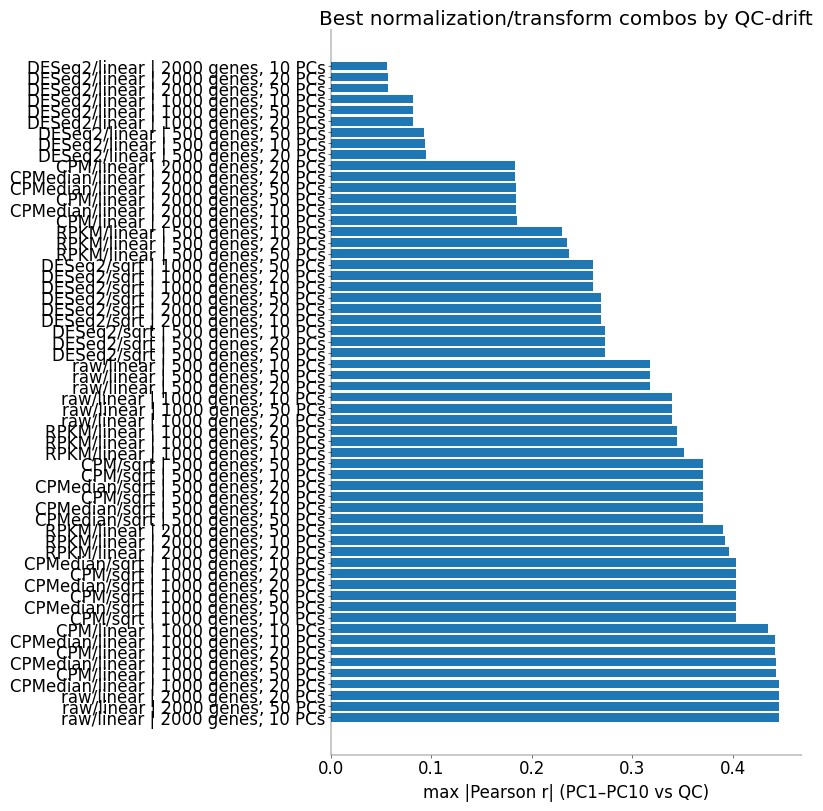

In [32]:
def compute_pc_qc_corr(pcs, qc_df, n_pcs=10):
    """
    pcs:      array of shape (n_cells, n_components)
    qc_df:    DataFrame of shape (n_cells, n_qc_metrics)
    n_pcs:    how many leading PCs to correlate

    Returns a DataFrame of shape (n_qc_metrics, n_pcs) whose (i,j) entry
    is corr( qc_df[col_i], pcs[:, j] ).
    """
    # 1) build a DataFrame for the first n_pcs
    pc_cols = [f"PC{j+1}" for j in range(n_pcs)]
    pcs_df = pd.DataFrame(pcs[:, :n_pcs], index=qc_df.index, columns=pc_cols)

    # 2) select only the numeric QC columns
    qc_numeric = qc_df.select_dtypes(include=[np.number])

    # 3) concat and compute full correlation matrix
    combined = pd.concat([pcs_df, qc_numeric], axis=1)
    corr_mat = combined.corr()

    # 4) extract the submatrix: rows = QC metrics, cols = PCs
    return corr_mat.loc[qc_numeric.columns, pc_cols]


def summarize_qc_drift(results, qc_df, n_pcs=10):
    rows = []
    for key, res in results.items():
        pcs = res["pcs"]
        # compute corr for first n_pcs
        corr = compute_pc_qc_corr(pcs, qc_df, n_pcs=n_pcs).abs()
        rows.append(
            {
                "norm": key[0],
                "transform": key[1],
                "n_hvg": key[2],
                "n_pc": key[3],
                "max_abs_r": corr.values.max(),
                "mean_abs_r": corr.values.mean(),
            }
        )
    return pd.DataFrame(rows)


summary_df = summarize_qc_drift(
    results, meta_qc[["total_counts", "n_genes", "mito_frac"]], n_pcs=10
)

# combine columns into a label
summary_df["label"] = (
    summary_df["norm"]
    + "/"
    + summary_df["transform"]
    + " | "
    + summary_df["n_hvg"].astype(str)
    + " genes, "
    + summary_df["n_pc"].astype(str)
    + " PCs"
)

# pick the top 10 best (lowest max_abs_r)
best10 = summary_df.nsmallest(60, "max_abs_r")

# plot
plt.figure(figsize=(8, 8))
plt.barh(best10["label"], best10["max_abs_r"])
plt.xlabel("max |Pearson r| (PC1–PC10 vs QC)")
plt.title("Best normalization/transform combos by QC‑drift")
plt.gca().invert_yaxis()
plt.show()

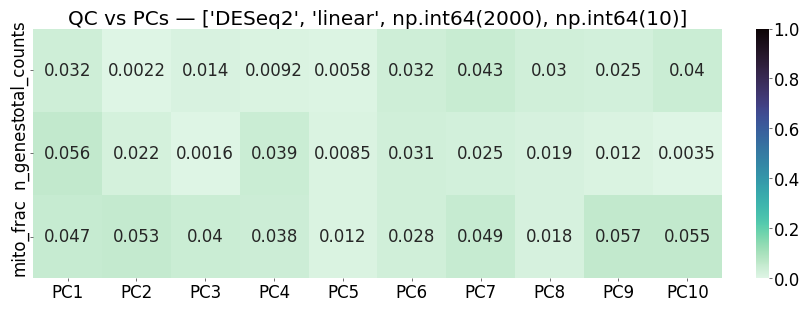

In [33]:
best_key = best10.iloc[0][["norm", "transform", "n_hvg", "n_pc"]].tolist()
pcs = results[tuple(best_key)]["pcs"]
corr_df = compute_pc_qc_corr(
    pcs, meta_qc[["total_counts", "n_genes", "mito_frac"]], n_pcs=10
)

plt.figure(figsize=(8, 3))
sns.heatmap(corr_df.abs(), annot=True, cmap="mako_r", vmin=0, vmax=1)
plt.title(f"QC vs PCs — {best_key}")
plt.show()

In [34]:
K = 100
best_keys = [
    tuple(r)
    for r in summary_df.nsmallest(K, "max_abs_r")[
        ["norm", "transform", "n_hvg", "n_pc"]
    ].values
]

# filter your results and adjust total_runs
filtered_results = {key: results[key] for key in best_keys}

**QC-Drift Analysis**

Before applying non-linear dimensionality reduction (e.g. t-SNE, UMAP), it is essential to ensure that the PCA representation is not dominated by technical artifacts such as:

- **Library size** (`total_counts`)
- **Number of detected genes** (`n_genes`)
- **Mitochondrial read fraction** (`mito_frac`)

If we skip this step, downstream 2D visualizations may misleadingly reflect sequencing quality rather than true biological structure.

To address this, we compute **Pearson correlations between the top principal components and these QC metrics**. For each preprocessing pipeline—defined by normalization method, transformation, number of highly variable genes (HVG), and number of PCA components—we measure:

- **`max_abs_r`**: the worst-case correlation (maximum absolute r across all PCs and QC metrics)
- **`mean_abs_r`**: the average absolute correlation (overall leakage)

This **QC-drift score** serves two key purposes:

1. **Validation**: It helps identify the *cleanest* PCA representations—those least confounded by technical noise—making them better foundations for downstream analysis.

2. **Filtering**: It drastically **reduces the embedding search space**.  
   Rather than applying t-SNE/UMAP to all normalization/transform/HVG/PCA combinations, we **restrict to the top-K lowest-drift pipelines**, which:
   - Speeds up computation
   - Focuses effort on meaningful, biologically driven embeddings
   - Avoids overfitting to artifacts like library size or mitochondrial bias

By applying QC-drift filtering before the embedding step, we ensure that our visualizations are both more **efficient** and more **biologically interpretable**.


---
## 3 - Two-dimensional visualization

To visualize the RNA count data after normalization, transformation, gene selection and PCA, try different methods (just PCA, t-SNE, UMAP, ..) and vary their parameters (exaggeration, perplexity, ..). Compare them using quantitative metrics (e.g., kNN accuracy in high-dim vs. two-dim, kNN recall). Please refer to Lause et al., 2024 (https://doi.org/10.1371/journal.pcbi.1012403) where many of these metrics are discussed and explained to make an informed choice on which metrics to use. Think about also using the electrophysiological features and other metadata to enhance different visualizations.

In [ ]:
# Encode RNA families for coloring
le = LabelEncoder()
fam_labels = le.fit_transform(meta_qc["RNA family"])
fam_categories = le.classes_

In [ ]:
# --- 8) two‑dimensional embeddings & evaluation --------------------------------
warnings.filterwarnings(
    "ignore",
    message=".*'force_all_finite' was renamed to 'ensure_all_finite'.*",
    category=FutureWarning,
)

# 8.1) registry of embedding methods
embed_fns = {
    "PCA2D": lambda P, **kw: PCA(n_components=2, **kw).fit_transform(P),
    "tSNE": lambda P, **kw: TSNE(n_components=2, **kw).fit_transform(P),
    "UMAP": lambda P, **kw: umap.UMAP(n_components=2, **kw).fit_transform(P),
}

# 8.2) hyper‑parameter grid
embed_params = []
# PCA‑2D baseline
embed_params.append(("PCA2D", {}))

# t‑SNE sweep
for perp in [5, 10, 30]:
    for exag in [4, 12]:
        embed_params.append(
            (
                "tSNE",
                {
                    "perplexity": perp,
                    "early_exaggeration": exag,
                    "learning_rate": "auto",
                    "init": "pca",
                    "random_state": 0,
                },
            )
        )

# UMAP sweep
for nnb in [15, 30]:
    for dist in [0.1, 0.5]:
        embed_params.append(
            (
                "UMAP",
                {
                    "n_neighbors": nnb,
                    "min_dist": dist,
                    "metric": "euclidean",
                    "random_state": 0,
                },
            )
        )


# 8.3) evaluation function for one 2D embedding
def evaluate_embedding(Y2d, labels, NN_hd, P_hd, k=10):
    # 2D neighbors
    NN_2d = (
        NearestNeighbors(n_neighbors=k)
        .fit(Y2d)
        .kneighbors(return_distance=False)
    )
    # kNN accuracy (label purity)
    preds = np.array([np.bincount(labels[nn]).argmax() for nn in NN_2d])
    knn_acc = (preds == labels).mean()
    # kNN recall (continuity)
    knn_recall = np.mean(
        [
            len(set(NN_hd[i]).intersection(NN_2d[i])) / k
            for i in range(len(labels))
        ]
    )
    # silhouette in 2D
    sil = silhouette_score(Y2d, labels)
    # trustworthiness
    trust = sk_trustworthiness(P_hd, Y2d, n_neighbors=k)
    # AMI via HDBSCAN
    clust = hdbscan.HDBSCAN(min_cluster_size=30).fit(Y2d)
    ami = adjusted_mutual_info_score(labels, clust.labels_)
    return dict(
        knn_acc=knn_acc,
        knn_recall=knn_recall,
        silhouette=sil,
        trust=trust,
        ami=ami,
    )


parallel = True
total_runs = len(filtered_results) * len(embed_params)
print(f"Total runs {total_runs}")
if not parallel:
    # 8.4) run embeddings & collect metrics
    embedding_results = {}

    # compute total number of runs
    run_counter = 1

    for key, pca_out in filtered_results.items():
        # pca_out['pcs'] is the HD representation of shape (n_cells, n_pc)
        P_hd = pca_out["pcs"]
        # precompute HD neighbor graph
        NN_hd = (
            NearestNeighbors(n_neighbors=10)
            .fit(P_hd)
            .kneighbors(return_distance=False)
        )

        for method, params in embed_params:
            print(
                f"[{run_counter}/{total_runs}] "
                f"Config={key} → Embedding={method}, params={params}"
            )

            # perform embedding
            Y2d = embed_fns[method](P_hd, **params)

            # evaluate
            metrics = evaluate_embedding(Y2d, fam_labels, NN_hd, P_hd, k=10)
            embedding_results[(key, method, tuple(sorted(params.items())))] = (
                metrics
            )

            print(
                f"    → Done: knn_acc={metrics['knn_acc']:.3f}, "
                f"knn_recall={metrics['knn_recall']:.3f}, "
                f"silhouette={metrics['silhouette']:.3f}, "
                f"trust={metrics['trust']:.3f}, ami={metrics['ami']:.3f}\n"
            )

            run_counter += 1

    print("All embeddings evaluated.")

    rows = []
    for (
        (norm, tfm, n_hvg, n_pc),
        method,
        params_tuple,
    ) in embedding_results.keys():
        # collect the metric dict
        met = embedding_results[(norm, tfm, n_hvg, n_pc), method, params_tuple]
        rows.append(
            {
                "norm": norm,
                "tfm": tfm,
                "n_hvg": n_hvg,
                "n_pc": n_pc,
                "method": method,
                "params": dict(params_tuple),
                **met,
            }
        )

    df_embed = pd.DataFrame(rows)
else:

    # 1) Precompute PCA outputs and HD neighbor graphs once
    hd_data = {}
    for key, pca_out in filtered_results.items():
        P_hd = pca_out["pcs"]
        NN_hd = (
            NearestNeighbors(n_neighbors=10)
            .fit(P_hd)
            .kneighbors(return_distance=False)
        )
        hd_data[key] = (P_hd, NN_hd)

    # 2) Build a flat list of all (key, method, params) jobs
    jobs = [
        (key, P_hd, NN_hd, method, params)
        for key, (P_hd, NN_hd) in hd_data.items()
        for method, params in embed_params
    ]

    # 3) Define worker
    def run_job(key, P_hd, NN_hd, method, params):
        Y2d = embed_fns[method](P_hd, **params)
        metrics = evaluate_embedding(Y2d, fam_labels, NN_hd, P_hd, k=10)
        return key, method, params, metrics

    # 4) Dispatch in parallel
    job_results = Parallel(n_jobs=6, verbose=10)(
        delayed(run_job)(key, P_hd, NN_hd, method, params)
        for key, P_hd, NN_hd, method, params in jobs
    )

    # 5) Reassemble into DataFrame
    rows = []
    for key, method, params, met in job_results:
        norm, tfm, n_hvg, n_pc = key
        rows.append(
            {
                "norm": norm,
                "tfm": tfm,
                "n_hvg": n_hvg,
                "n_pc": n_pc,
                "method": method,
                "params": params,
                **met,
            }
        )

    df_embed = pd.DataFrame(rows)

Total runs 1100


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
/opt/anaconda3/envs/nds_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/nds_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:    4.5s
/opt/anaconda3/envs/nds_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/nds_env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/e

In [ ]:
# rank each metric (higher better) and add mean rank
for col in ["knn_acc", "knn_recall", "silhouette", "trust", "ami"]:
    df_embed[f"{col}_rank"] = df_embed[col].rank(ascending=False)
df_embed["mean_rank"] = df_embed[
    [c for c in df_embed.columns if c.endswith("_rank")]
].mean(axis=1)

# final sorted table
df_embed = df_embed.sort_values("trust_rank").reset_index(drop=True)

df_embed.head(5)

,norm,tfm,n_hvg,n_pc,method,params,knn_acc,knn_recall,silhouette,trust,ami,knn_acc_rank,knn_recall_rank,silhouette_rank,trust_rank,ami_rank,mean_rank
0,CPMedian,log1p,1000,10,tSNE,"{'perplexity': 30, 'early_exaggeration': 4, 'l...",0.911985,0.641011,0.165070,0.992779,0.604362,219.5,9.0,436.0,1.0,223.0,177.7
1,CPM,sqrt,2000,10,tSNE,"{'perplexity': 30, 'early_exaggeration': 12, '...",0.928839,0.648034,0.269323,0.992608,0.402123,112.5,3.0,86.0,2.0,626.0,165.9
2,CPMedian,sqrt,2000,10,tSNE,"{'perplexity': 30, 'early_exaggeration': 12, '...",0.926966,0.647191,0.270617,0.992597,0.623380,130.5,4.0,80.0,3.0,183.0,80.1
3,CPMedian,log1p,1000,10,tSNE,"{'perplexity': 30, 'early_exaggeration': 12, '...",0.905431,0.641105,0.197056,0.992436,0.347382,254.5,8.0,336.0,4.0,694.0,259.3
4,CPMedian,log1p,1000,10,tSNE,"{'perplexity': 10, 'early_exaggeration': 4, 'l...",0.910112,0.623876,0.095632,0.992000,0.636911,229.5,21.0,565.0,5.0,160.0,196.1



=== Embedding Rank #1 ===
norm = 'CPMedian'
transform = 'log1p'
n_hvg = 1000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



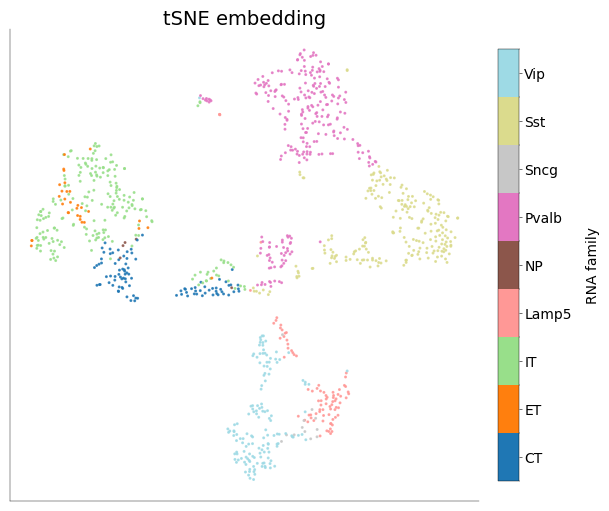


=== Embedding Rank #2 ===
norm = 'CPM'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 12, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



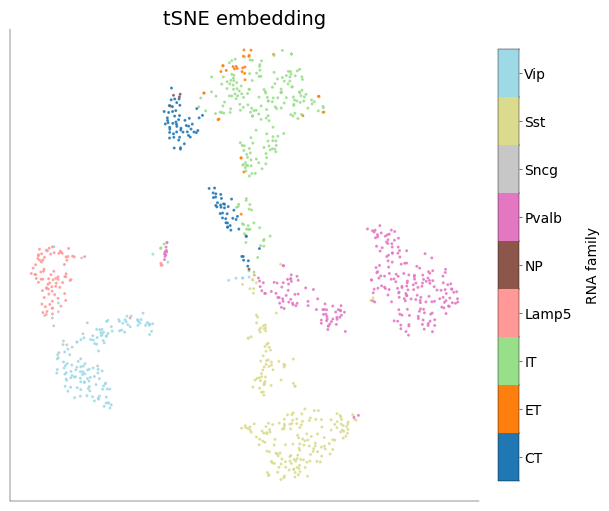


=== Embedding Rank #3 ===
norm = 'CPMedian'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 12, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



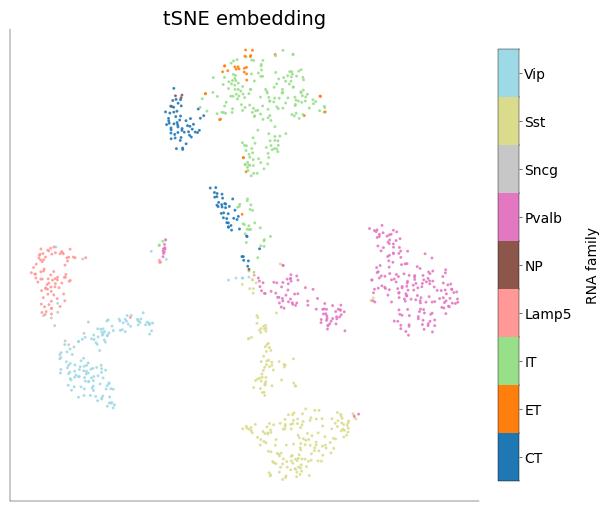


=== Embedding Rank #4 ===
norm = 'CPMedian'
transform = 'log1p'
n_hvg = 1000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 12, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



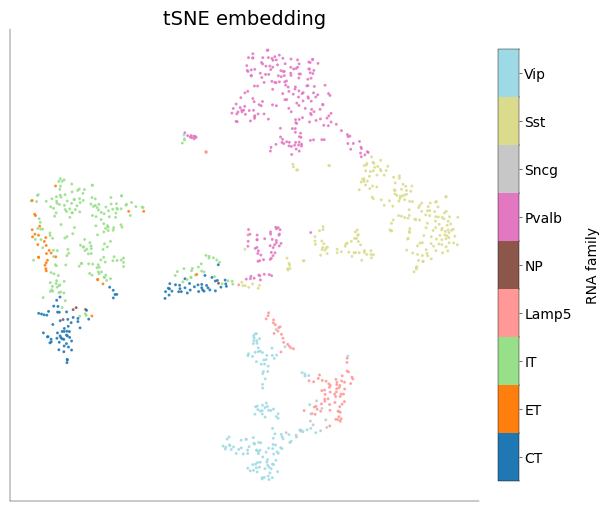


=== Embedding Rank #5 ===
norm = 'CPMedian'
transform = 'log1p'
n_hvg = 1000, n_pc = 10
method = tSNE
params = {'perplexity': 10, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



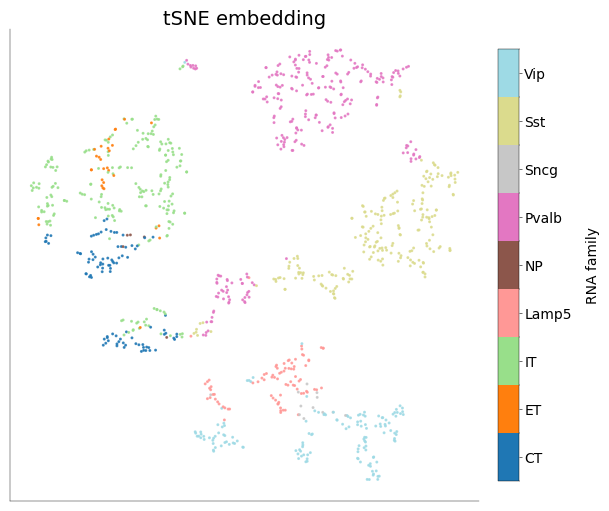


=== Embedding Rank #6 ===
norm = 'CPMedian'
transform = 'log1p'
n_hvg = 1000, n_pc = 10
method = tSNE
params = {'perplexity': 10, 'early_exaggeration': 12, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



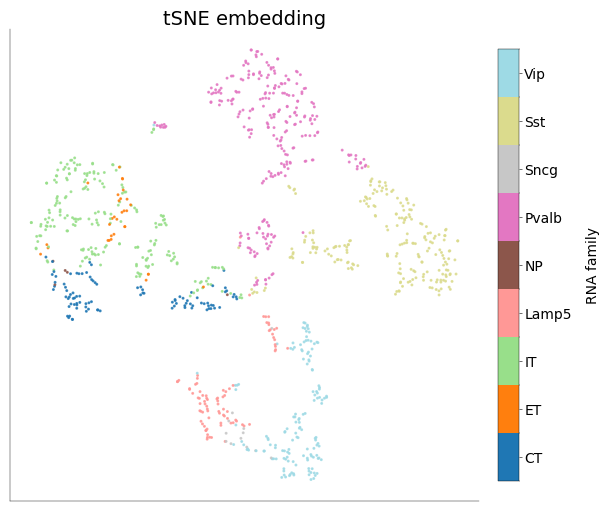


=== Embedding Rank #7 ===
norm = 'CPM'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



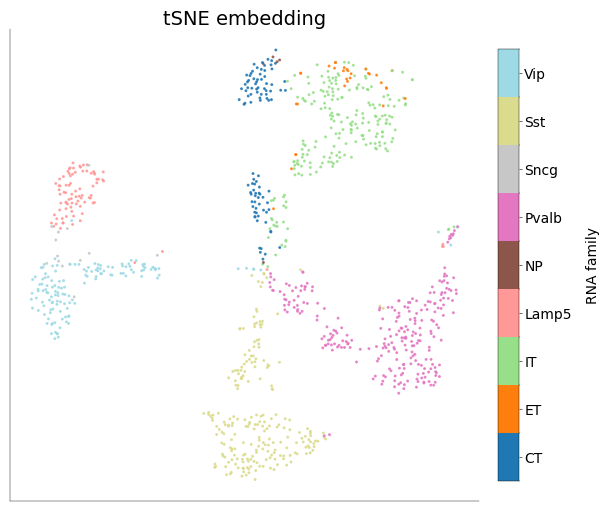


=== Embedding Rank #8 ===
norm = 'CPMedian'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 30, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



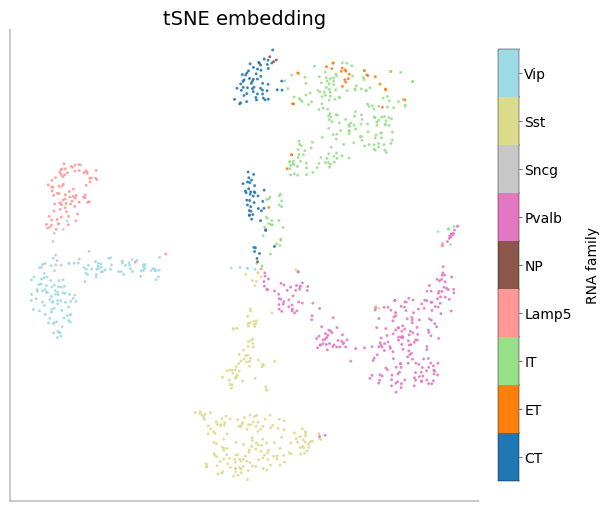


=== Embedding Rank #9 ===
norm = 'CPM'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 10, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



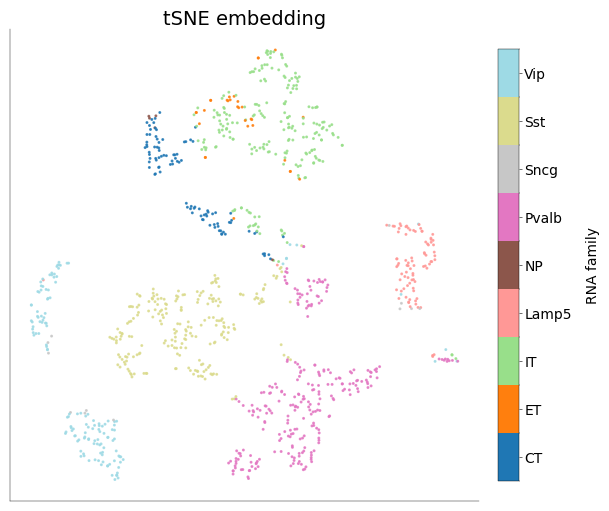


=== Embedding Rank #10 ===
norm = 'CPMedian'
transform = 'sqrt'
n_hvg = 2000, n_pc = 10
method = tSNE
params = {'perplexity': 10, 'early_exaggeration': 4, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 0}



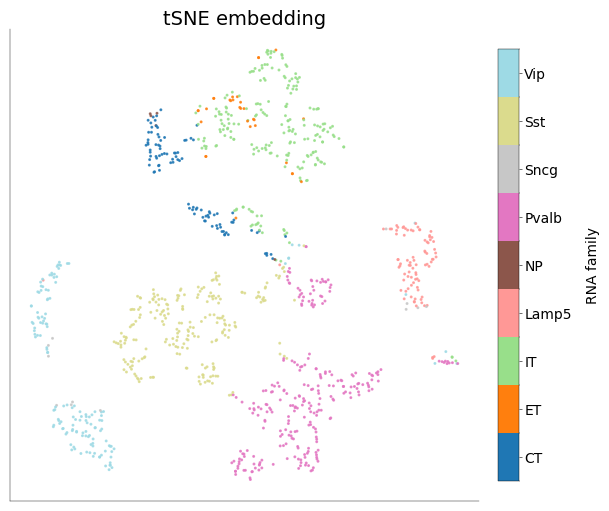

In [ ]:
# how many categories?
n_cats = len(fam_categories)

# discrete colormap + norm
cmap = plt.get_cmap("tab20", n_cats)
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(-0.5, n_cats + 0.5, 1), ncolors=n_cats
)

top_n = 10
top_df = df_embed.head(top_n)

for rank, (_, row) in enumerate(top_df.iterrows(), start=1):
    # 1) print all the info
    print(f"\n=== Embedding Rank #{rank} ===")
    print(f"norm = {row['norm']!r}")
    print(f"transform = {row['tfm']!r}")
    print(f"n_hvg = {row['n_hvg']}, n_pc = {row['n_pc']}")
    print(f"method = {row['method']}")
    print(f"params = {row['params']}\n")

    # 2) recover the high‑dim PCs and compute 2D embedding
    key = (row["norm"], row["tfm"], row["n_hvg"], row["n_pc"])
    P_hd = filtered_results[key]["pcs"]
    Y2d = embed_fns[row["method"]](P_hd, **row["params"])

    # 3) fresh figure + scatter
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(
        Y2d[:, 0],
        Y2d[:, 1],
        c=fam_labels,
        cmap=cmap,
        norm=norm,
        s=5,
        alpha=0.8,
    )
    ax.set_title(f"{row['method']} embedding", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

    # 4) discrete colorbar with family names
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # no actual data needed
    cbar = fig.colorbar(
        sm, ax=ax, ticks=np.arange(n_cats), fraction=0.046, pad=0.04
    )
    cbar.ax.set_yticklabels(fam_categories)
    cbar.set_label("RNA family", rotation=90, labelpad=10)

    plt.show()

Having completed normalization, transformation, variable‑gene selection and PCA (Task 2), we now face the challenge of **displaying** our high‑dimensional transcriptomic space in two dimensions. Traditionally, inspection of scatterplots is done by eye, looking for islands of cell types, but with dozens of preprocessing variants and embedding hyperparameters, visual inspection alone is neither scalable nor objective. We therefore automate a **quantitative search** for the best 2‑D map, using the metrics and recommendations from Lause *et al.* (2024) .

**1. Embedding methods under consideration**

* **PCA‑2D**: a linear baseline projecting directly onto the first two principal components.
* **t‑SNE**: preserves local neighborhoods via pairwise affinities; key hyperparameters include *perplexity* and *early exaggeration*.
* **UMAP**: balances local and global structure by approximating a Riemannian manifold; varied by *n\_neighbors* and *min\_dist*.

By sweeping each method over a grid of recommended hyperparameters, we generate a diverse set of candidate embeddings.

**2. Objective evaluation metrics**

**Lause *et al.* (2024)** systematically compare embeddings using metrics that capture both **neighborhood fidelity** and **cluster structure**. We adopt their core set, plus a complementary cluster‐agreement score:

1. **k‑NN accuracy**
   Fraction of each cell’s *k* nearest neighbors in 2D that share the same RNA‑family label—i.e. local label purity .
2. **k‑NN recall** (a.k.a. *continuity*)
   Fraction of a cell’s *k* neighbors in the high‑dimensional (PCA) space that remain neighbors in 2D.
3. **Silhouette coefficient**
   Measures how well cells of the same label form compact, separated clusters in the 2D layout.
4. **Trustworthiness**
   Penalizes “false” 2D neighbors that were not close in the original high‑dimensional space; computed as in Lee & Verleysen (2009) .
5. **Adjusted Mutual Information (AMI)**
   Agreement between an *unsupervised* clustering of the 2D map (e.g. HDBSCAN) and the RNA‑family labels.

By combining **label‑dependent** (1, 3, 5) and **label‑independent** (2, 4) criteria, we guard against “over‑fitting” to potentially noisy annotations while still rewarding clear, biologically meaningful separations.

**3. Workflow outline**

1. **Reference space freeze**
   Choose one normalized & transformed gene set (e.g. top 2000 HVGs, 50 PCs) and compute its *k*‑NN graph once.
2. **Grid generation**
   For each embedding method, iterate over its hyperparameter grid to produce 2D coordinates.
3. **Metric computation**
   For every 2D map, compute the five metrics above, using the frozen high‑dimensional graph for continuity/trustworthiness.
4. **Aggregate & rank**
   Either rank each embedding on each metric and compute a mean rank, or normalize metrics to \[0, 1] and form a weighted sum.
5. **Select winner**
   The top‑ranked embedding provides an objective choice for visualization, reproducing Lause *et al.*’s finding that properly‑tuned t‑SNE/UMAP often dramatically outperform PCA‑2D in local purity and cluster separation .


By following this **principled, metric‑driven** pipeline, we obtain a reproducible, defensible choice of 2D projection.


In [27]:
def get_top_unique_datasets(df_embed, top_n):
    top = df_embed.head(top_n)
    seen = set()
    unique = []
    for _, row in top.iterrows():
        ds = (row["norm"], row["tfm"], row["n_hvg"], row["n_pc"])
        if ds not in seen:
            seen.add(ds)
            unique.append(ds)
    print(f"From top {top_n} embeddings → {len(unique)} unique datasets")
    for ds in unique:
        print(f"  • {ds}")
    return unique


def fetch_dataset_matrices(df_embed, transformed_data, results, top_n=10):
    """
    Returns a dict:
      { (norm,tfm,n_hvg,n_pc): { 'X_tfm':…, 'P_hd':… }, … }
    for the first top_n ranked embeddings (deduped by dataset).
    """
    unique_ds = get_top_unique_datasets(df_embed, top_n)
    ds_data = {}
    for ds in unique_ds:
        norm, tfm, n_hvg, n_pc = ds

        # your normalized+transformed counts
        X_tfm = transformed_data[(norm, tfm)]

        # the PCA‐scores (n_cells × n_pc)
        P_hd = results[(norm, tfm, n_hvg, n_pc)]["pcs"]

        ds_data[ds] = {"X_tfm": X_tfm, "P_hd": P_hd}
    return ds_data


unique_ds_data = fetch_dataset_matrices(
    df_embed, transformed_data, filtered_results, top_n=20
)

NameError: name 'df_embed' is not defined

In [35]:
# RUN THIS
dataset_lst = [
    ("CPMedian", "log1p", 1000, 10),
    ("CPM", "sqrt", 2000, 10),
    ("CPMedian", "sqrt", 2000, 10),
]

unique_ds_data = {}

for ds in dataset_lst:
    norm, tfm, n_hvg, n_pc = ds

    # your normalized+transformed counts
    projected_data = transformed_data[(norm, tfm)]

    # the PCA‐scores (n_cells × n_pc)
    P_hd = filtered_results[(norm, tfm, n_hvg, n_pc)]["pcs"]

    unique_ds_data[ds] = {"X_tfm": projected_data, "P_hd": P_hd}

In [ ]:
with open(variables_path / "unique_ds_data.pkl", "wb") as f:
    pickle.dump(unique_ds_data, f)

---
## 4 - Clustering
To find cell types in the RNA count data, you will need to look for clusters. Try different clustering methods (leiden, GMM). Implement a negative binomial mixture model. For that you can follow a similar method that what is described in Harris et al. 2018 (https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.2006387#abstract0), with fixed r (r=2). Feel free to simplify the setup from the paper and not optimize over the set of important genes S but fix it instead, or skip the split and merge part of their clustering algorithm. A vanilla NBMM implementation should suffice. Take into account that the NBMM tries to cluster data that follows a negative binomial distribution. Therefore, it does not make sense to apply this clustering method to all kinds of normalized and transformed data. Please refer to the Harris et al. 2018 publication for the appropriate choice of normalization, and reflect on why this normalization makes sense. Evaluate your clustering results (metrics, compare number of clusters to original labels,...).

To infer transcriptionally distinct cell types from RNA-seq data, we applied and compared multiple clustering algorithms — Leiden, GMM, and Negative Binomial Mixture Models (NBMM). Each algorithm was evaluated on its ability to recover ground-truth RNA families and RNA types. Our overarching goal was to identify the most biologically meaningful clustering solution to use in downstream analysis of electrophysiological features.

#### 4.0 Setup

In [122]:
# Use the best data transformations from the previous analysis
cur_data = unique_ds_data[dataset_lst[0]]

embedding_params = {
    "perplexity": 30,
    "early_exaggeration": 4,
    "learning_rate": "auto",
    "init": "pca",
    "random_state": 0,
}

# Compute t-SNE embedding using the specified parameters
embedding_data = TSNE(n_components=2, **embedding_params).fit_transform(
    cur_data["P_hd"]
)

n_clusters_family = len(pd.Series(meta_qc["RNA family"]).unique())
n_clusters_type = len(pd.Series(meta_qc["RNA type"]).unique())

# Create an AnnData object to store all clustering results and metadata
adata = AnnData(cur_data["P_hd"])
adata.obsm["X_tSNE"] = embedding_data
adata.obs["rna_family"] = meta_qc["RNA family"].reset_index(drop=True).values
adata.obs["rna_type"] = meta_qc["RNA type"].reset_index(drop=True).values

print("Number of cells:", adata.shape[0])
print("Number of PCA features:", adata.shape[1])
print("Number of RNA families:", n_clusters_family)
print("Number of RNA types:", n_clusters_type)

Number of cells: 1084
Number of PCA features: 10
Number of RNA families: 9
Number of RNA types: 75


We initialize the clustering pipeline using the best preprocessing configuration selected from prior analysis:

* **Normalization**: Counts per million (CPM) followed by cell-wise median scaling (`CPMedian`)
* **Transformation**: Log1p transformation (`log(1 + x)`)
* **Feature Selection**: Top 1000 highly variable genes (HVGs)
* **Dimensionality Reduction**: First 10 principal components (PCs) from PCA

 These 10-dimensional PCA-reduced features (`P_hd`) are used as the input space for clustering in algorithms such as Leiden and GMM.

We compute a 2D t-SNE embedding from the 10D PCA features (`P_hd`). These embeddings are used for consistent visualization across clustering methods.

We observe 75 RNA types, as opposed to 77, after quality-control.


#### 4.1 Clustering Metrics & Visualisation Procedure

In [146]:
def average_hex_colors(hex_colors):
    """Average a list of hex colors and return as hex."""
    rgb = np.array([mcolors.to_rgb(c) for c in hex_colors])
    avg_rgb = rgb.mean(axis=0)
    return mcolors.to_hex(avg_rgb)


def build_family_palette(rna_type_color_dict, rna_families):
    """
    Derive RNA family color palette by averaging colors of RNA types
    that mention the family name (via regex substring match).

    Parameters
    ----------
    rna_type_color_dict : dict
        Mapping from RNA type (str) to hex color (str)
    rna_families : list or array
        List of known RNA family names (str)

    Returns
    -------
    rna_family_color_dict : dict
        Mapping from RNA family (str) to averaged hex color
    """
    # Store matches
    family_to_colors = defaultdict(list)

    for rna_type, hex_color in rna_type_color_dict.items():
        for fam in rna_families:
            pattern = rf"(?<![a-zA-Z0-9]){re.escape(fam)}(?![a-zA-Z0-9])"
            if re.search(pattern, rna_type):
                family_to_colors[fam].append(hex_color)
                break  # Only assign to the first matching family

    # Average colors for each family with matches
    rna_family_color_dict = {
        fam: average_hex_colors(colors)
        for fam, colors in family_to_colors.items()
        if len(colors) > 0
    }

    return rna_family_color_dict


# Build the RNA family color palette using the RNA type colors
dict_rna_family_colors = build_family_palette(
    dict_rna_type_colors, list(rna_family.unique())
)

In [147]:
def hungarian_clustering_accuracy(
    y_true: np.ndarray, y_pred: np.ndarray
) -> Tuple[float, dict]:
    """
    Compute clustering accuracy after optimal label permutation using the Hungarian algorithm.
    Handles string and numeric labels, and pandas Series.

    Parameters
    ----------
    y_true : array-like or pd.Series, shape (n_samples,)
        Ground truth labels (can be strings or numbers).
    y_pred : array-like or pd.Series, shape (n_samples,)
        Predicted cluster labels (can be strings or numbers).

    Returns
    -------
    acc : float
        Clustering accuracy ∈ [0, 1].
    mapping : dict
        Mapping from original predicted labels to original true labels.
    """
    # Convert to NumPy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Encode labels to integers
    le_true = LabelEncoder()
    le_pred = LabelEncoder()
    y_true_encoded = le_true.fit_transform(y_true)
    y_pred_encoded = le_pred.fit_transform(y_pred)

    # Confusion matrix
    cm = confusion_matrix(y_true_encoded, y_pred_encoded)

    # Solve assignment (maximize total matches)
    row_ind, col_ind = linear_sum_assignment(-cm)
    acc = cm[row_ind, col_ind].sum() / cm.sum()

    # Map encoded predicted labels → encoded true labels
    mapping_encoded = dict(zip(col_ind, row_ind))

    # Map back to original labels
    mapping = {
        le_pred.inverse_transform([k])[0]: le_true.inverse_transform([v])[0]
        for k, v in mapping_encoded.items()
    }

    return acc, mapping


# Define a reusable function for metric computations
def compute_clustering_metrics(
    cluster_assignments: pd.Series, ground_truth: pd.Series
) -> dict:
    """
    Compute clustering evaluation metrics against ground truth.

    Parameters
    ----------
        cluster_assignments (pd.Series): Cluster assignments for each data point.
        ground_truth (pd.Series): Ground truth labels for each data point.

    Returns
    -------
        dict: Dictionary containing ARI, AMI, Accuracy, Homogeneity and optimal mapping.
    """
    ari = adjusted_rand_score(ground_truth, cluster_assignments)
    ami = adjusted_mutual_info_score(ground_truth, cluster_assignments)
    homog_score = homogeneity_score(ground_truth, cluster_assignments)

    # Only compute accuracy if the number of clusters matches
    if len(np.unique(ground_truth)) == len(np.unique(cluster_assignments)):
        acc, mapping = hungarian_clustering_accuracy(
            ground_truth, cluster_assignments
        )
    else:
        acc, mapping = None, None

    return {
        "ARI": ari,
        "AMI": ami,
        "Accuracy": acc,
        "Homogeneity": homog_score,
        "Map": mapping,  # optimal mapping from predicted to true labels
    }

To evaluate clustering results in a biologically meaningful way, we use a series of techniques that map predicted cluster labels to ground-truth annotations (RNA types and RNA families), compute a variety of clustering quality metrics, and visualize cluster structure using consistent color palettes.

##### 4.1.1 RNA Family Color Palette Construction

Since we have predefined colors for RNA types, we derive a consistent and interpretable color palette for RNA **families** by averaging the colors of RNA types that **mention the family name** in their label. This provides a consistent visual language across all cluster plots, where RNA types and families are colored in a way that preserves their biological relationships.

##### 4.1.2 Label Alignment with the Hungarian Algorithm

Clustering algorithms output labels as arbitrary integers, which do not correspond directly to biologically meaningful labels. To evaluate clustering performance against ground-truth annotations, we compute the **optimal one-to-one mapping between predicted and true labels** using the [Hungarian algorithm](https://en.wikipedia.org/wiki/Hungarian_algorithm) (also known as the Munkres algorithm) for solving the assignment problem. This algorithm maximizes the total agreement between the predicted and true labels by solving a linear sum assignment problem on the confusion matrix.

This mapping is also used to recolor clustering results to match ground-truth colors, enabling fair visual comparisons across methods.

##### 4.1.3. Clustering Evaluation Metrics

We compute four standard clustering metrics to quantify performance:

| **Metric**                            | **Definition**                                                                                | **Range** | **Interpretation**                                                                          |
| ------------------------------------- | --------------------------------------------------------------------------------------------- | --------- | ------------------------------------------------------------------------------------------- |
| **ARI** (Adjusted Rand Index)         | Measures agreement between predicted and true labels, adjusted for chance.                    | \[-1, 1]  | 1 indicates perfect match, 0 random labeling, negative values indicate anti-agreement.      |
| **AMI** (Adjusted Mutual Information) | Normalized measure of mutual information between labelings, adjusted for chance.              | \[0, 1]   | 1 means perfect agreement, 0 implies no mutual information beyond chance.                   |
| **Accuracy**                          | Proportion of correctly matched labels after optimal Hungarian mapping.                       | \[0, 1]   | 1 is perfect label match. Only computed if number of predicted and true clusters are equal. |
| **Homogeneity**                       | Measures whether each predicted cluster contains only members of a single ground-truth class. | \[0, 1]   | 1 means each cluster is pure, 0 means clusters mix labels.                                  |

These metrics capture complementary aspects of clustering quality: ARI and AMI measure label alignment (with correction for chance), Accuracy reflects total match after remapping, and Homogeneity emphasizes the internal purity of predicted clusters.

##### 4.1.4 Plotting Functions

In [193]:
def plot_family_accuracy(
    ax: plt.Axes,
    y_true: pd.Series,
    y_pred: pd.Series,
    mapping: dict = None,
    title="Accuracy per RNA Family",
):
    """
    Plot accuracy per RNA family as a barplot.

    Parameters:
    ----------
        y_true (pd.Series): Ground truth RNA family labels.
        y_pred (pd.Series): Predicted cluster assignments (as integers or strings).
        mapping (dict): Optional mapping from predicted cluster labels to true family labels (e.g. from Hungarian matching).
        title (str): Title of the plot.
    """
    # Align indices
    y_true = y_true.reset_index(drop=True)
    y_pred = y_pred.reset_index(drop=True)

    # Map predicted labels if a mapping is provided
    if mapping is not None:
        y_pred_mapped = y_pred.map(mapping)
    else:
        y_pred_mapped = y_pred.copy()

    # Compute per-family accuracy
    families = y_true.unique()
    accuracies = []

    for fam in sorted(families):
        mask = y_true == fam
        n_total = mask.sum()
        n_correct = (y_pred_mapped[mask] == y_true[mask]).sum()
        acc = n_correct / n_total
        accuracies.append((fam, acc))

    # Create DataFrame for plotting
    acc_df = pd.DataFrame(
        accuracies, columns=["RNA Family", "Accuracy"]
    ).sort_values("Accuracy", ascending=False)

    # Plot
    ax.tick_params(axis="x", labelrotation=45)
    sns.barplot(data=acc_df, x="RNA Family", y="Accuracy", ax=ax)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("RNA Family")


def plot_normalized_confusion(
    ax: plt.Axes,
    true_labels: pd.Series,
    pred_labels: pd.Series,
    title: str = "",
):
    """
    Plot a normalized confusion matrix as a heatmap.
    Parameters:
    ----------
        ax (plt.Axes): Matplotlib Axes object to plot on.
        true_labels (pd.Series): Ground truth labels.
        pred_labels (pd.Series): Predicted labels.
        title (str): Title of the plot.
    """

    cm = confusion_matrix(true_labels, pred_labels, normalize="true")
    df_cm = pd.DataFrame(
        cm, index=np.unique(true_labels), columns=np.unique(pred_labels)
    )
    ax.tick_params(axis="x", labelrotation=45)
    sns.heatmap(df_cm, annot=True, fmt=".2f", cmap="viridis", ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")


def plot_clusters_and_compute_metrics(
    vis_embedding: np.ndarray,
    fam_labels: pd.Series,
    type_labels: pd.Series,
    fam_algo_name: str,
    type_algo_name: str,
) -> Tuple[dict, dict]:
    """
    Visualize clustering results and print metrics for RNA family and type.
    Parameters:
        vis_embedding (np.ndarray): 2D embedding of the data points.
        fam_labels (pd.Series): Cluster labels for RNA family.
        type_labels (pd.Series): Cluster labels for RNA type.
        fam_algo_name (str): Name of the algorithm used for RNA family clustering.
        type_algo_name (str): Name of the algorithm used for RNA type clustering.
    Returns:
        fam_metrics (dict): Clustering metrics for RNA family.
        type_metrics (dict): Clustering metrics for RNA type.
    """

    gt_rna_family = meta_qc["RNA family"].reset_index(drop=True).values
    gt_rna_type = meta_qc["RNA type"].reset_index(drop=True).values

    fam_metrics = compute_clustering_metrics(fam_labels, gt_rna_family)
    type_metrics = compute_clustering_metrics(type_labels, gt_rna_type)

    pred_fam_labels = (
        fam_labels.map(fam_metrics["Map"])
        if fam_metrics["Map"]
        else fam_labels
    )
    pred_type_labels = (
        type_labels.map(type_metrics["Map"])
        if type_metrics["Map"]
        else type_labels
    )

    # Visualize clustering results
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # clustering visualization for RNA family clusters
    sns.scatterplot(
        ax=axes[0, 0],
        x=vis_embedding[:, 0],
        y=vis_embedding[:, 1],
        hue=pred_fam_labels,
        palette=dict_rna_family_colors if fam_metrics["Map"] else "husl",
        # legend="full",
        legend=None,
    )
    axes[0, 0].set_title(f"{fam_algo_name} Clustering (RNA Family)")
    axes[0, 0].set_xlabel("tSNE 1")
    axes[0, 0].set_ylabel("tSNE 2")

    # Ground truth clustering visualization for RNA family
    sns.scatterplot(
        ax=axes[0, 1],
        x=vis_embedding[:, 0],
        y=vis_embedding[:, 1],
        hue=gt_rna_family,
        palette=dict_rna_family_colors if fam_metrics["Map"] else "husl",
        legend="full",
    )
    axes[0, 1].set_title("Ground Truth Clustering (RNA Family)")
    axes[0, 1].set_xlabel("tSNE 1")
    axes[0, 1].set_ylabel("tSNE 2")
    axes[0, 1].legend(
        title="RNA Family",
        bbox_to_anchor=(1.05, 0.5),
        loc="center left",
        borderaxespad=0.0,
    )

    # clustering visualization for RNA type clusters
    sns.scatterplot(
        ax=axes[1, 0],
        x=vis_embedding[:, 0],
        y=vis_embedding[:, 1],
        hue=pred_type_labels,
        palette=dict_rna_type_colors if type_metrics["Map"] else "husl",
        legend=None,
    )
    axes[1, 0].set_title(f"{type_algo_name} Clustering (RNA Type)")
    axes[1, 0].set_xlabel("tSNE 1")
    axes[1, 0].set_ylabel("tSNE 2")

    # Ground truth clustering visualization for RNA type
    sns.scatterplot(
        ax=axes[1, 1],
        x=vis_embedding[:, 0],
        y=vis_embedding[:, 1],
        hue=gt_rna_type,
        palette=dict_rna_type_colors if type_metrics["Map"] else "husl",
        legend=None,
    )
    axes[1, 1].set_title("Ground Truth Clustering (RNA Type)")
    axes[1, 1].set_xlabel("tSNE 1")
    axes[1, 1].set_ylabel("tSNE 2")

    fig.suptitle(f"{fam_algo_name} Clustering Results", fontsize=14)
    plt.show()

    print(f"Metrics for {fam_algo_name} family clustering:")
    print(
        f"  Homogeneity: {fam_metrics['Homogeneity']:.3f}\n  ARI: {fam_metrics['ARI']:.3f}\n  AMI: {fam_metrics['AMI']:.3f}\n  Accuracy: {fam_metrics['Accuracy']:.3f}"
    )
    print(f"Metrics for {type_algo_name} type clustering:")
    print(
        f"  Homogeneity: {type_metrics['Homogeneity']:.3f}\n  ARI: {type_metrics['ARI']:.3f}\n  AMI: {type_metrics['AMI']:.3f}\n  Accuracy: {type_metrics['Accuracy']:.3f}"
    )

    return fam_metrics, type_metrics

#### 4.2 Leiden Clustering

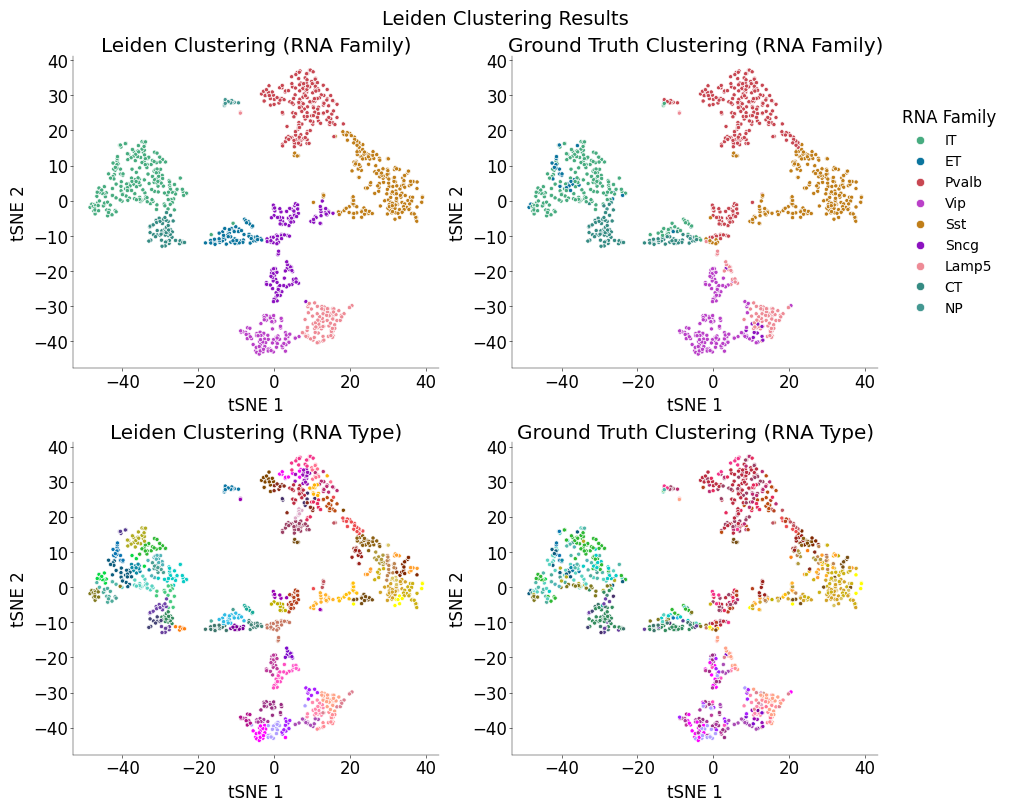

Metrics for Leiden family clustering:
  Homogeneity: 0.749
  ARI: 0.650
  AMI: 0.715
  Accuracy: 0.732
Metrics for Leiden type clustering:
  Homogeneity: 0.624
  ARI: 0.156
  AMI: 0.382
  Accuracy: 0.273


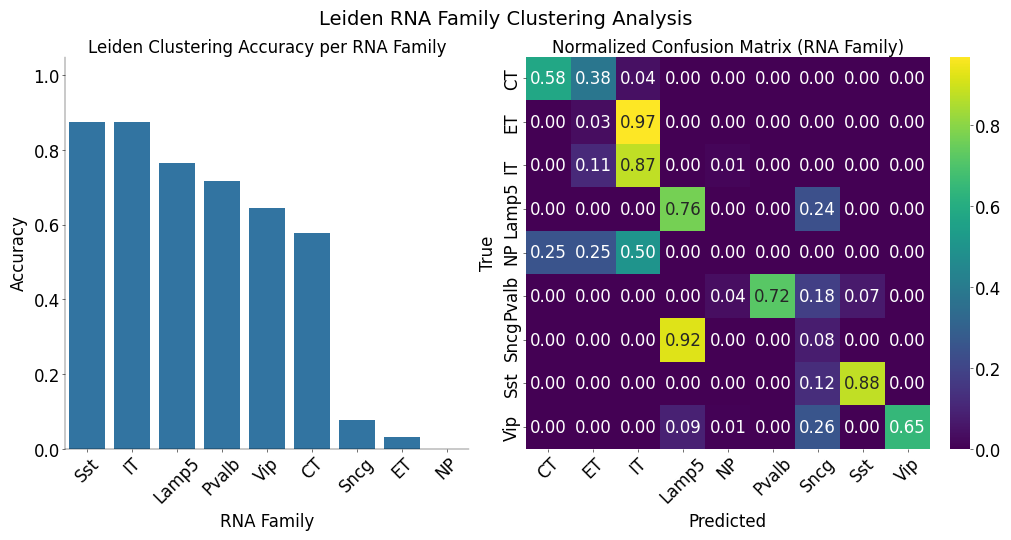

In [198]:
# Set resolution dynamically based on RNA family and type
# This ensures that Leiden clustering finds the same number of clusters
# as the unique RNA families and types, for better comparability.
resolution_family = 0.4
resolution_type = 12

# Compute neighbors and perform Leiden clustering
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X")

# Perform Leiden clustering for RNA family
sc.tl.leiden(
    adata,
    resolution=0.4,
    flavor="igraph",
    n_iterations=-1,
    directed=False,
)
adata.obs["leiden_family"] = adata.obs["leiden"]

# Perform Leiden clustering for RNA type
sc.tl.leiden(
    adata,
    resolution=12,
    flavor="igraph",
    n_iterations=-1,
    directed=False,
)
adata.obs["leiden_type"] = adata.obs["leiden"]

assert len(adata.obs["leiden_family"].unique()) == len(
    adata.obs["rna_family"].unique()
)
assert len(
    adata.obs["leiden_type"].unique() == len(adata.obs["rna_type"].unique())
)

leiden_fam_metrics, leiden_type_metrrics = plot_clusters_and_compute_metrics(
    adata.obsm["X_tSNE"],
    adata.obs["leiden_family"],
    adata.obs["leiden_type"],
    fam_algo_name="Leiden",
    type_algo_name="Leiden",
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_family_accuracy(
    axes[0],
    adata.obs["rna_family"],
    adata.obs["leiden_family"],
    mapping=leiden_fam_metrics["Map"],
    title="Leiden Clustering Accuracy per RNA Family",
)

plot_normalized_confusion(
    axes[1],
    adata.obs["rna_family"],
    adata.obs["leiden_family"].map(leiden_fam_metrics["Map"]),
    title="Normalized Confusion Matrix (RNA Family)",
)
plt.suptitle("Leiden RNA Family Clustering Analysis", fontsize=14, y=1.05)
plt.show()

The **Leiden algorithm** is a widely used method for community detection on graphs that improves cluster connectivity and stability compared to Louvain [Traag et al., 2019](https://www.nature.com/articles/s41598-019-41695-z). To apply this to RNA-seq data, we constructed a k-nearest neighbor graph using the 10-dimensional PCA-reduced representation of log₁p-transformed CPMedian-normalized exon counts (based on 1000 HVGs), and performed Leiden clustering using `scanpy`.

To ensure a fair comparison with ground truth annotations, we manually tuned the resolution parameter to yield:

* **9 clusters for RNA families** (`resolution = 0.4`)
* **75 clusters for RNA types** (`resolution = 12`)

This allowed for direct computation of accuracy and other evaluation metrics.

##### Analysis of Leiden Family Clustering Output

*Accuracy per Family (left panel):*

* Families **Sst**, **IT**, and **Lamp5** are clustered with high accuracy (>75%).
* Families like **Sncg**, **ET**, and **NP** perform poorly, especially **NP** which has <5% accuracy.
* The mid-tier accuracy families (**Pvalb**, **Vip**, **CT**) show substantial overlap with other types, indicating possible ambiguity or resolution-induced merging.

*Confusion Matrix (right panel):*


* **IT**, **Sst**, **Lamp5**, and **Pvalb** each show strong diagonal values (\~0.8), indicating confident and accurate clustering.
* **ET** is almost completely misclassified as IT
* **NP** is heavily split between CT, ET, and IT predictions, suggesting the Leiden algorithm failed to form a coherent NP cluster.
* Some off-diagonal leakage exists (e.g., Pvalb into Lamp5), likely due to biological similarity or resolution granularity.


In summary, **Leiden clustering performs moderately for RNA families**, especially those with clear separability in expression space. However, the clustering struggles with rarer or less distinct families like NP and ET, and fails to recover the RNA type structure, indicating that **Leiden is suboptimal for fine-grained subtype clustering** in this context.


#### 4.3 GMM Clustering

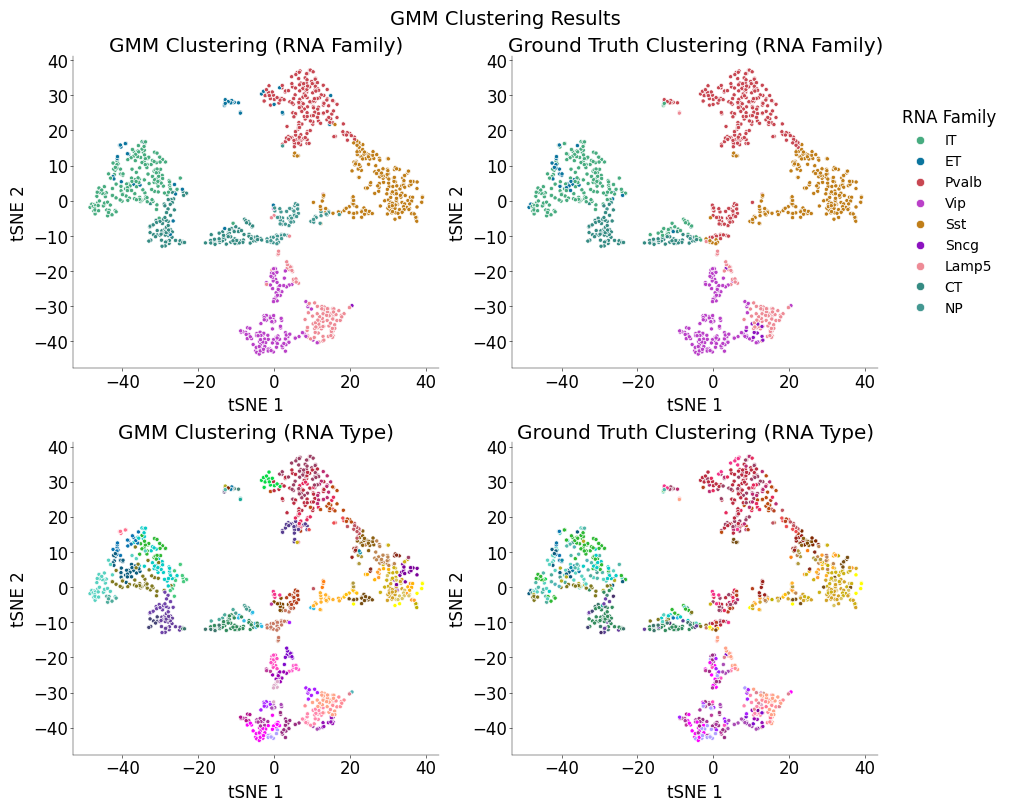

Metrics for GMM family clustering:
  Homogeneity: 0.787
  ARI: 0.716
  AMI: 0.756
  Accuracy: 0.809
Metrics for GMM type clustering:
  Homogeneity: 0.613
  ARI: 0.184
  AMI: 0.409
  Accuracy: 0.284


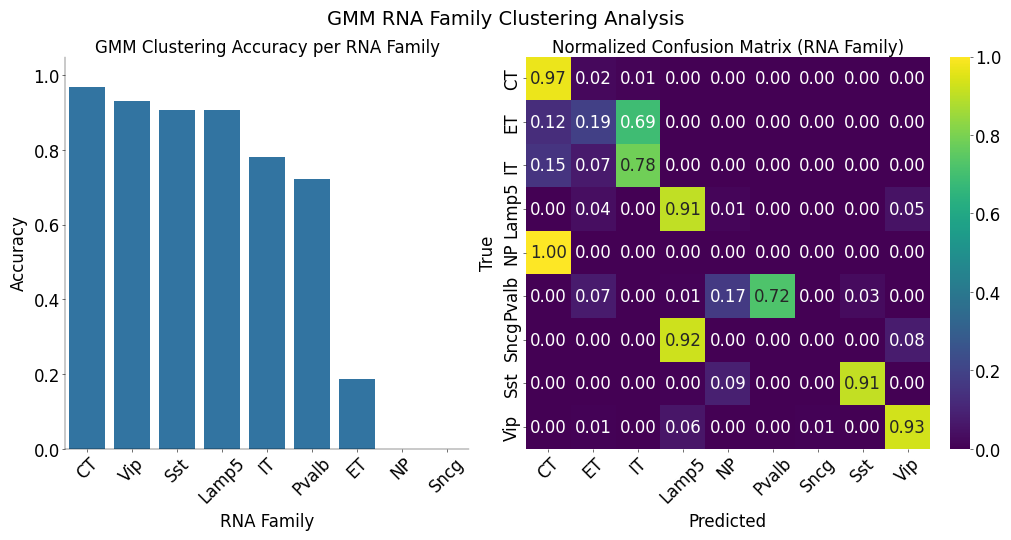

In [199]:
# Perform GMM clustering for RNA family clusters
n_components_family = len(adata.obs["rna_family"].unique())
gmm_family = GaussianMixture(n_components=n_components_family, random_state=42)
gmm_family_labels = gmm_family.fit_predict(cur_data["P_hd"])

# Add GMM family labels to AnnData object
adata.obs["gmm_family"] = gmm_family_labels

# Perform GMM clustering for RNA type clusters
n_components_type = len(adata.obs["rna_type"].unique())
gmm_type = GaussianMixture(n_components=n_components_type, random_state=42)
gmm_type_labels = gmm_type.fit_predict(cur_data["P_hd"])

# Add GMM type labels to AnnData object
adata.obs["gmm_type"] = gmm_type_labels

gmm_fam_metrics, gmm_type_metrics = plot_clusters_and_compute_metrics(
    adata.obsm["X_tSNE"],
    adata.obs["gmm_family"],
    adata.obs["gmm_type"],
    fam_algo_name="GMM",
    type_algo_name="GMM",
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_family_accuracy(
    axes[0],
    adata.obs["rna_family"],
    adata.obs["gmm_family"],
    mapping=gmm_fam_metrics["Map"],
    title="GMM Clustering Accuracy per RNA Family",
)

plot_normalized_confusion(
    axes[1],
    adata.obs["rna_family"],
    adata.obs["gmm_family"].map(gmm_fam_metrics["Map"]),
    title="Normalized Confusion Matrix (RNA Family)",
)
plt.suptitle("GMM RNA Family Clustering Analysis", fontsize=14, y=1.05)
plt.show()

The **Gaussian Mixture Model (GMM)** is a generative, model-based clustering method that assumes the data arise from a weighted mixture of multivariate Gaussian distributions. Each cluster is modeled as a Gaussian component, and the algorithm jointly estimates the means, covariances, and mixing proportions via the **Expectation-Maximization (EM)** procedure.

GMM imposes several assumptions:

* **Elliptical cluster geometry:** Each component corresponds to a Gaussian-shaped cluster in the feature space.
* **Unimodality and continuity:** Each cluster has a single mode and follows a smooth probability density.
* **Euclidean embedding:** Gaussian models work best when features are linearly separable and approximately uncorrelated.

These assumptions are well-aligned with the **broad-scale, global expression differences** seen between RNA families, making GMM particularly suited for family-level clustering.

We applied GMM clustering to the **PCA-transformed space** of exon count data that had been:

* **CPMedian normalized** to mitigate sequencing depth and library size effects,
* **log1p transformed** to reduce skewness and stabilize variance,
* followed by **selection of 1000 HVGs** and projection onto the **top 10 principal components**.

This preprocessing pipeline enhances GMM performance by:

* Removing noise and irrelevant variance,
* Emphasizing dominant expression axes (e.g. family-level separability),
* Producing a decorrelated, low-dimensional embedding where Gaussian components are more valid.


##### 4.3.1 Analysis of GMM Family Clustering Output

*Accuracy per RNA Family:*

* **CT**, **Vip**, **Sst**, and **Lamp5** all exceed 90% accuracy.
* **IT** and **Pvalb** are moderately well recovered.
* **ET** is less well separated, while **NP**, and **Sncg** is not detected at all.

*Normalized Confusion Matrix:*
* Strong diagonal dominance indicates successful mapping between predicted and true families.
* **NP** is  entirely misclassified as **CT**, suggesting strong similarity or poor separation in PCA space.
* Off-diagonal confusion is observed between **ET** and **IT**, likely reflecting biological or transcriptomic continuity.


##### 4.3.2 Optimal Clusters via BIC

To estimate the optimal number of clusters **without using ground truth**, we performed a **Bayesian Information Criterion (BIC)** sweep for GMMs over $k = 2$ to $k = 100$ components:

The **Bayesian Information Criterion** is defined as:

$$
\text{BIC} = -2 \cdot \log \hat{L} + k_{\text{params}} \cdot \log N
$$

where:

* $\log \hat{L}$ is the log-likelihood of the model at the maximum likelihood estimate (MLE),
* $k_{\text{params}}$ is the number of free parameters in the model,
* $N$ is the number of data points (cells).

BIC is an **asymptotic approximation to the negative log of the marginal likelihood** (also known as the **Bayesian model evidence**):

$$
\log P(\mathcal{D} \mid \mathcal{M}) = \log \int P(\mathcal{D} \mid \theta, \mathcal{M}) P(\theta \mid \mathcal{M}) \, d\theta
$$

Under Laplace approximation and large $N$, this marginal likelihood becomes approximately:

$$
\log P(\mathcal{D} \mid \mathcal{M}) \approx \log \hat{L} - \frac{k_{\text{params}}}{2} \log N
$$

Rearranging this, we see that:

$$
\text{BIC} \approx -2 \cdot \log P(\mathcal{D} \mid \mathcal{M}) + \text{const.}
$$

Thus, **minimizing BIC** is approximately **maximizing the (log) model evidence**.

Fitting GMMs: 100%|██████████| 98/98 [01:04<00:00,  1.51it/s]


Minimum BIC: 46505.83 at k=6


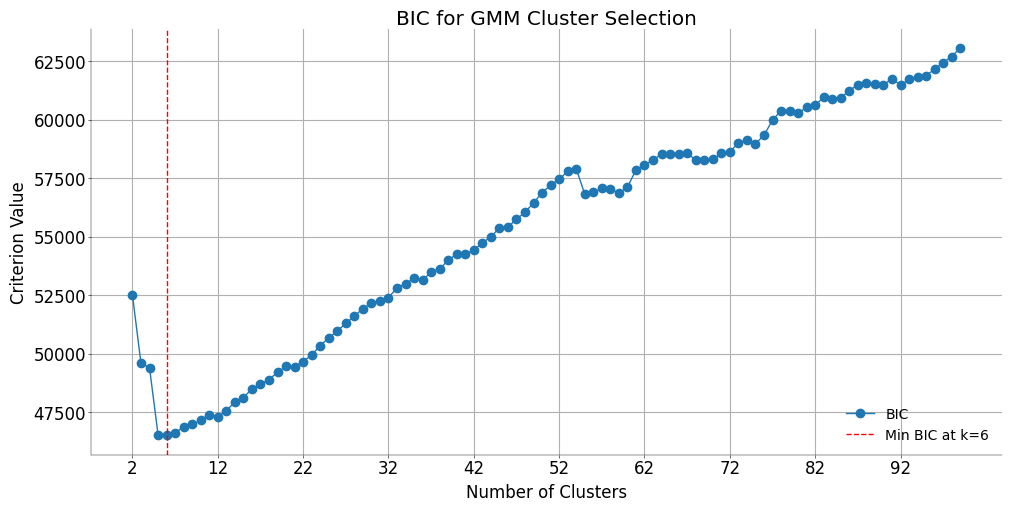

In [211]:
X = cur_data["P_hd"]

# Range of clusters to evaluate
bic_scores = []
ks = range(2, 100)

for k in tqdm(ks, desc="Fitting GMMs"):
    gmm = GaussianMixture(
        n_components=k, random_state=42, covariance_type="full"
    )
    gmm.fit(X)
    bic_scores.append(gmm.bic(X))

# Plot BIC and AIC curves
min_bic = min(bic_scores)
min_bic_k = ks[bic_scores.index(min_bic)]
print(f"Minimum BIC: {min_bic:.2f} at k={min_bic_k}")
plt.figure(figsize=(10, 5))
plt.plot(ks, bic_scores, label="BIC", marker="o")
# plot the minimum BIC point
plt.axvline(
    min_bic_k, color="red", linestyle="--", label=f"Min BIC at k={min_bic_k}"
)
plt.xticks(list(ks)[::10])  # Show every 10th tick
plt.xlabel("Number of Clusters")
plt.ylabel("Criterion Value")
plt.title("BIC for GMM Cluster Selection")
plt.legend()
plt.grid(True)
plt.show()

We find that the **minimum BIC was obtained at $k = 6$**—a value **close to the 9 RNA families** in the ground truth. This implies:

* Under the GMM generative model assumption, the **model with 6 clusters best explains the observed data**, in the sense of having the highest (approximated) **Bayesian model evidence**.
* Even **without labels**, the GMM naturally discovers a clustering structure that **coincides with biological families**.
* Since BIC is a principled criterion rooted in **Bayesian model selection**, this lends **inductive support** to the idea that **RNA family structure is encoded in the geometry of the PCA space**, and **well captured by GMM assumptions**.

Thus, this result justifies the use of GMMs as a valid and effective unsupervised method for capturing RNA family structure.

##### 4.3.3 Conclusion

GMM clustering demonstrates **convincing performance in recovering most RNA families**, especially for those with distinct global transcriptomic profiles. The use of PCA-transformed input helps align the data with GMM's Gaussian assumptions, resulting in high interpretability and strong alignment with known family structure.

While performance for RNA types is still lower, but better than Leiden, this is expected given GMM’s limitations in modeling overdispersed, non-Gaussian count structures typical of fine-grained cell subtypes.

#### 4.4 NBMM Clustering


To cluster cells based on RNA expression using a **Negative Binomial Mixture Model (NBMM)**, we begin by appropriately normalizing the **raw exon counts**. Unlike Gaussian-based models that assume fixed variance across features, NBMM assumes **overdispersed count data**, where the variance exceeds the mean — a hallmark of RNA sequencing datasets.

##### 4.4.1 Harris Normalization

In [158]:
def harris_normalize(exon_counts: np.ndarray) -> np.ndarray:
    """
    Normalize exonCounts so that each cell has total expression equal to
    the average total count across all cells.

    Parameters:
    -----------
    exon_counts : np.ndarray
        Raw exon counts (cells × genes), shape (N, G)

    Returns:
    --------
    np.ndarray
        Harris-normalized exon counts (same shape)
    """
    # Total counts per cell (N,)
    library_sizes = exon_counts.sum(axis=1)

    # Mean library size (scalar)
    mean_library_size = library_sizes.mean()

    # Compute scaling factors: mean / individual cell total
    scaling_factors = mean_library_size / library_sizes

    # Scale rows (each cell's gene expression vector)
    normalized_counts = exon_counts * scaling_factors[:, np.newaxis]

    return normalized_counts


# Harris normalization of raw exon counts
X_norm = harris_normalize(exonCounts)

Before fitting the NBMM, we normalize each cell’s total RNA expression to a common scale, following the procedure described in [Harris et al., 2018](https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.2006387#abstract0):

> *“The expression vectors for each cell were normalized, so that each cell’s total RNA expression became equal to the total cellular RNA count averaged over all cells in the database.”*


Let:

* $\mathbf{X} \in \mathbb{R}^{N \times G}$ be the raw exon count matrix (cells × genes),
* $x_{ng}$ denote the count for gene $g$ in cell $n$,
* $L_n = \sum_{g=1}^{G} x_{ng}$ be the **library size** (total counts) of cell $n$,
* $\bar{L} = \frac{1}{N} \sum_{n=1}^{N} L_n$ be the **average library size** across all cells.

Then each count $x_{ng}$ is rescaled by:

$$
x_{ng}^{(\text{norm})} = x_{ng} \cdot \frac{\bar{L}}{L_n}
$$

This results in a normalized matrix $\mathbf{X}^{(\text{norm})}$, where every cell has the same total expression $\bar{L}$, while preserving the **relative gene expression** within each cell.

*Why is this important for NBMM?*

* NBMM models assume the expression $x_{ng} \sim \mathrm{NB}(\mu_{kg}, r)$, where the mean $\mu_{kg}$ is cluster- and gene-specific, and $r$ is a fixed dispersion.
* Without normalization, variability in **cellular sequencing depth** would confound the estimation of cluster-specific means, violating NBMM assumptions and potentially biasing inference.
* Harris normalization ensures that differences between cells arise from **biological structure**, not technical noise due to differing read depths.

This preprocessing step lays the foundation for biologically meaningful clustering via NBMM, enabling the model to focus on **relative gene expression patterns** relevant to cell type identity, rather than spurious global count variation.


##### 4.4.2 Model Implementation

In [155]:
class NBMixtureModelJAX:
    """
    Vanilla Sparse Negative Binomial Mixture Model (NBMM) implemented in JAX,
    as described in Harris et al. (2018) for scRNA-seq data.
    """

    def __init__(
        self,
        X: np.ndarray,
        K: int,
        S: np.ndarray,
        r: float = 2.0,
        max_iter: int = 100,
        tol: float = 1e-3,
    ):
        """
        Parameters
        ----------
        X : np.ndarray
            Normalised Exon counts (cells x genes) as described in Harris et al. (2018),
            shape (N, G)
        K : int
            Number of mixture components (clusters)
        S : np.ndarray
            Indices of selected HVGs (subset of genes), shape (S,)
        r : float
            Dispersion parameter for NB (fixed), following Harris et al. (2018)
        max_iter : int
            Maximum number of EM iterations
        tol : float
            Convergence tolerance based on change in log-likelihood
        """

        self.X = jnp.array(X[:, S], dtype=jnp.float32)
        self.K = K
        self.S = S
        self.r = r
        self.max_iter = max_iter
        self.tol = tol
        self.N, self.G = self.X.shape

        # KMeans init (done in NumPy)
        logX = np.log1p(X[:, S])
        km = KMeans(n_clusters=K, n_init=10, random_state=42)
        init_labels = km.fit_predict(logX)

        mu_init = []
        for k in range(K):
            assigned = X[init_labels == k][:, S]
            mu_k = (
                assigned.mean(axis=0)
                if assigned.shape[0] > 0
                else np.ones(len(S))
            )
            mu_init.append(mu_k)
        self.mu = jnp.array(mu_init, dtype=jnp.float32)
        self.pi = jnp.ones(K, dtype=jnp.float32) / K

    def _log_ll(self) -> float:
        """
        Compute total log-likelihood of the model
        Returns:
        ----------
            log_likelihood: float - total log-likelihood of the model
        """

        def loglik_k(k):
            log_nb = self._log_nb(self.X, self.mu[k], self.r)
            log_lik = jnp.sum(log_nb, axis=1)
            return jnp.log(self.pi[k] + 1e-8) + log_lik

        log_likelihoods = jax.vmap(loglik_k)(jnp.arange(self.K)).T
        return jnp.sum(logsumexp(log_likelihoods, axis=1))

    def _bic(self) -> float:
        """
        Compute Bayesian Information Criterion (BIC) for the model
        BIC = -2 * log_likelihood + n_params * log(N)
        where n_params = K * S_dim + K - 1 (means, priors)
        Returns:
        ----------
            bic: float - BIC value for the model
        """
        log_likelihood = self._log_ll()
        n_params = (
            self.K * self.G + self.K - 1
        )  # K means, S_dim means, K-1 priors
        return -2 * log_likelihood + n_params * jnp.log(self.N)

    @staticmethod
    @jax.jit
    def _log_nb(x: jnp.ndarray, mu: jnp.ndarray, r: float) -> jnp.ndarray:
        """
        Compute log PMF of Negative Binomial for all cells and all clusters
        Parameters:
        ----------
            x: (N, S) - selected gene expression data
            mu: (K, S) - cluster means
            r: float - dispersion parameter for NB
        Returns:
        ----------
            log_p: (N, S) - log PMF of Negative Binomial distribution
        """

        eps = 1e-8
        mu = jnp.maximum(mu, eps)
        r = jnp.maximum(r, eps)
        x = jnp.maximum(x, 0.0)

        return (
            gammaln(x + r)
            - gammaln(r)
            - gammaln(x + 1)
            + r * jnp.log(r / (r + mu))
            + x * jnp.log(mu / (r + mu))
        )

    @staticmethod
    @jit
    def e_step(
        SX: jnp.ndarray, mu: jnp.ndarray, pi: jnp.ndarray, r: float
    ) -> Tuple[jnp.ndarray, float]:
        """
        E-step: compute log responsibilities (posterior cluster assignments)
        Parameters:
        ----------
            SX: (N, S) - selected gene expression data
            mu: (K, S) - cluster means
            pi: (K,) - cluster priors
            r: float - dispersion parameter for NB

        Returns:
        ----------
            z: (N,) - cluster assignments (hard)
            ll: float - log-likelihood of the model
        """

        def log_likelihood_cluster(mu_k):
            return NBMixtureModelJAX._log_nb(SX, mu_k, r).sum(-1)  # (N,)

        log_lik = vmap(log_likelihood_cluster)(mu)  # (K, N)
        log_lik = log_lik.T + jnp.log(pi + 1e-8)  # (N, K)
        z = jnp.argmax(log_lik, axis=1)
        ll = jnp.sum(logsumexp(log_lik, axis=1))
        return z, ll

    def fit(self) -> Tuple[jnp.ndarray, jnp.ndarray]:
        """
        Fit the NBMM model using EM algorithm with JAX while loop.
        This method performs the E-step and M-step iteratively until convergence.
        Initializes parameters using KMeans on log(1+counts).
        Returns:
            z: cluster assignments (N,)
            mu: final cluster means (K, S_dim)
        """

        # Unpack parameters
        SX = self.X
        r = self.r
        K = self.K
        tol = self.tol
        max_iter = self.max_iter

        mu0 = self.mu
        pi0 = self.pi

        @jit
        def m_step(
            SX: jnp.ndarray, z: jnp.ndarray
        ) -> Tuple[jnp.ndarray, jnp.ndarray]:
            """
            M-step: update mu and pi based on hard assignments
            Parameters:
            ----------
                SX: (N, S) - selected gene expression data
                z: (N,) - cluster assignments (hard)
            Returns:
            ----------
                mu: (K, S) - updated cluster means
                pi: (K,) - updated cluster priors
            """

            counts = jnp.bincount(z, length=K)
            sums = jax.ops.segment_sum(SX, z, num_segments=K)
            mu = (sums + 1e-4) / (counts[:, None] + 1)
            pi = counts / SX.shape[0]
            return mu, pi

        # Initial state for the loop
        carry_init = {
            "mu": mu0,
            "pi": pi0,
            "ll": -jnp.inf,
            "z": jnp.zeros(SX.shape[0], dtype=jnp.int32),
            "i": 0,
            "converged": False,
        }

        def cond_fun(carry):
            return jnp.logical_and(carry["i"] < max_iter, ~carry["converged"])

        def body_fun(carry):
            """Body of the EM loop: perform E-step and M-step."""
            mu, pi, prev_ll, _, i, _ = (
                carry["mu"],
                carry["pi"],
                carry["ll"],
                carry["z"],
                carry["i"],
                carry["converged"],
            )
            z, ll = self.e_step(SX, mu, pi, r)
            mu, pi = m_step(SX, z)
            converged = jnp.abs(ll - prev_ll) < tol
            return {
                "mu": mu,
                "pi": pi,
                "ll": ll,
                "z": z,
                "i": i + 1,
                "converged": converged,
            }

        # Run the EM loop with early stopping on convergence
        final_carry = lax.while_loop(cond_fun, body_fun, carry_init)

        # Extract results
        self.mu = final_carry["mu"]
        self.pi = final_carry["pi"]
        self.ll = final_carry["ll"]
        self.z = final_carry["z"]

        return self.z, self.mu

We implemented a simplified **Negative Binomial Mixture Model (NBMM)** in JAX, closely following the generative framework described by [Harris et al., 2018](https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.2006387#abstract0). The model clusters gene expression vectors $\mathbf{x}_c \in \mathbb{R}^G$ for cell $c$ using a **sparse mixture of multivariate negative binomial distributions**, designed to accommodate overdispersed count data typical of scRNA-seq.

**Probabilistic Model:**

The full likelihood is modeled as a mixture:

$$
P(\mathbf{x}_c) = \sum_{k=1}^{K} P(\mathbf{x}_c \mid k) \cdot \pi_k
$$

where $k \in \{1, \dots, K\}$ indexes mixture components (cell classes), $\pi_k$ are class priors, and:

$$
P(\mathbf{x}_c \mid k) = \prod_{g \notin S} \text{NB}(x_{cg} \mid \mu_{g,0}, r) \cdot \prod_{g \in S} \text{NB}(x_{cg} \mid \mu_{gk}, r)
$$

Here, $S \subset \{1, \dots, G\}$ is a sparse set of genes allowed to vary between clusters, while all others are constrained to have shared expression $\mu_{g,0}$ across clusters. The negative binomial is parameterized by fixed dispersion $r = 2$, with:

$$
\text{NB}(x \mid \mu, r) \propto \binom{x + r - 1}{x} \left( \frac{\mu}{r + \mu} \right)^x \left( \frac{r}{r + \mu} \right)^r
$$

**Simplifications in Our Implementation:**

To focus on computational tractability and efficient experimentation, our implementation adopts the **vanilla version** of the model with the following **restrictions**:

* **Fixed Gene Subset $S$**: We pre-select a fixed set of highly variable genes (HVGs) before fitting. The model **does not dynamically optimize** the gene subset $S$ via likelihood gain $Y_g$ as proposed in the paper.
* **Hard EM Only**: We use **hard EM** with categorical assignments $z_c \in \{1, \dots, K\}$, consistent with the authors' observation that soft posteriors $P(k \mid \mathbf{x}_c)$ typically collapse in practice.
* **No Refinement Heuristics**: The model does not implement ProMMT’s **cluster pruning**, **splitting**, or **iterative refinement**, which were used to improve model selection and avoid overfitting.
* **No Global Mean Baseline**: We do not model genes outside $S$ with a shared $\mu_{g,0}$, and instead **fit all selected genes per cluster**, assuming independence.
* **Initialization**: Cluster means $\mu_{gk}$ are initialized via **KMeans++** over log-transformed normalized counts $\log(1 + x_{cg})$.
* **JAX-Accelerated**: The full EM loop is implemented using JAX with JIT compilation for fast execution. *(There was an honest attempt at implementing the whole proMMT algorithm, but it was still very slow and buggy)*


This version serves as a fast and faithful **baseline implementation** of NBMM, but it **does not capture the full sparsity-aware regularization, gene selection, or hierarchical refinement** of the full ProMMT algorithm. Nevertheless, it retains the core statistical assumption—**NB-distributed expression counts with fixed overdispersion**—that makes ProMMT robust to scRNA-seq data characteristics.

##### 4.4.3 Optimal number of Clusters and Highly variable genes (HVG)

To determine the number of clusters most supported under the **Negative Binomial Mixture Model (NBMM)** framework, we conducted a systematic grid search across:

* a set of **Highly Variable Gene (HVG)** counts $(g = 100 \text{ to } 5000)$, and
* a range of **cluster numbers** $(K = 2 \text{ to } 150)$.

For each $(g, K)$ pair, we fit a separate NBMM and evaluated its **Bayesian Information Criterion (BIC)**. Since BIC values are not directly comparable across different HVG dimensions (due to changes in likelihood scale and parameter count), we normalized BIC scores **column-wise** for each HVG count and visualized $1 - \text{normalized BIC}$ in a heatmap — where higher values indicate better relative model fit.

We further overlaid a line plot indicating the **optimal number of clusters** $K^*$ (i.e., the cluster count with minimum BIC) as a function of HVG count.

Running NBMM grid search for different gene counts and cluster numbers: 100%|██████████| 300/300 [18:44<00:00,  3.75s/it]


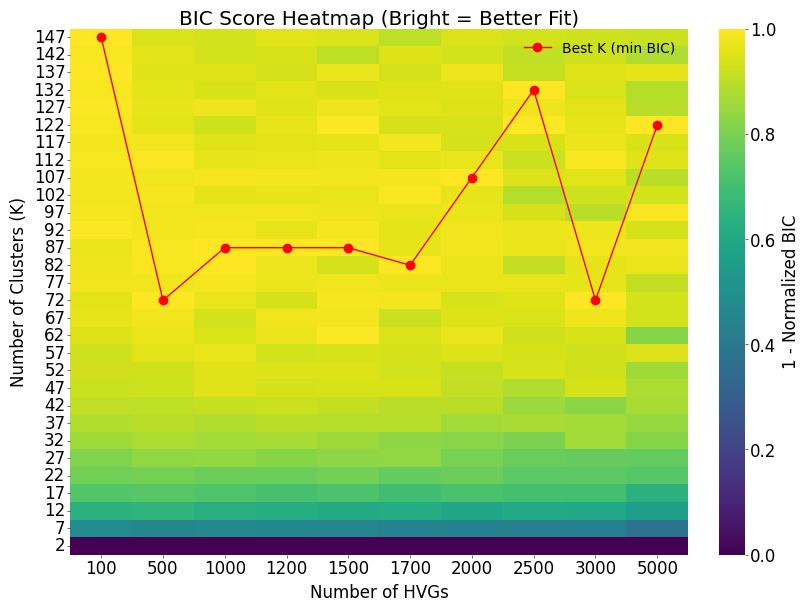

In [212]:
# Do a grid search for number of genes and number of clusters for BIC computation

gs = [100, 500, 1000, 1200, 1500, 1700, 2000, 2500, 3000, 5000]
hvg_idcs = [(g, select_hvg(exonCounts, n_top=g)) for g in gs]
ks = range(2, 150, 5)

all_combinations = list(itertools.product(hvg_idcs, ks))

results = {}
for (n_genes, hvg_idx), n_clusters in tqdm(
    all_combinations,
    desc="Running NBMM grid search for different gene counts and cluster numbers",
):
    nbmm = NBMixtureModelJAX(X_norm, K=n_clusters, S=hvg_idx, r=2.0, tol=1e-5)
    nbmm.fit()
    bic_score = nbmm._bic()
    results[(n_genes, n_clusters)] = bic_score

# Reformat results into matrix
gene_list = sorted(set([k[0] for k in results.keys()]))
cluster_list = sorted(set([k[1] for k in results.keys()]))

# Initialize matrix: shape (n_clusters, n_genes)
bic_matrix = np.full((len(cluster_list), len(gene_list)), np.nan)

for i, k in enumerate(cluster_list):
    for j, g in enumerate(gene_list):
        bic_matrix[i, j] = results[(g, k)]

# Normalize each column and invert (1 - normalized BIC)
bic_matrix_norm = np.zeros_like(bic_matrix)

for j in range(len(gene_list)):
    col = bic_matrix[:, j]
    norm_col = (col - np.min(col)) / (
        np.max(col) - np.min(col) + 1e-8
    )  # Avoid div by 0
    bic_matrix_norm[:, j] = 1 - norm_col  # Invert: higher is better

# Compute argmin (best cluster number) per column
best_k_idx = np.argmin(bic_matrix, axis=0)
best_k_vals = [cluster_list[i] for i in best_k_idx]

# Plot heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    bic_matrix_norm,
    xticklabels=gene_list,
    yticklabels=cluster_list,
    cmap="viridis",
    cbar_kws={"label": "1 - Normalized BIC"},
)

# Overlay line plot of best cluster number
ax.plot(
    np.arange(len(gene_list)) + 0.5,  # Center on bin
    best_k_idx + 0.5,  # Adjust for heatmap indexing
    color="red",
    marker="o",
    label="Best K (min BIC)",
)

# Formatting
ax.invert_yaxis()  # lowest K at bottom
ax.set_xlabel("Number of HVGs")
ax.set_ylabel("Number of Clusters (K)")
ax.set_title("BIC Score Heatmap (Bright = Better Fit)")
ax.legend(loc="upper right")

plt.show()

The plot reveals the following trends:

* For HVG counts in the range **1000 to 1700**, the BIC-optimal cluster number $K^*$ consistently lies around **87**, which is notably close to the number of annotated **RNA types** in the dataset.
* Across the entire range of HVG counts tested, the optimal $K^*$ remains **above 75**, with **no BIC minima near 9**, the number of **RNA families**.


These results likely stem from how NBMM models the data:

* It assumes that gene expression counts follow **overdispersed Negative Binomial distributions**, enabling it to capture heterogeneity in gene expression more sensitively than Gaussian-based models.
* It enforces sparsity by allowing only a **subset of genes** to vary across clusters, which directs the model to focus on **informative transcriptional variation**.

Because of this, NBMM may be **relatively more attuned to RNA types** — which are transcriptionally distinct — than to broader groupings such as RNA families, which may exhibit more **coarse-grained similarity** or **hierarchical structure** not easily captured by flat mixture models.

That said, the absence of BIC minima near 9 does **not necessarily imply an inability** of NBMM to recover RNA families. Rather, it suggests that **under its current assumptions and implementation**, the model finds stronger support for a higher-resolution clustering that may align more closely with RNA types.

Indeed, as we later show, NBMM still achieves **reasonable performance** when fitted with the number of clusters set to 9, indicating that it retains **some flexibility** in capturing broader biological groupings.


In conclusion, NBMM’s modeling assumptions — emphasizing overdispersion, gene-level sparsity, and fine-scale count variation — appear to make it **relatively more effective at recovering RNA types** than RNA families when the number of clusters is determined in an unsupervised fashion via BIC. 

Running NBMM sweep for different gene counts: 100%|██████████| 10/10 [00:34<00:00,  3.47s/it]


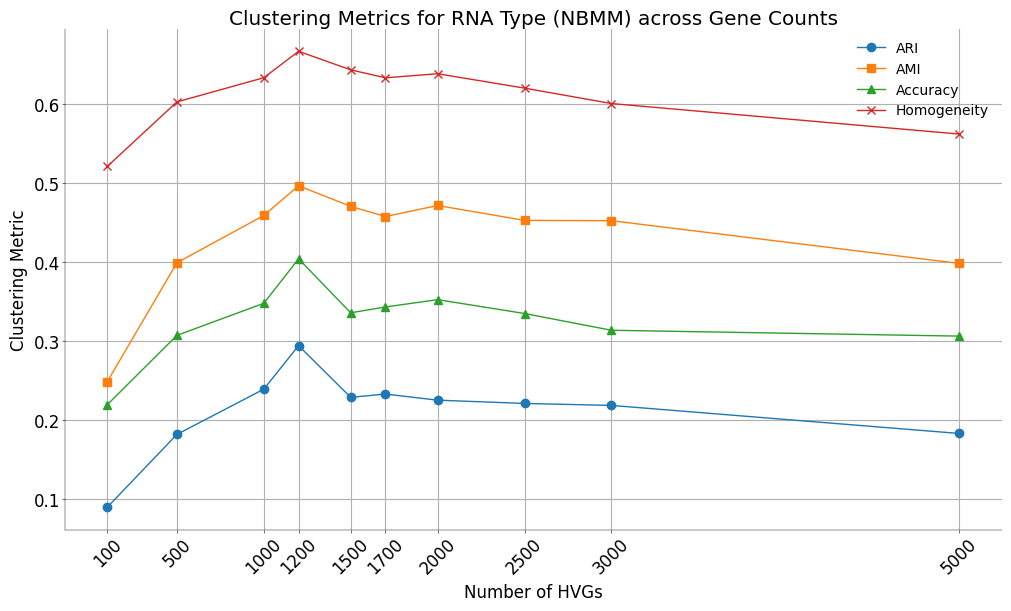

In [ ]:
# Run a sweep across number of genes to be included in subset S
gs = [100, 500, 1000, 1200, 1500, 1700, 2000, 2500, 3000, 5000]
hvg_idcs = [
    (g, select_hvg(exonCounts, n_top=g)) for g in gs
]  # Pick HVGs from raw exon counts

type_metrics = []
ground_truth_type = adata.obs["rna_type"]

for g, hvg_idx in tqdm(
    hvg_idcs, desc="Running NBMM sweep for different gene counts"
):
    nbmm_typ = NBMixtureModelJAX(
        X_norm, K=n_clusters_type, S=hvg_idx, r=2.0, tol=1e-5
    )
    labels, _ = nbmm_typ.fit()
    type_metrics.append(
        compute_clustering_metrics(
            cluster_assignments=labels,
            ground_truth=ground_truth_type,
        )
    )


# Extract metrics from the list of dictionaries
def extract_metric(metric_list, key):
    return [m[key] if m[key] is not None else np.nan for m in metric_list]


typ_ari = extract_metric(type_metrics, "ARI")
typ_ami = extract_metric(type_metrics, "AMI")
typ_acc = extract_metric(type_metrics, "Accuracy")
typ_homog = extract_metric(type_metrics, "Homogeneity")

# Plot the metrics
plt.figure(figsize=(10, 6))
plt.plot(gs, typ_ari, marker="o", label="ARI")
plt.plot(gs, typ_ami, marker="s", label="AMI")
plt.plot(gs, typ_acc, marker="^", label="Accuracy")
plt.plot(gs, typ_homog, marker="x", label="Homogeneity")
plt.xlabel("Number of HVGs")
plt.ylabel("Clustering Metric")
plt.title("Clustering Metrics for RNA Type (NBMM) across Gene Counts")
plt.xticks(gs, rotation=45)
plt.legend()
plt.grid()
plt.show()

While the BIC grid search indicated that NBMM is well-suited to uncovering fine-grained transcriptional structure—most consistently aligned with **RNA type annotations**—the specific choice of the **subset of genes $S$** used in the sparse mixture model remained a critical parameter to determine.

To address this, we systematically varied the number of highly variable genes (HVGs) included in $S$ and evaluated the resulting clustering performance across standard external metrics. This analysis revealed that using **1200 HVGs** yielded the highest clustering accuracy and agreement with RNA type ground truth. We therefore adopt 1200 as the canonical size of $S$ for all subsequent NBMM analyses.

Importantly, the HVGs were selected from the **raw exon count matrix**, not from the Harris-normalized data. This is intentional: **normalizing total counts per cell, as in Harris et al. (2018), suppresses global variability**, potentially obscuring biologically meaningful differences—especially in genes whose expression scales with total RNA content. In contrast, raw counts preserve these differences.

##### 4.4.4 NBMM Clustering Results

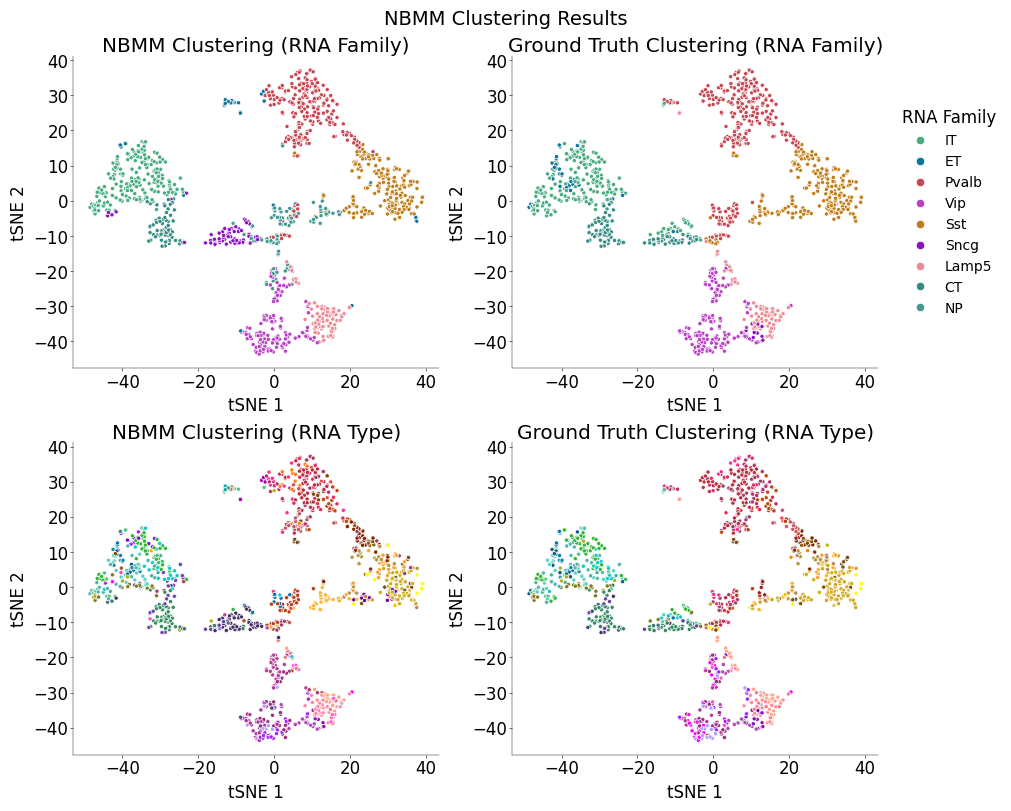

Metrics for NBMM family clustering:
  Homogeneity: 0.777
  ARI: 0.717
  AMI: 0.734
  Accuracy: 0.774
Metrics for NBMM type clustering:
  Homogeneity: 0.667
  ARI: 0.294
  AMI: 0.497
  Accuracy: 0.404


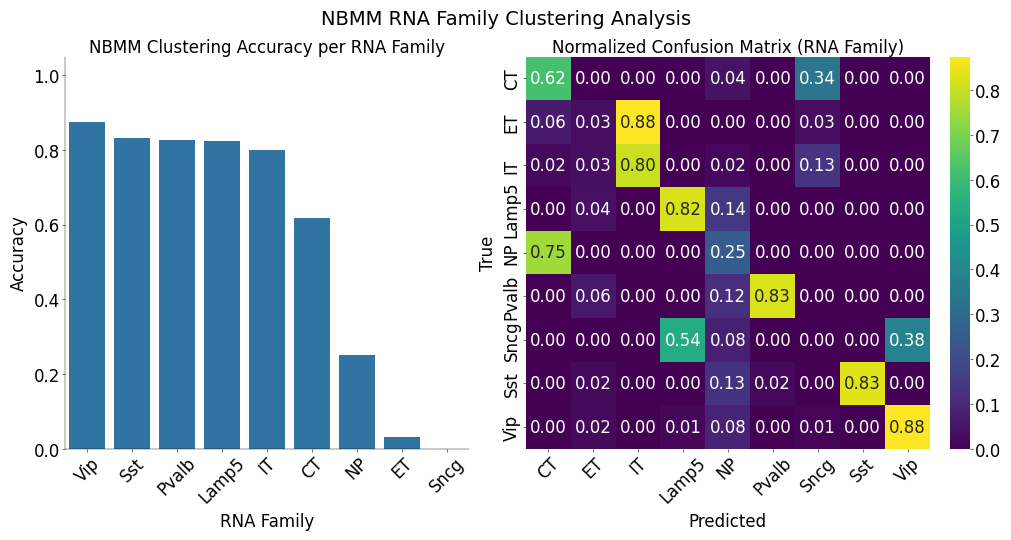

In [ ]:
num_variable_genes = 1200 # Pick the number of HVGs based on the previous analysis
hvg_idx = select_hvg(exonCounts, n_top=num_variable_genes)  # select HVGs

# RNA family clustering
nbmm_family = NBMixtureModelJAX(
    X_norm, K=n_clusters_family, S=hvg_idx, r=2.0, tol=1e-5
)
nbmm_family_labels, nbmm_family_mu = nbmm_family.fit()

# Add NBMM family labels to AnnData object
adata.obs["nbmm_family"] = nbmm_family_labels

# RNA type clustering
nbmm_type = NBMixtureModelJAX(
    X_norm, K=n_clusters_type, S=hvg_idx, r=2.0, tol=1e-5
)
nbmm_type_labels, nbmm_type_mu = nbmm_type.fit()

# Add NBMM type labels to AnnData object
adata.obs["nbmm_type"] = nbmm_type_labels

nbmm_fam_metrics, nbmm_type_metrics = plot_clusters_and_compute_metrics(
    adata.obsm["X_tSNE"],
    adata.obs["nbmm_family"],
    adata.obs["nbmm_type"],
    fam_algo_name="NBMM",
    type_algo_name="NBMM",
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_family_accuracy(
    axes[0],
    adata.obs["rna_family"],
    adata.obs["nbmm_family"],
    mapping=nbmm_fam_metrics["Map"],
    title="NBMM Clustering Accuracy per RNA Family",
)

plot_normalized_confusion(
    axes[1],
    adata.obs["rna_family"],
    adata.obs["nbmm_family"].map(nbmm_fam_metrics["Map"]),
    title="Normalized Confusion Matrix (RNA Family)",
)
plt.suptitle("NBMM RNA Family Clustering Analysis", fontsize=14, y=1.05)
plt.show()

Having identified 1200 as the optimal number of highly variable genes (HVGs) based on clustering metrics for RNA types (see Section 4.4.3), we now apply the **Negative Binomial Mixture Model (NBMM)** with this gene subset to cluster cells into both RNA families and RNA types. The model is initialized using KMeans and fit using an efficient JAX implementation of the Expectation-Maximization (EM) algorithm.

**RNA Family Clustering**

The NBMM clustering results reveal a **heterogeneous pattern of classification accuracy across RNA families**. Several families, including **Vip, Sst, Pvalb, Lamp5**, and **IT**, show **high classification accuracy**. This indicates that NBMM successfully identifies coherent clusters that align closely with these annotated families.

The **normalized confusion matrix** reinforces this interpretation: these families exhibit strong diagonal mass, with minimal off-diagonal confusion. For instance:

* **Vip**, **Sst**, and **Pvalb** show very strong self-prediction scores near or above 0.83.
* **Lamp5** and **IT** similarly show strong diagonal entries (\~0.8), with only minor leakage into adjacent families.

By contrast, a few families, most notably **CT**, **NP**, **ET**, and **Sncg**, display **substantially lower classification accuracy**:

* **CT** achieves a modest diagonal accuracy (\~0.62) and shows confusion primarily with **Scng** (\~0.34), suggesting transcriptional proximity or overlap in the HVG subspace.
* **NP** exhibits a particularly **ambiguous cluster assignment**, with a diagonal score of \~0.25 and substantial confusion with **CT** (\~0.75). This suggests that NBMM finds it difficult to distinguish these two families under the current modeling and HVG selection.
* **ET** and **Sncg** exhibit very low classification accuracy, with **Sncg** showing no diagonal signal, indicating strong misclassification.

These results highlight the strengths and limitations of NBMM in recovering family-level structure. While the model excels in identifying certain transcriptionally well-separated families, it **struggles with families that either have low expression counts, substantial overlap with others, or potentially more internal heterogeneity**. Importantly, this may not be a failure of the NBMM model per se but a consequence of the **inherent transcriptional ambiguity between certain families**, especially when reduced to a fixed HVG subset.

**RNA Type Clustering**

When applied to RNA types, NBMM demonstrates a substantially improved separation of fine-grained subtypes compared to previous clustering approaches. This is consistent with earlier BIC analyses that pointed toward larger optimal cluster counts (around 75–87). NBMM achieves the **best correspondence to RNA types**, as assessed by standard clustering metrics. This supports the hypothesis that NBMM's modeling assumptions — particularly the use of a Negative Binomial likelihood tailored for overdispersed count data — are **well-suited to resolving fine-grained transcriptional subtypes**.

Taken together, these results demonstrate that NBMM is an effective clustering model for scRNA-seq data when the goal is to uncover fine-grained cellular diversity. Its performance on RNA family clustering is competitive, though not always superior, likely due to its sensitivity to subtle within-family variation that may be irrelevant to coarser family-level distinctions. This aligns with our earlier finding that NBMM prefers higher cluster numbers — matching the granularity of RNA types — and may reflect an inductive bias toward resolving **more detailed** cellular heterogeneity.

##### 4.4.5 Hierachical NBMM Clustering

While NBMM clustering with a large number of clusters successfully uncovered transcriptionally coherent RNA **types**, directly applying the same model with a small number of clusters (e.g., $K = 9$) did not yield the best recovery of RNA **families**, as hoped for. This suggested that RNA families might be better conceptualized as *coarser groupings* over a finer-grained type-level structure.

To test this hypothesis, we adopted a **hierarchical clustering strategy**, inspired by the approach proposed by Harris et al. (2018). The core idea is to first fit NBMM at high resolution (e.g., with $K = 75$) to recover fine RNA types, and then to group these inferred clusters into **meta-clusters** that correspond more closely to RNA families.

In [ ]:
def nb_kl_div(mu1, mu2, r=2.0, eps=1e-8):
    """
    Compute KL divergence D_KL(NB(mu1, r) || NB(mu2, r)) assuming fixed r and elementwise means.
    Parameters
    ----------
    mu1, mu2 : np.ndarray of shape (G,)
        Mean parameters of the two NB distributions.
    r : float
        Fixed dispersion.
    Returns
    -------
    float
        KL divergence.
    """
    mu1 = np.clip(mu1, eps, None)
    mu2 = np.clip(mu2, eps, None)
    r = np.clip(r, eps, None)

    term1 = r * np.log((r + mu2) / (r + mu1))
    term2 = mu1 * np.log((mu1 * (r + mu2)) / (mu2 * (r + mu1)))
    return np.sum(term1 + term2)


def compute_cluster_distance_matrix(mu, cluster_sizes, r=2.0):
    """
    Compute a symmetric distance matrix between cluster means
    using symmetric KL divergence, weighted by cluster sizes.
    Parameters
    ----------
    mu : np.ndarray of shape (K, G)
        Cluster mean expression vectors.
    cluster_sizes : np.ndarray of shape (K,)
        Number of cells in each cluster.
    r : float
        NB dispersion parameter.
    Returns
    -------
    np.ndarray of shape (K, K)
        Symmetric pairwise distance matrix.
    """
    K = mu.shape[0]
    D = np.zeros((K, K))

    for i in range(K):
        for j in range(i + 1, K):
            kl_ij = nb_kl_div(mu[i], mu[j], r)
            kl_ji = nb_kl_div(mu[j], mu[i], r)
            sym_kl = cluster_sizes[i] * kl_ij + cluster_sizes[j] * kl_ji
            D[i, j] = sym_kl
            D[j, i] = sym_kl
    return D


def run_hierarchical_clustering(mu, labels, r=2.0, n_meta=9):
    """
    Apply Ward hierarchical clustering to NBMM cluster means using KL divergence.
    Parameters
    ----------
    mu : np.ndarray of shape (K, G)
        Cluster mean expression vectors.
    labels : np.ndarray of shape (N,)
        Cluster assignments for all cells (used to compute cluster sizes).
    r : float
        NB dispersion.
    n_meta : int
        Number of meta-clusters to extract.

    Returns
    -------
    meta_cluster_labels : np.ndarray of shape (K,)
        Meta-cluster assignment for each of the K NBMM clusters.
    Z : linkage matrix (for further hierarchical analysis).
    """
    cluster_sizes = np.bincount(labels, minlength=mu.shape[0])
    dist_matrix = compute_cluster_distance_matrix(mu, cluster_sizes, r)
    condensed = squareform(dist_matrix)

    # Ward linkage on the KL-based distance
    Z = linkage(condensed, method="ward")

    # Cut dendrogram into n_meta clusters
    meta_cluster_labels = (
        fcluster(Z, t=n_meta, criterion="maxclust") - 1
    )  # zero-based

    return meta_cluster_labels, Z

**Method Overview:**

Each NBMM-inferred type cluster is associated with a mean gene expression vector $\mu_k \in \mathbb{R}^G$. To compare these clusters, we define a pairwise dissimilarity measure based on the **symmetric Kullback-Leibler (KL) divergence** between negative binomial (NB) distributions:

$$
D_{ij} = n_i \cdot D_{\text{KL}}(NB(\mu_i, r) \Vert NB(\mu_j, r)) + n_j \cdot D_{\text{KL}}(NB(\mu_j, r) \Vert NB(\mu_i, r)),
$$

where $n_i$ is the number of cells in cluster $i$, and the KL divergence is computed assuming a fixed dispersion $r = 2.0$. This weighting ensures that **larger clusters exert greater influence** on the overall hierarchical structure.

The resulting symmetric distance matrix is then used as input to **Ward’s method**, an agglomerative hierarchical clustering algorithm that merges clusters so as to minimize the total within-cluster variance. Cutting the resulting dendrogram at a target number of clusters (in our case, 9) yields a set of **meta-clusters**.

This procedure enables an indirect mapping from **type-level clusters to family-level groupings**, potentially recovering biologically meaningful structure by leveraging **both fine-grained transcriptional distinctions and coarse-level aggregation**.

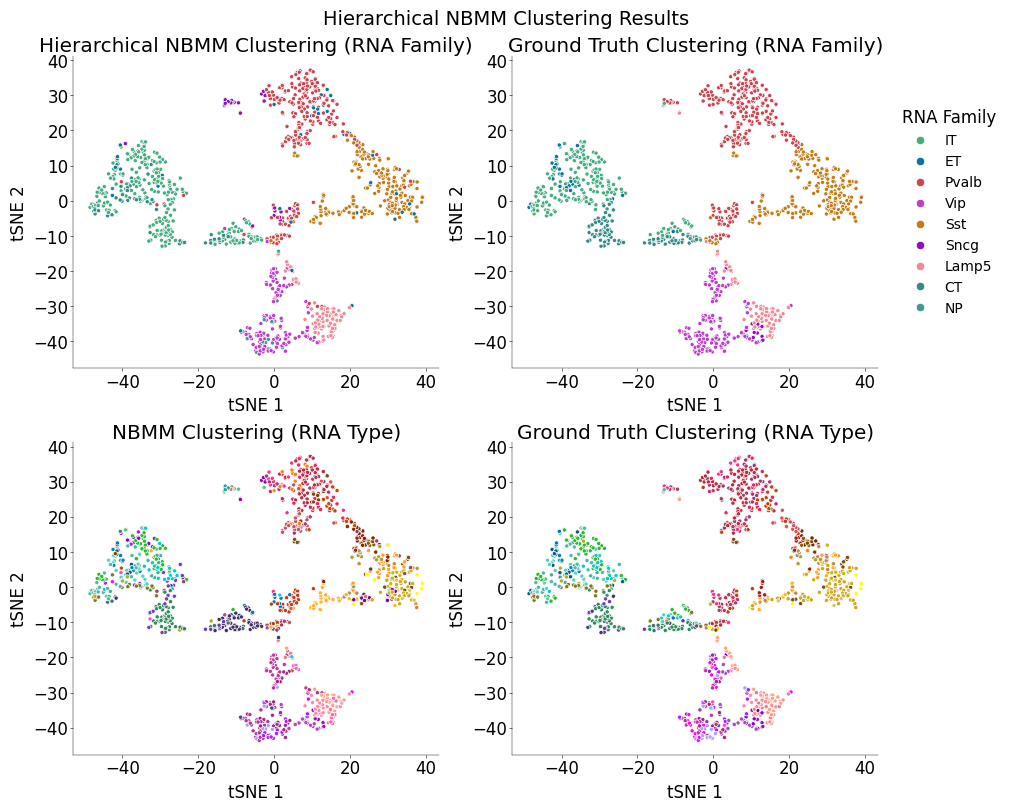

Metrics for Hierarchical NBMM family clustering:
  Homogeneity: 0.707
  ARI: 0.667
  AMI: 0.695
  Accuracy: 0.759
Metrics for NBMM type clustering:
  Homogeneity: 0.667
  ARI: 0.294
  AMI: 0.497
  Accuracy: 0.404


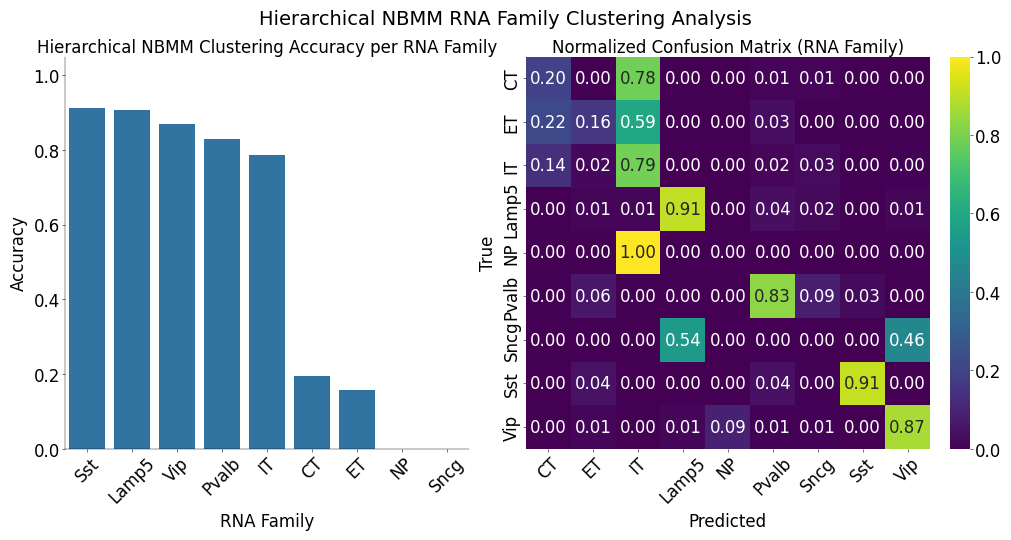

In [201]:
# Use the NBMM type cluster output for hierarchical clustering

nbmm_type_labels = np.array(nbmm_type_labels, dtype=int)
nbmm_type_mu = np.array(nbmm_type_mu, dtype=float)

meta_family_labels, Z_family = run_hierarchical_clustering(
    mu=nbmm_type_mu,
    labels=nbmm_type_labels,
    r=2.0,
    n_meta=n_clusters_family,
)
cell_meta_family_labels = np.array(
    [meta_family_labels[label] for label in nbmm_type_labels], dtype=int
)

meta_fam_metrics, meta_type_metrics = plot_clusters_and_compute_metrics(
    adata.obsm["X_tSNE"],
    pd.Series(cell_meta_family_labels),
    pd.Series(nbmm_type_labels),
    fam_algo_name="Hierarchical NBMM",
    type_algo_name="NBMM",
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_family_accuracy(
    axes[0],
    adata.obs["rna_family"],
    pd.Series(cell_meta_family_labels),
    mapping=meta_fam_metrics["Map"],
    title="Hierarchical NBMM Clustering Accuracy per RNA Family",
)

plot_normalized_confusion(
    axes[1],
    adata.obs["rna_family"],
    pd.Series(cell_meta_family_labels).map(meta_fam_metrics["Map"]),
    title="Normalized Confusion Matrix (RNA Family)",
)
plt.suptitle(
    "Hierarchical NBMM RNA Family Clustering Analysis", fontsize=14, y=1.05
)
plt.show()

The resulting **family-level meta-clustering** performs respectably, but does not surpass the quality of directly applying NBMM with 9 components for family detection. This suggests that while RNA types contain rich transcriptional information, hierarchical aggregation based solely on KL divergence over mean profiles may lose some of the discriminative nuances needed to accurately resolve certain families.

The **per-family classification accuracy** and normalized confusion matrix reveal a non-uniform pattern across RNA families. Several families, such as **Sst**, **Lamp5**, and **Vip**, exhibit high classification accuracy, with most of their cells mapped correctly to a single meta-cluster. This suggests that the associated NBMM types for these families are internally consistent and form distinct transcriptional neighborhoods in the KL space, enabling successful hierarchical aggregation.

On the other hand, families such as **CT**, **ET**, and **NP** are fragmented across multiple meta-clusters or are misclassified. For instance, CT shows significant confusion with IT, while ET is split between multiple predicted classes. This fragmentation indicates that the underlying NBMM type clusters associated with these families are either not as well separated or do not form tight enough groupings to be successfully merged into a coherent meta-cluster using KL divergence alone.

In summary, while hierarchical NBMM clustering offers a promising mechanism to recover RNA family structure from finer NBMM-derived types, its performance remains slightly below direct family-level NBMM clustering.

#### 4.5 Clusterings Comparison

/Users/abbas/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


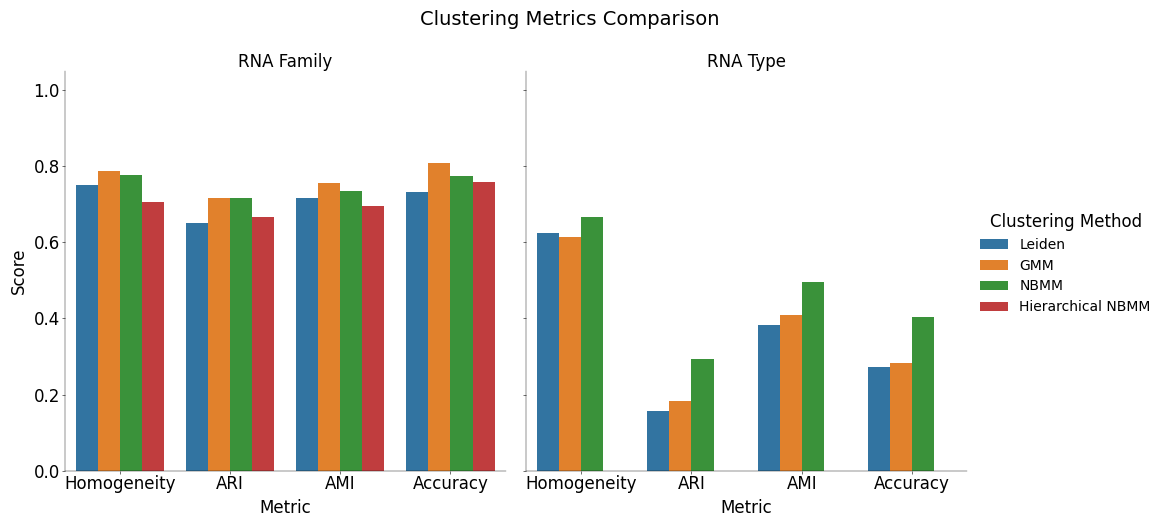

In [204]:
all_fam_metrics = {
    "Leiden": leiden_fam_metrics,
    "GMM": gmm_fam_metrics,
    "NBMM": nbmm_fam_metrics,
    "Hierarchical NBMM": meta_fam_metrics,
}

all_type_metrics = {
    "Leiden": leiden_type_metrrics,
    "GMM": gmm_type_metrics,
    "NBMM": nbmm_type_metrics,
}

data = {
    "Method": [],
    "LabelType": [],
    "Homogeneity": [],
    "ARI": [],
    "AMI": [],
    "Accuracy": [],
}

for i, algo in enumerate([all_fam_metrics, all_type_metrics]):
    for method, metrics in algo.items():
        data["Method"].append(method)
        data["LabelType"].append(["Family", "Type"][i])
        data["Homogeneity"].append(metrics["Homogeneity"])
        data["ARI"].append(metrics["ARI"])
        data["AMI"].append(metrics["AMI"])
        data["Accuracy"].append(metrics["Accuracy"])

# Convert to DataFrame
df = pd.DataFrame(data)

# Melt for seaborn
df_melted = df.melt(
    id_vars=["Method", "LabelType"], var_name="Metric", value_name="Score"
)
# Create FacetGrid for Family and Type
g = sns.catplot(
    data=df_melted,
    x="Metric",
    y="Score",
    hue="Method",
    col="LabelType",
    kind="bar",
    height=5,
    aspect=1,
    errorbar=None,
)

g.set_titles("RNA {col_name}")
g.set_axis_labels("Metric", "Score")
g.set(ylim=(0, 1.05))
g._legend.set_title("Clustering Method")
plt.suptitle("Clustering Metrics Comparison", fontsize=14, y=1.05)
plt.show()

To consolidate our analysis, we compare all four clustering algorithms—Leiden, GMM, NBMM, and Hierarchical NBMM—on both RNA family and RNA type classification tasks using four evaluation metrics: Homogeneity, Adjusted Rand Index (ARI), Adjusted Mutual Information (AMI), and Accuracy. The results are visualized in the bar plot above.

For **RNA family clustering**, **all four methods perform relatively well**, indicating that RNA family structure is consistently recoverable from transcriptomic data. **GMM exhibits slightly superior performance overall**, achieving the highest scores on most metrics and thus being selected for downstream electrophysiological analyses.

That said, **NBMM performs comparably**, tying with GMM on ARI and coming a close second in Homogeneity, AMI, and Accuracy. This suggests that NBMM is nearly as effective as GMM for recovering RNA families, while offering the added advantage of being grounded in a biologically motivated generative model of overdispersed count data.

In contrast, **Leiden and Hierarchical NBMM perform slightly worse**, though they still yield non-trivial recovery of family structure. Interestingly, their relative performance exhibits trade-offs: **Leiden performs slightly better in Homogeneity and AMI**, suggesting more internally consistent clusters, whereas **Hierarchical NBMM achieves higher ARI and Accuracy**, indicating better alignment with the ground-truth family labels in terms of cell-level assignments. These differences are subtle but relevant, reflecting the divergent clustering philosophies of graph-based community detection and top-down agglomerative refinement, respectively.

For **RNA type clustering**, the performance of all algorithms drops considerably, reflecting the increased difficulty of this finer-grained classification task. Here, **NBMM stands out clearly**, outperforming all other methods across all evaluation metrics. This reinforces NBMM’s suitability for capturing nuanced transcriptional variability at the type level, likely due to its ability to model gene-level overdispersion and cell-specific count statistics.

Given these results, **we adopt the GMM clustering outputs for RNA family** in subsequent electrophysiological analyses, as they yield the most robust and coherent clusters at the family level. While NBMM offers a more biologically principled model, particularly for modeling gene count data, its practical advantage is more evident at the resolution of RNA types. 

In [ ]:
# Final family labels from GMM

adata.obs["final_family_labels"] = adata.obs["gmm_family"].map(
    gmm_fam_metrics["Map"]
)
adata.obs["final_family_labels"]

0          IT
1          IT
2          IT
3          ET
4          IT
        ...  
1079       IT
1080       IT
1081    Lamp5
1082       CT
1083       NP
Name: final_family_labels, Length: 1084, dtype: object

---
# 5- Correlation between electrophysiological features and genes/PCs

Finally, connect RNA counts and functional data: Most likely, there will be interesting relationships between the transcriptomic and electrophyiological features in this data. Find these correlations and a way of visualizing them. In studying correlations using the PCA-reduced version of the transcriptomics data, it could be interesting to study PC loadings to see which genes are dominating which PCs. For other advanced analyses, you can get inspitation from Kobak et al., 2021 (https://doi.org/10.1111/rssc.12494).

In [60]:
# 0. choose the best ranked preprocessed RNA sequence dataset

with open(variables_path / "unique_ds_data.pkl", "rb") as f:
    unique_ds_data = pickle.load(f)

chosen_dataset = (
    "CPMedian",
    "log1p",
    1000,
    10,
)
X_tfm = unique_ds_data[chosen_dataset]["X_tfm"]
P_hd = unique_ds_data[chosen_dataset]["P_hd"]

C:\Users\kai.rothe\AppData\Local\Temp\ipykernel_1712\2909568705.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
C:\Users\kai.rothe\AppData\Local\Temp\ipykernel_1712\2909568705.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


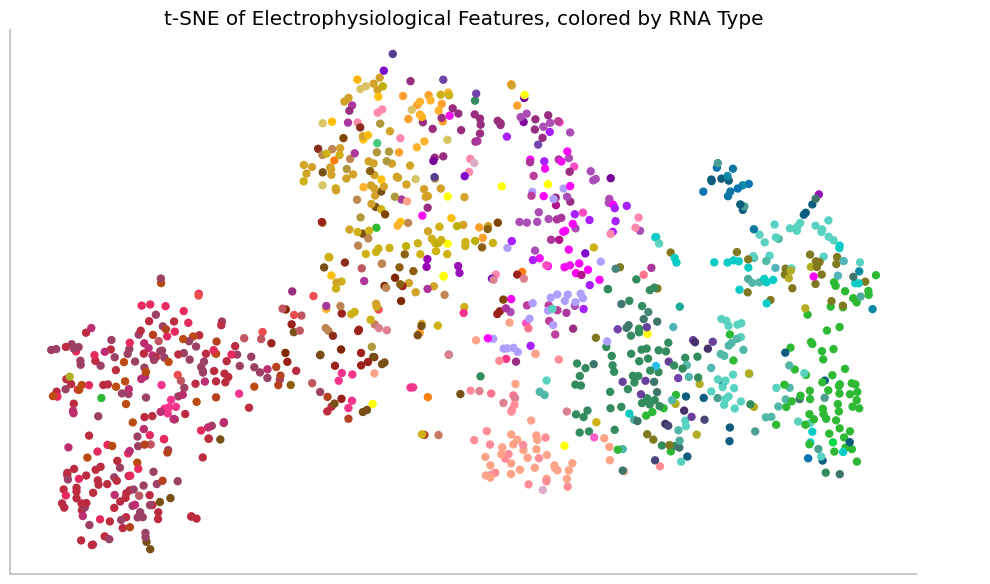

In [61]:
# 1. use t-SNE in ephys space and colorplot families (or t-types with similar colors for same families)

# Perform t-SNE on the electrophysiological data
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
ephys_tsne = tsne.fit_transform(ephysData_filtered)

# Plot t-SNE results
plt.figure(figsize=(10, 6))
plt.scatter(
    ephys_tsne[:, 0],
    ephys_tsne[:, 1],
    c=meta_qc["RNA type color"],  # TODO: use our clusters as well
    alpha=1,
    s=100,
)
plt.title("t-SNE of Electrophysiological Features, colored by RNA Type")
plt.xticks([])
plt.yticks([])
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# TODO: add colorbar for RNA families

TODO: explain..

Observation: as in Scala et al., 2021, we observe that the major transcriptomic families have distinct electrophysiological properties. Verifies our family and hints to interesting relationships between genes, neuron types and electrophysiology properties we tried to understand in the following

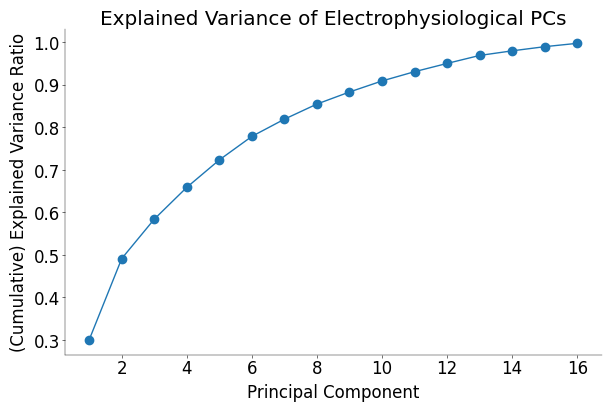

In [62]:
# 2. correlate family labels and ephys features:
# do biplot of pca ephys features and color plot your t-types / families found in 4.
# -> find ephys features that are distinct between t-types / families

# PCA of ephys data
pca = PCA(n_components=16)
P_ephys = pca.fit_transform(
    ephysData_filtered
)  # shape: (n_cells, n_components)

# Plot explained variance per component
plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o",
)
plt.xlabel("Principal Component")
plt.ylabel("(Cumulative) Explained Variance Ratio")
plt.title("Explained Variance of Electrophysiological PCs")
plt.show()

TODO: explain plot, and how representational first PCs for ephys data are

In [63]:
def adjustlabels(fig, labels, max_iter=1000, eps=0.01, delta=0.05):
    """Adjust label positions to avoid overlaps in matplotlib figures, as used in 'Sparse Reduced-Rank Regression for Exploratory Visualisation of Paired Multivariate Data', Kobak et al. 2021.
    Args:
        fig: matplotlib figure containing the labels to adjust.
        labels: list of matplotlib text objects to adjust.
        max_iter: maximum number of iterations to run the adjustment.
        eps: step size for adjusting label positions.
        delta: minimum distance between labels to consider them as non-overlapping.
    """
    N = len(labels)
    widths = np.zeros(N)
    heights = np.zeros(N)
    centers = np.zeros((N, 2))
    for i, l in enumerate(labels):
        bb = l.get_window_extent(renderer=fig.canvas.get_renderer())
        bb = bb.transformed(plt.gca().transData.inverted())
        widths[i] = bb.width
        heights[i] = bb.height
        centers[i] = (bb.min + bb.max) / 2

    for i in range(max_iter):
        stop = True
        for a in range(N):
            for b in range(N):
                if (
                    (a != b)
                    and (
                        np.abs(centers[a, 0] - centers[b, 0])
                        < (widths[a] + widths[b]) / 2 + delta
                    )
                    and (
                        np.abs(centers[a, 1] - centers[b, 1])
                        < (heights[a] + heights[b]) / 2 + delta
                    )
                ):

                    d = centers[a] - centers[b]
                    centers[a] += d * eps
                    centers[b] -= d * eps
                    labels[a].set_position(centers[a])
                    labels[b].set_position(centers[b])
                    stop = False
        if stop:
            break

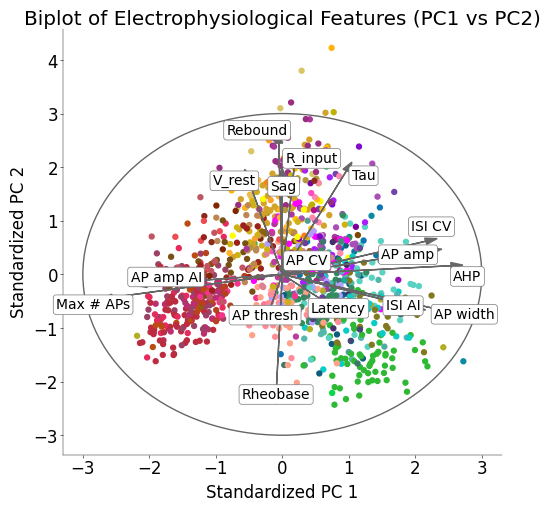

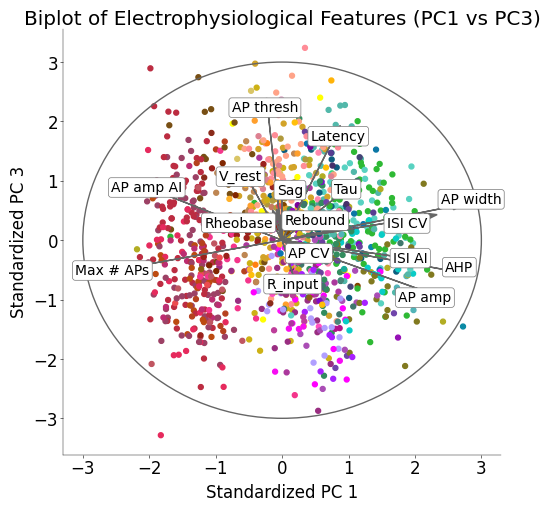

In [64]:
def plot_pca_biplot(
    data,
    projected_data,
    feature_names,
    color,
    title="PCA Biplot",
    pcx=0,
    pcy=1,
    scale=3,
    feature_fontsize=10,
    arrow_color=[0.4, 0.4, 0.4],
    feature_indices=None,
    outlier_scale=100,
    max_features=None,
):
    """
    Plot a PCA biplot for any feature set.

    Args:
        data: original data (n_samples, n_features)
        projected_data: PCA scores (n_samples, n_components)
        feature_names: list of feature names
        meta: DataFrame with metadata (for coloring)
        color_col: column in meta for point colors (optional)
        pcx, pcy: which PCs to plot (0-based)
        scale: scaling factor for arrows
        feature_fontsize: font size for feature labels
        arrow_color: color for arrows
        feature_indices: indices of features to include in the biplot (optional)
        outlier_scale: how many standard deviations to consider as outliers, not shown
        max_features: maximum number of features to show (by loading magnitude)
    """
    # Standardize the chosen PCs
    projected_data_stand = np.stack(
        [projected_data[:, pcx], projected_data[:, pcy]], axis=1
    )
    projected_data_stand = (
        projected_data_stand - np.mean(projected_data_stand)
    ) / np.std(projected_data_stand, axis=0)

    # choose data features
    selected_feature_indices = (
        feature_indices
        if feature_indices is not None
        else np.arange(data.shape[1] - 1)
    )
    data = data[:, selected_feature_indices]
    selected_feature_names = np.array(feature_names)[selected_feature_indices]

    # Compute loadings = correlations between features and PCs
    loadings = np.corrcoef(
        np.concatenate((projected_data_stand, data), axis=1),
        rowvar=False,
    )[2:, :2]

    # select only features with maximal loadings if max_features is set
    if max_features is not None:
        loading_indices = np.argsort(np.linalg.norm(loadings, axis=1))[::-1][
            :max_features
        ]
        loadings = loadings[loading_indices[:max_features]]
        selected_feature_indices = selected_feature_indices[
            loading_indices[:max_features]
        ]
        selected_feature_names = selected_feature_names[
            loading_indices[:max_features]
        ]

    # Outlier mask
    no_outlier_mask = (
        np.linalg.norm(projected_data_stand, axis=1) <= outlier_scale * scale
    )
    selected_projected_data_stand = projected_data_stand[no_outlier_mask]
    selected_colors = color.values[no_outlier_mask]

    not_selected_projected_data_stand = projected_data_stand[~no_outlier_mask]
    not_selected_projected_data_stand_clipped = np.clip(
        not_selected_projected_data_stand,
        -scale * outlier_scale,
        scale * outlier_scale,
    )
    not_selected_colors = color.values[~no_outlier_mask]

    # Biplot
    fig = plt.figure(figsize=(5, 5), constrained_layout=True)
    plt.scatter(
        selected_projected_data_stand[:, 0],
        selected_projected_data_stand[:, 1],
        c=selected_colors,
        s=50,
    )
    plt.scatter(
        not_selected_projected_data_stand_clipped[:, 0],
        not_selected_projected_data_stand_clipped[:, 1],
        c=not_selected_colors,
        s=50,
        alpha=0.5,
        marker="x",
    )
    plt.xlabel(f"Standardized PC {pcx+1}")
    plt.ylabel(f"Standardized PC {pcy+1}")
    plt.title(title)

    # Plot arrows for each feature
    labels = []
    for i in range(loadings.shape[0]):
        plt.arrow(
            0,
            0,
            loadings[i, 0] * scale,
            loadings[i, 1] * scale,
            color=arrow_color,
            zorder=1,
            head_width=0.12,
            head_length=0.18,
            length_includes_head=False,
        )
        t = plt.text(
            loadings[i, 0] * scale,
            loadings[i, 1] * scale,
            selected_feature_names[i],
            color="k",
            ha="center",
            va="center",
            fontsize=feature_fontsize,
            bbox=dict(
                facecolor="w",
                edgecolor="#777777",
                boxstyle="round",
                linewidth=0.5,
                pad=0.2,
            ),
        )
        labels.append(t)

    adjustlabels(fig, labels, delta=0.25 / 3 * scale)

    # Draw unit circle
    circ = plt.Circle(
        (0, 0),
        radius=scale,
        color=arrow_color,
        fill=False,
        linewidth=1,
    )
    plt.gca().add_patch(circ)
    # plt.xticks([])
    # plt.yticks([])
    plt.show()

    return selected_feature_indices, selected_feature_names


# Call the function with your data and parameters
plot_pca_biplot(
    ephysData_filtered,
    P_ephys,
    ephysNames_filtered,
    title="Biplot of Electrophysiological Features (PC1 vs PC2)",
    color=meta_qc["RNA type color"],
    pcx=0,
    pcy=1,
    scale=3,
)

plot_pca_biplot(
    ephysData_filtered,
    P_ephys,
    ephysNames_filtered,
    color=meta_qc["RNA type color"],
    title="Biplot of Electrophysiological Features (PC1 vs PC3)",
    pcx=0,
    pcy=2,
    scale=3,
)

plt.show()

TODO: 
- explain each part of the figure and how to interpret it.
- explain the electrophysiological properties of each neuron class 
- and how this fits our observations.

In [ ]:
from scipy.stats import pearsonr, PermutationMethod


def test_significant_correlations(
    X,
    Y,
    n_resamples=5000,
    random_seed=42,
    to_test_mask=None,
    plot=True,
    print_out=False,
    text="",
):
    """
    Test significance of the maximum absolute correlations between two sets of variables.

    Parameters
    ----------
    X : np.ndarray
        First variable set (samples x features).
    Y : np.ndarray
        Second variable set (samples x features).
    n_resamples : int
        Number of permutation resamples for significance testing.
    random_seed : int
        Seed for reproducibility.
    to_test_mask : np.ndarray, optional
        Mask to specify which pairs of features to test. If None, all pairs are tested.
    plot: bool
    print_out: bool
    text: str

    Returns
    -------
    results : list of dict
        Each dict contains: idx, r, p_value.
    """

    p_values = np.zeros((X.shape[1], Y.shape[1]))
    rng = np.random.default_rng(random_seed)
    for i in range(X.shape[1]):
        for j in range(Y.shape[1]):
            if to_test_mask is not None and not to_test_mask[i, j]:
                continue

            method = PermutationMethod(
                n_resamples=n_resamples, random_state=rng
            )
            res = pearsonr(X[:, i], Y[:, j], method=method, axis=0)
            p_values[i, j] = res.pvalue

            if print_out:
                print(
                    f"Feature {i+1}/{X.shape[1]}, PC {j+1}/{Y.shape[1]}: "
                    f"r={res.correlation:.3f}, p={res.pvalue:.3e}"
                )

    if plot:
        plt.figure(figsize=(4, 3))
        plt.hist(p_values.flatten(), bins=10, range=(0, 0.1))
        plt.axvline(
            0.05, color="red", linestyle="--", linewidth=2, label="p = 0.05"
        )
        plt.xlabel("Permutation p-value")
        plt.ylabel("Count")
        plt.title(r"Distribution of p-values P(data | $H_0$: $r = 0$)" + text)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return p_values

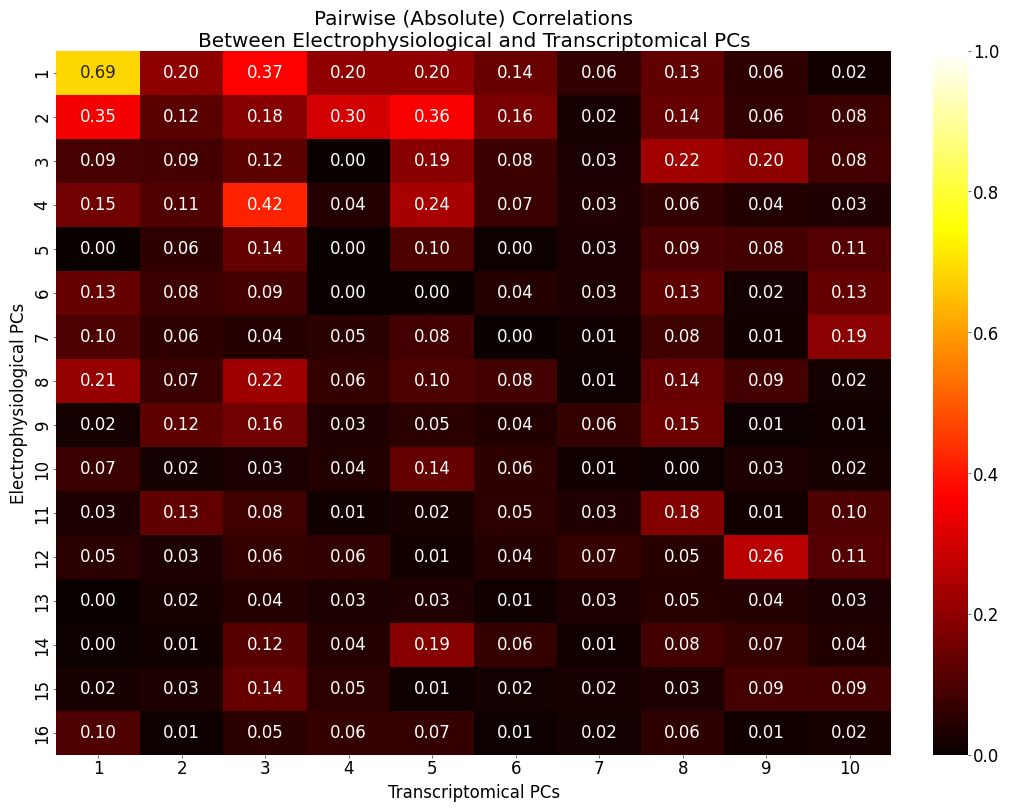

C:\Users\kai.rothe\AppData\Local\Temp\ipykernel_1712\1713274778.py:72: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


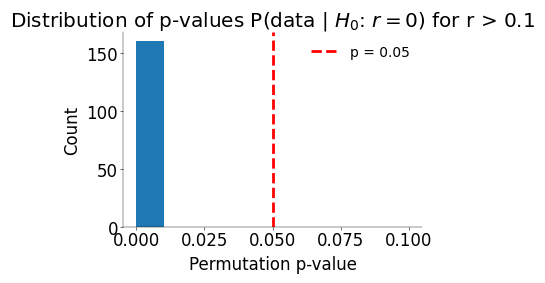

In [112]:
def plot_absolute_correlation_matrix(
    X,
    Y,
    title="Pairwise (Absolute) Correlations Between Electrophysiological and Transcriptomical PCs",
    xlabel="Transcriptomical PCs",
    ylabel="Electrophysiological PCs",
):
    # Compute pairwise correlations between electrophysiological features and gene PCs
    n_x = X.shape[1]
    n_y = Y.shape[1]
    correlation_matrix = np.corrcoef(X, Y, rowvar=False)[:n_x, n_x : n_x + n_y]

    # Create a heatmap to visualize the correlations
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        np.abs(correlation_matrix),
        annot=True,
        fmt=".2f",
        xticklabels=list(range(1, n_y + 1)),
        yticklabels=list(range(1, n_x + 1)),
        cmap="hot",
        vmin=0,
        vmax=1,
    )
    plt.title(
        "Pairwise (Absolute) Correlations\nBetween Electrophysiological and Transcriptomical PCs"
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

    return correlation_matrix


# Plot absolute correlation matrix
PC_correlation_matrix = plot_absolute_correlation_matrix(P_ephys, P_hd)

# Test significance of the maximum absolute correlations
to_test_mask = np.abs(PC_correlation_matrix) > 0.1
p_values = test_significant_correlations(
    P_ephys, P_hd, to_test_mask=to_test_mask, text=" for r > 0.1"
)

TODO: explain observations: 
- first pcs highly correlated, but others less. we want to understand why
- Some Transcriptomical PCs not correlating with Ephys PCs at all, because 
    - a) not rotated to maximize cross-correlation (as e.g. in CCA) and 
    - b) some genes likely don't encode ephys properties but other biological functions, and 
    - c) some artifacts in data, e.g. due to different RNA counts (see Kobak paper)

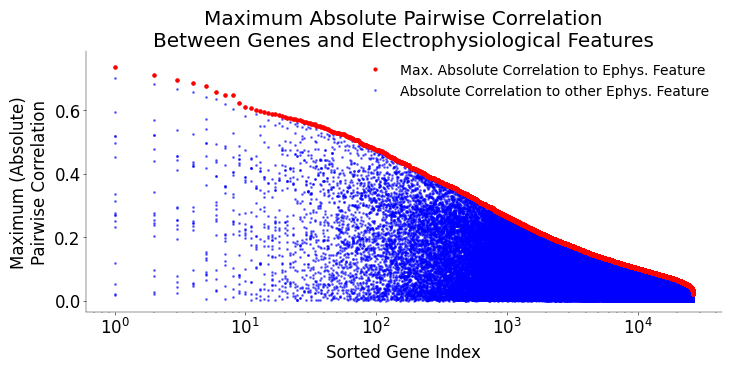

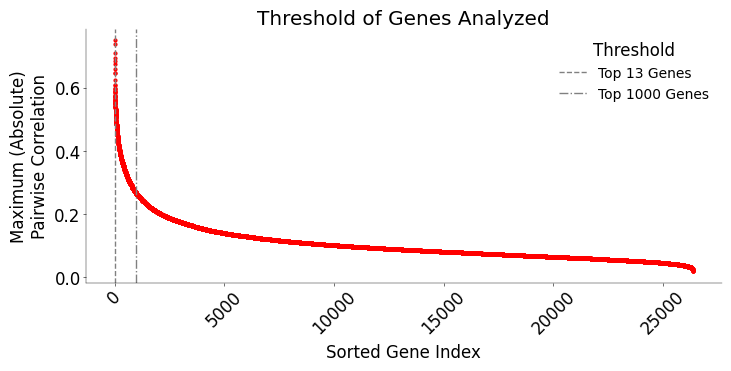

In [109]:
# 4. pairwise correlation of ephys features and genes

# Compute pairwise correlations between electrophysiological features and gene PCs
n_feat = ephysData_filtered.shape[1]
n_pc = X_tfm.shape[1]
correlation_matrix = np.corrcoef(ephysData_filtered, X_tfm, rowvar=False)[
    :n_feat, n_feat : n_feat + n_pc
]

if np.any(np.isnan(correlation_matrix)):
    correlation_matrix = np.nan_to_num(
        correlation_matrix, nan=0.0
    )  # replace NaNs with 0, probably due to constant features

# sort by maximum absolute correlation
absolute_correlations_per_gene = np.abs(correlation_matrix)
max_absolute_correlations_per_gene = np.max(
    absolute_correlations_per_gene, axis=0
)
sorted_indices = np.argsort(max_absolute_correlations_per_gene)[::-1]
absolute_correlations_per_gene_sorted = absolute_correlations_per_gene[
    :, sorted_indices
]

# Plot the maximum absolute correlations
plt.plot(
    max_absolute_correlations_per_gene[sorted_indices],
    marker="o",
    color="red",
    linestyle="None",
    markersize=2,
    label="Max. Absolute Correlation to Ephys. Feature",
)
plt.plot(
    absolute_correlations_per_gene_sorted.T[:, 0],
    marker="o",
    linestyle="None",
    markersize=1,
    color="blue",
    alpha=0.5,
    label="Absolute Correlation to other Ephys. Feature",
)
plt.plot(
    absolute_correlations_per_gene_sorted.T,
    marker="o",
    linestyle="None",
    markersize=1,
    color="blue",
    alpha=0.5,
    # label="Absolute Correlation to other Ephys. Feature",
)

plt.plot(
    max_absolute_correlations_per_gene[sorted_indices],
    marker="o",
    color="red",
    linestyle="None",
    markersize=2,
)
plt.xlabel("Sorted Gene Index")
plt.ylabel("Maximum (Absolute)\nPairwise Correlation")
plt.title(
    "Maximum Absolute Pairwise Correlation\nBetween Genes and Electrophysiological Features"
)
plt.legend()
plt.xscale("log")
plt.show()

# Validate gene thresholds in analysis
plt.plot(
    max_absolute_correlations_per_gene[sorted_indices],
    marker="o",
    color="red",
    linestyle="None",
    markersize=2,
)
plt.axvline(x=13, color="gray", linestyle="--", label="Top 13 Genes")
plt.axvline(x=1000, color="gray", linestyle="-.", label="Top 1000 Genes")
plt.legend(title="Threshold")
plt.xticks(rotation=45)
plt.xlabel("Sorted Gene Index")
plt.ylabel("Maximum (Absolute)\nPairwise Correlation")
plt.title("Threshold of Genes Analyzed")
plt.show()

TODO: explain plot: 
- very few genes showing high maximum correlation to some ephys feature - around 15, with a knee at latest 1000
- highest correlations significant

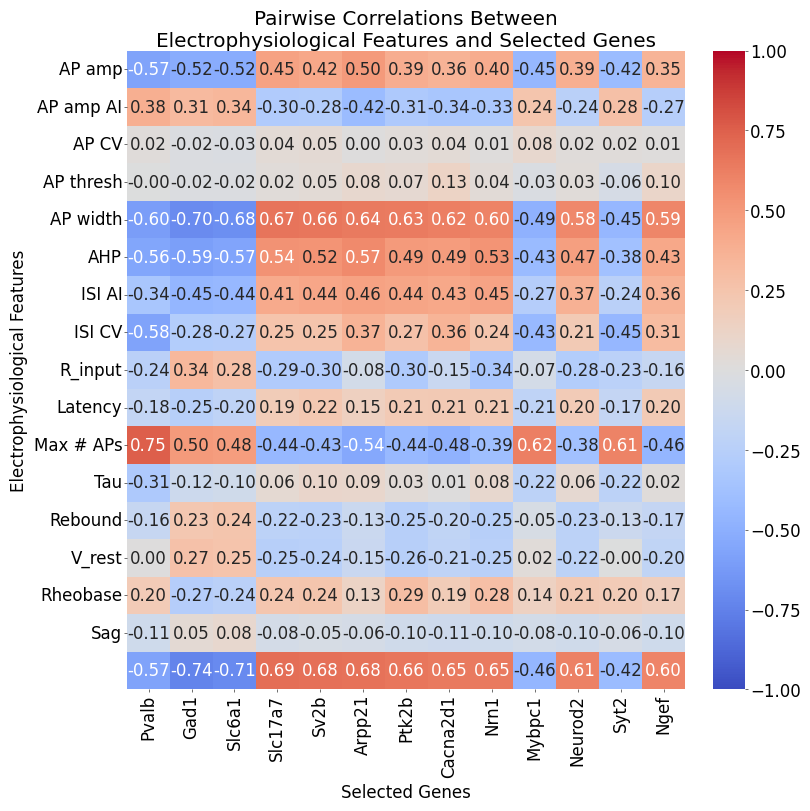

C:\Users\kai.rothe\AppData\Local\Temp\ipykernel_1712\1592413439.py:71: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


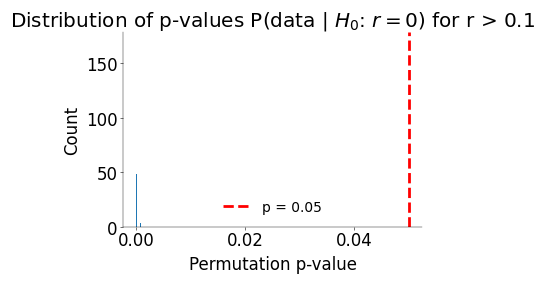

In [110]:
def plot_top_gene_correlations(
    correlation_matrix,
    sorted_indices,
    max_genes,
    ephysNames_filtered=ephysNames_filtered,
    genes=genes,
):
    """
    Plot a heatmap of the pairwise correlations between electrophysiological features
    and the top most correlated genes.

    Args:
        correlation_matrix: np.ndarray, shape (n_ephys_features, n_genes)
        ephysNames_filtered: list of str, names of ephys features
        genes: np.ndarray or list, gene names
        sorted_indices: np.ndarray, indices of genes sorted by max correlation
        max_genes: int, number of top genes to plot
    """
    filtered_correlation_matrix = correlation_matrix[:, sorted_indices][
        :, :max_genes
    ]
    selected_genes = genes[sorted_indices][:max_genes]

    plt.figure(figsize=(8, 8), constrained_layout=True)
    sns.heatmap(
        filtered_correlation_matrix,
        annot=True,
        fmt=".2f",
        yticklabels=ephysNames_filtered,
        xticklabels=selected_genes,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
    )
    plt.title(
        "Pairwise Correlations Between\nElectrophysiological Features and Selected Genes"
    )
    plt.xlabel("Selected Genes")
    plt.ylabel("Electrophysiological Features")
    plt.show()

    return selected_genes, filtered_correlation_matrix


max_genes_to_test = 13
selected_genes, filtered_correlation_matrix = plot_top_gene_correlations(
    correlation_matrix, sorted_indices, max_genes=max_genes_to_test
)

# Test significance of the maximum absolute correlations
to_test_mask = np.abs(filtered_correlation_matrix) > 0.1
selected_X_tfm = X_tfm[:, sorted_indices][:, :max_genes_to_test]
p_values = test_significant_correlations(
    ephysData_filtered,
    selected_X_tfm,
    to_test_mask=to_test_mask,
    text=" for r > 0.1",
)

TODO: 
- explain plots
- explain highest correlation genes function and how much researched, with references
- explain neural function and connect to correlated ephys properties

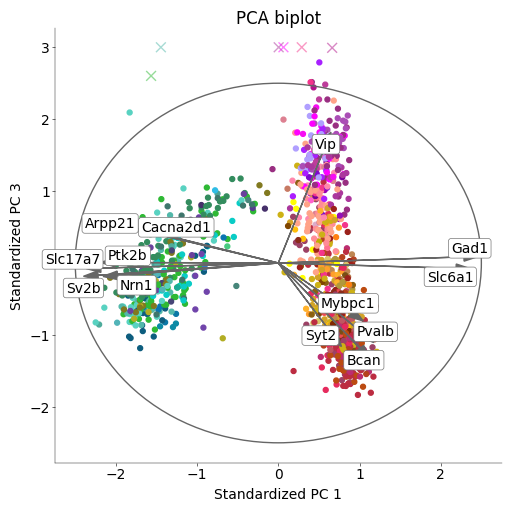

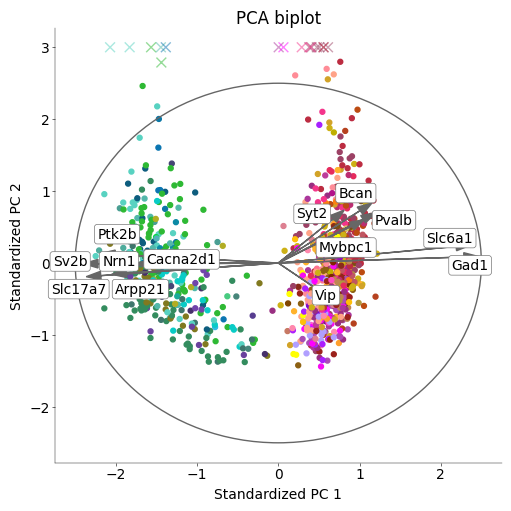

(array([20981,  6991, 22691, 22448, 23495, 20909,  2473,  3346, 18419,
        23560, 19065, 25287,  2949]),
 array(['Pvalb', 'Gad1', 'Slc6a1', 'Slc17a7', 'Sv2b', 'Ptk2b', 'Arpp21',
        'Cacna2d1', 'Mybpc1', 'Syt2', 'Nrn1', 'Vip', 'Bcan'], dtype=object))

In [ ]:
plot_pca_biplot(
    X_tfm,
    P_hd,
    genes,
    color=meta_qc["RNA type color"],
    pcx=0,
    pcy=2,
    scale=2.5,
    feature_indices=sorted_indices[:max_genes_to_test],
    outlier_scale=1.2,
    title="PC1 and PC3 Loadings of Selected Genes",
)

plot_pca_biplot(
    X_tfm,
    P_hd,
    genes,
    color=meta_qc["RNA type color"],
    pcx=0,
    pcy=1,
    scale=2.5,
    feature_indices=sorted_indices[:max_genes_to_test],
    outlier_scale=1.2,
     title="PC1 and PC2 Loadings of Selected Genes",
)

plt.show()

TODO: 
- explain plot
- describe observations
-> confirm your connection between genes and ephys properties by finding how much genes expressed in each cell family
-> connect with biplot of ephys data
-> connect with PC correlations

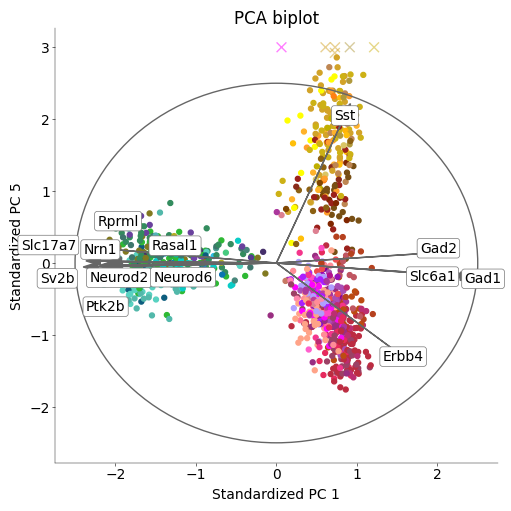

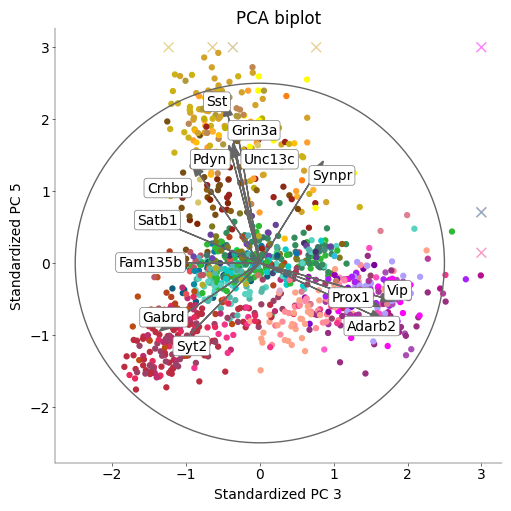

(array([23278, 15448, 25287,  1746, 20708, 25102, 19856, 21911,  4696,
         6374,  6981, 23545, 23560]),
 array(['Sst', 'Grin3a', 'Vip', 'Adarb2', 'Prox1', 'Unc13c', 'Pdyn',
        'Satb1', 'Crhbp', 'Fam135b', 'Gabrd', 'Synpr', 'Syt2'],
       dtype=object))

In [ ]:
# 6. what about other highly correlated PCs?

gene_indices_pc5, _ = plot_pca_biplot(
    X_tfm,
    P_hd,
    genes,
    color=meta_qc["RNA type color"],
    pcx=0,
    pcy=4,
    scale=2.5,
    feature_indices=sorted_indices[:1000],
    outlier_scale=1.2,
    max_features=13,
    title="PC1 and PC5 Loadings of Selected Genes",
)

plot_pca_biplot(
    X_tfm,
    P_hd,
    genes,
    color=meta_qc["RNA type color"],
    pcx=2,
    pcy=4,
    scale=2.5,
    feature_indices=sorted_indices[:1000],
    outlier_scale=1.2,
    max_features=13,
    title="PC3 and PC5 Loadings of Selected Genes",
)

plt.show()

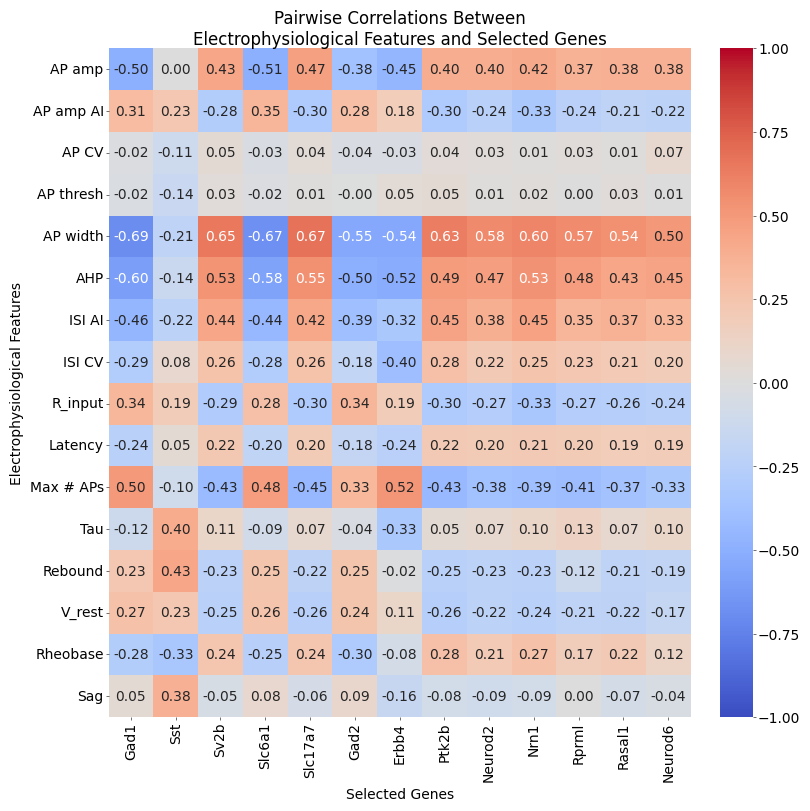

array(['Gad1', 'Sst', 'Sv2b', 'Slc6a1', 'Slc17a7', 'Gad2', 'Erbb4',
       'Ptk2b', 'Neurod2', 'Nrn1', 'Rprml', 'Rasal1', 'Neurod6'],
      dtype=object)

In [ ]:
plot_top_gene_correlations(correlation_matrix, gene_indices_pc5, max_genes=13)
plt.show()

TODO: 
- explain gene selection here
- briefly explain that also other highly correlated PCs can be explained by family specific genes, e.g. here such as Sst

Limitations:  even if out of scope of this project, further analysis could 
- identify ion channels and find correlations here, see paper; or focus on other genes of interest e.g. which underlie some diseases
- focused on pairwise correlations, explaining correlations of dominant PCs of each dataset -> multivariate correlations: correlate PCs, try CCA and sparse RRR -> might identify some always selected or highly correlating genes, which could be analyized further
-  only correlative and linear statistical relationships -> causal, mutual information, etc.